# 05 Future 5-Minute Return Scoring and Prediction

## 1. Research Objective

This notebook builds a reproducible scoring engine for predicting the next 5-minute midpoint return from Level2 microstructure features.

Primary label:

```text
future_return_5m = mid_price(t + 5min) / mid_price(t) - 1
```

Direction label:

```text
future_direction_5m = -1 / 0 / 1
```

The core causal rule is strict: every feature at minute `t` must use only information observable at or before `t`. The future midpoint at `t+5min` is used only for label construction and out-of-sample evaluation.

The notebook separates four tasks:

1. **Signal discovery** — identify informative single factors.
2. **Signal combination** — combine non-redundant features into a model score.
3. **Robustness** — evaluate the score across dates, price groups, and order-book states.
4. **Calibration** — convert the score into an expected 5-minute return and predicted price.

Price level remains a parallel research dimension because low-priced stocks have larger tick sizes in percentage terms and more discrete short-horizon returns.


## 1.1 Notebook Structure

```text
Configuration and reproducible sample
    ↓
Minute-level market state and exact-horizon label
    ↓
Label diagnostics and price groups
    ↓
Feature engineering by economic mechanism
    ↓
Single-factor IC and grouped-return evaluation
    ↓
Correlation and redundancy screening
    ↓
Linear scoring benchmark
    ↓
Nonlinear scoring models: Random Forest and XGBoost
    ↓
OOS stability, interpretation, and robustness
    ↓
Score-to-return calibration with uncertainty
    ↓
Numerical predicted return and predicted price
```

The final objective is not merely to report correlation. It is to translate the observed feature state into an economically interpretable expected 5-minute return.


In [115]:
from dataclasses import dataclass
from typing import Dict, Iterable, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

EPS = 1e-9


def safe_divide(a, b):
    """Element-wise division that returns NaN when the denominator is too small."""
    return np.where(np.abs(b) > EPS, a / b, np.nan)


def require_columns(df: pd.DataFrame, columns: Sequence[str], name: str = "DataFrame") -> None:
    """Fail early with an informative error when required columns are missing."""
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")


def cross_sectional_winsorize(
    df: pd.DataFrame,
    columns: Sequence[str],
    group_cols: Sequence[str] = ("date", "minute"),
    lower_q: float = 0.01,
    upper_q: float = 0.99,
) -> pd.DataFrame:
    """Winsorize features within each date-minute cross-section without using future data."""
    result = df.copy()

    for col in columns:
        if col not in result.columns:
            continue

        lower = result.groupby(list(group_cols))[col].transform(
            lambda x: x.quantile(lower_q)
        )
        upper = result.groupby(list(group_cols))[col].transform(
            lambda x: x.quantile(upper_q)
        )
        result[col] = result[col].clip(lower=lower, upper=upper)

    return result


In [116]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.ddb_client import connect_ddb

session = connect_ddb()


In [117]:
@dataclass(frozen=True)
class Config:
    # Data source
    DB_PATH: str = "dfs://quota"

    # QUICK_MODE preserves the original short sample for fast iteration.
    # Set QUICK_MODE=False for the extended research run.
    QUICK_MODE: bool = False

    QUICK_START_DATE: str = "2026.03.11"
    RESEARCH_START_DATE: str = "2026.01.01"
    END_DATE: str = "2026.04.10"

    START_TIME: str = "09:30:00"
    END_TIME: str = "10:00:00"

    QUICK_N_STOCKS: int = 30
    RESEARCH_N_STOCKS: int = 40

    RANDOM_STATE: int = 42
    HORIZON_MINUTES: int = 5
    ROLLING_WINDOW: int = 20

    RF_PARAMS: Optional[Dict] = None
    XGB_PARAMS: Optional[Dict] = None

    @property
    def START_DATE(self) -> str:
        return self.QUICK_START_DATE if self.QUICK_MODE else self.RESEARCH_START_DATE

    @property
    def N_STOCKS(self) -> int:
        return self.QUICK_N_STOCKS if self.QUICK_MODE else self.RESEARCH_N_STOCKS


CFG = Config(
    RF_PARAMS={
        "n_estimators": 200,
        "max_depth": 5,
        "min_samples_leaf": 50,
        "max_features": "sqrt",
        "random_state": 42,
        "n_jobs": -1,
    },
    XGB_PARAMS={
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "objective": "reg:squarederror",
        "random_state": 42,
        "n_jobs": -1,
    },
)

DB_PATH = CFG.DB_PATH
START_DATE = CFG.START_DATE
END_DATE = CFG.END_DATE
START_TIME = CFG.START_TIME
END_TIME = CFG.END_TIME
RANDOM_STATE = CFG.RANDOM_STATE
N_STOCKS = CFG.N_STOCKS
ROLLING_WINDOW = CFG.ROLLING_WINDOW
HORIZON_MINUTES = CFG.HORIZON_MINUTES

print("Mode:", "QUICK" if CFG.QUICK_MODE else "EXTENDED RESEARCH")
print("Database:", DB_PATH)
print("Sample period:", START_DATE, "to", END_DATE)
print("Intraday window:", START_TIME, "to", END_TIME)
print("N_STOCKS:", N_STOCKS)
print("Rolling window:", ROLLING_WINDOW, "trading days")
print("Prediction horizon:", HORIZON_MINUTES, "minutes")


Mode: EXTENDED RESEARCH
Database: dfs://quota
Sample period: 2026.01.01 to 2026.04.10
Intraday window: 09:30:00 to 10:00:00
N_STOCKS: 40
Rolling window: 20 trading days
Prediction horizon: 5 minutes


## 2. Unified Research Sample

File 4 and File 5 use the same deterministic 30-stock universe. The filter combines `qtick.dtype == 1`, exchange-aware A-share code ranges, at least 20 covered trading dates, and explicit exclusion checks for common index, ETF, fund and convertible-bond ranges. The final pool is stratified across SZ Main, SH Main, ChiNext and STAR so that the later board, price-group, liquidity and cross-sectional prediction analyses refer to the same underlying stocks.


In [118]:
# ============================================================
# Unified A-share Stock Universe (shared by File 4 and File 5)
# ============================================================
# qtick has no separate security master. We therefore use two independent
# filters: (1) dtype == 1 from qtick, and (2) an exchange-aware A-share code
# whitelist. A prefix alone is unsafe: e.g. 000170.SH is an index, not SZ Main.

POOL_START_DATE = START_DATE
POOL_END_DATE = END_DATE
POOL_RANDOM_STATE = RANDOM_STATE
MIN_QTICK_DATES = 55

BOARD_SAMPLE_PLAN = {
    "SZ Main": 12,
    "SH Main": 12,
    "ChiNext": 8,
    "STAR": 8,
}

universe_script = f"""
qtick = loadTable("{DB_PATH}", "qtick")

select distinct code, date, dtype, name
from qtick
where date >= {POOL_START_DATE}
  and date <= {POOL_END_DATE}
  and dtype = 1
  and (
        code like "000%.SZ"
        or code like "001%.SZ"
        or code like "002%.SZ"
        or code like "003%.SZ"
        or code like "300%.SZ"
        or code like "301%.SZ"
        or code like "600%.SH"
        or code like "601%.SH"
        or code like "603%.SH"
        or code like "605%.SH"
        or code like "688%.SH"
      )
order by code, date
"""

universe_daily = session.run(universe_script)
universe_daily["code"] = (
    universe_daily["code"].astype(str).str.strip().str.upper()
)


def classify_a_share_board(code):
    """Exchange-aware whitelist for ordinary Shanghai/Shenzhen A shares."""
    code = str(code).strip().upper()
    if code.endswith(".SZ") and code[:3] in {"000", "001", "002", "003"}:
        return "SZ Main"
    if code.endswith(".SZ") and code[:3] in {"300", "301"}:
        return "ChiNext"
    if code.endswith(".SH") and code[:3] in {"600", "601", "603", "605"}:
        return "SH Main"
    if code.endswith(".SH") and code[:3] == "688":
        return "STAR"
    return None


universe_daily["board"] = universe_daily["code"].map(classify_a_share_board)

stock_coverage = (
    universe_daily
    .groupby(["code", "board"], as_index=False)
    .agg(
        name=("name", "first"),
        dtype=("dtype", "first"),
        n_qtick_dates=("date", "nunique"),
    )
)

eligible_pool = stock_coverage[
    stock_coverage["board"].notna()
    & stock_coverage["dtype"].eq(1)
    & stock_coverage["n_qtick_dates"].ge(MIN_QTICK_DATES)
].copy()

selected_parts = []
for board, n_target in BOARD_SAMPLE_PLAN.items():
    board_pool = eligible_pool[eligible_pool["board"].eq(board)].sort_values("code")
    if len(board_pool) < n_target:
        raise ValueError(
            f"Insufficient eligible {board} stocks: need {n_target}, found {len(board_pool)}"
        )
    selected_parts.append(
        board_pool.sample(n=n_target, random_state=POOL_RANDOM_STATE)
    )

stock_pool = (
    pd.concat(selected_parts, ignore_index=True)
    .sort_values(["board", "code"])
    .reset_index(drop=True)
)
sample_codes = stock_pool["code"].tolist()

# Fail loudly if a non-equity code can enter the modelling sample.
assert stock_pool["code"].is_unique
assert stock_pool["dtype"].eq(1).all()
assert stock_pool["board"].notna().all()
assert stock_pool["code"].map(classify_a_share_board).notna().all()
assert not stock_pool["code"].isin(["000001.SH", "399001.SZ", "399006.SZ"]).any()
assert not stock_pool["code"].str.startswith(
    ("159", "510", "511", "512", "513", "515", "516", "518", "588",
     "110", "113", "123", "127", "128")
).any()

codes_ddb = "[" + ",".join(f'"{code}"' for code in sample_codes) + "]"
code_filter = ",".join(f'"{code}"' for code in sample_codes)

print("Eligible ordinary A-share stocks:", len(eligible_pool))
print("Unified selected stocks:", len(sample_codes))
display(stock_pool.groupby("board").size().rename("n_stocks").to_frame())
display(stock_pool[["code", "name", "dtype", "board", "n_qtick_dates"]])



# ============================================================
# Three-table coverage validation for the unified stock pool
# ============================================================
coverage_queries = {
    "qtick": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qtick")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qorder": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qorder")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
    "qknock": f"""
        select distinct code, date
        from loadTable("{DB_PATH}", "qknock")
        where code in {codes_ddb}
          and date >= {POOL_START_DATE}
          and date <= {POOL_END_DATE}
    """,
}

coverage_parts = []
for table_name, query in coverage_queries.items():
    tmp = session.run(query)
    tmp["code"] = tmp["code"].astype(str).str.strip().str.upper()
    summary = tmp.groupby("code")["date"].nunique().rename(f"{table_name}_dates")
    coverage_parts.append(summary)

three_table_coverage = (
    stock_pool.set_index("code")[["name", "board"]]
    .join(coverage_parts, how="left")
    .fillna({"qtick_dates": 0, "qorder_dates": 0, "qknock_dates": 0})
    .reset_index()
)

for col in ["qtick_dates", "qorder_dates", "qknock_dates"]:
    three_table_coverage[col] = three_table_coverage[col].astype(int)

three_table_coverage["three_table_ready"] = (
    three_table_coverage[["qtick_dates", "qorder_dates", "qknock_dates"]]
    .min(axis=1)
    .ge(MIN_QTICK_DATES)
)

display(three_table_coverage)
assert three_table_coverage["three_table_ready"].all(), (
    "Some selected stocks lack sufficient qtick/qorder/qknock coverage. "
    "Inspect three_table_coverage before continuing."
)
print("Unified stock pool passed security-type, code-range and three-table coverage checks.")


Eligible ordinary A-share stocks: 5180
Unified selected stocks: 40


,n_stocks
board,
ChiNext,8
SH Main,12
STAR,8
SZ Main,12


,code,name,dtype,board,n_qtick_dates
0,300183.SZ,东软载波,1,ChiNext,63
1,300490.SZ,华自科技,1,ChiNext,63
2,300595.SZ,欧普康视,1,ChiNext,63
3,301052.SZ,果麦文化,1,ChiNext,63
4,301255.SZ,通力科技,1,ChiNext,63
5,301391.SZ,卡莱特,1,ChiNext,63
6,301552.SZ,科力装备,1,ChiNext,63
7,301622.SZ,英思特,1,ChiNext,63
8,600158.SH,中体产业,1,SH Main,63
9,600182.SH,S佳通,1,SH Main,63


,code,name,board,qtick_dates,qorder_dates,qknock_dates,three_table_ready
0,300183.SZ,东软载波,ChiNext,63,63,63,True
1,300490.SZ,华自科技,ChiNext,63,63,63,True
2,300595.SZ,欧普康视,ChiNext,63,63,63,True
3,301052.SZ,果麦文化,ChiNext,63,63,63,True
4,301255.SZ,通力科技,ChiNext,63,63,63,True
5,301391.SZ,卡莱特,ChiNext,63,63,63,True
6,301552.SZ,科力装备,ChiNext,63,63,63,True
7,301622.SZ,英思特,ChiNext,63,63,63,True
8,600158.SH,中体产业,SH Main,63,63,63,True
9,600182.SH,S佳通,SH Main,63,63,63,True


Unified stock pool passed security-type, code-range and three-table coverage checks.


## 3. Load `qtick` Snapshot Data

The first version builds a 1-minute panel from `qtick` snapshot data. Only necessary fields are queried to reduce DolphinDB transfer size.


In [119]:
# ============================================================
# Batched qtick Query for File 5
# ============================================================

qtick_cols = """
code, date, time,
new_price,
bp0, ap0,
bv0, av0,
bv1, av1,
bv2, av2,
bv3, av3,
bv4, av4,
sum_volume, sum_amount
"""


def chunk_codes(codes, batch_size=10):
    for start in range(0, len(codes), batch_size):
        yield codes[start:start + batch_size]


qtick_parts = []

for batch_no, code_batch in enumerate(
    chunk_codes(sample_codes, batch_size=10),
    start=1
):
    batch_codes_ddb = (
        "["
        + ",".join(
            f'"{code}"'
            for code in code_batch
        )
        + "]"
    )

    qtick_script = f"""
    select {qtick_cols}
    from loadTable("{DB_PATH}", "qtick")
    where code in {batch_codes_ddb}
      and date >= {START_DATE}
      and date <= {END_DATE}
      and time >= {START_TIME}.000
      and time <= {END_TIME}.000
    order by code, date, time
    """

    batch_df = session.run(qtick_script)
    qtick_parts.append(batch_df)

    print(
        f"File 5 qtick batch {batch_no}:",
        len(code_batch),
        "stocks,",
        len(batch_df),
        "rows"
    )

qtick = pd.concat(
    qtick_parts,
    ignore_index=True
)

print("qtick total shape:", qtick.shape)
display(qtick.head())

File 5 qtick batch 1: 10 stocks, 344312 rows
File 5 qtick batch 2: 10 stocks, 368543 rows
File 5 qtick batch 3: 10 stocks, 347605 rows
File 5 qtick batch 4: 10 stocks, 373726 rows
qtick total shape: (1434186, 18)


,code,date,time,new_price,bp0,ap0,bv0,av0,bv1,av1,bv2,av2,bv3,av3,bv4,av4,sum_volume,sum_amount
0,300183.SZ,2026-01-05,1970-01-01 09:30:00,14.96,14.92,14.96,100,3100,2000,10000,100,1000,300,3200,1400,200,104800,1567017.0
1,300183.SZ,2026-01-05,1970-01-01 09:30:03,14.97,14.97,14.99,4900,10000,21400,15000,43000,5100,400,500,2700,2800,155400,2325004.0
2,300183.SZ,2026-01-05,1970-01-01 09:30:06,14.96,14.96,14.99,21700,11800,46900,15000,400,5100,3200,500,2500,2800,164500,2461201.0
3,300183.SZ,2026-01-05,1970-01-01 09:30:09,14.99,14.98,14.99,1100,8000,22100,15000,46900,5100,3500,2200,3000,500,169400,2534630.0
4,300183.SZ,2026-01-05,1970-01-01 09:30:12,14.98,14.96,14.98,22100,1300,46900,8000,3500,15000,3000,5100,1500,2200,170800,2555602.0


## 4. Minute-Level Market State

Each final row represents one stock-minute:

```text
stock × date × minute
```

The row stores the last observable snapshot within that minute.


In [120]:
qtick = qtick.copy()

date_str = pd.to_datetime(qtick["date"]).dt.strftime("%Y-%m-%d")

time_str = qtick["time"].astype(str)
time_str = (
    time_str
    .str.replace("1970-01-01 ", "", regex=False)
    .str.replace("1900-01-01 ", "", regex=False)
)

qtick["datetime"] = pd.to_datetime(
    date_str + " " + time_str,
    format="mixed"
)

qtick["time_clean"] = qtick["datetime"].dt.strftime("%H:%M:%S.%f")
qtick["time_clean"] = qtick["time_clean"].str.replace(".000000", "", regex=False)

qtick["minute"] = qtick["datetime"].dt.floor("min")

display(qtick[["code", "date", "time_clean", "datetime", "minute"]].head())


,code,date,time_clean,datetime,minute
0,300183.SZ,2026-01-05,09:30:00,2026-01-05 09:30:00,2026-01-05 09:30:00
1,300183.SZ,2026-01-05,09:30:03,2026-01-05 09:30:03,2026-01-05 09:30:00
2,300183.SZ,2026-01-05,09:30:06,2026-01-05 09:30:06,2026-01-05 09:30:00
3,300183.SZ,2026-01-05,09:30:09,2026-01-05 09:30:09,2026-01-05 09:30:00
4,300183.SZ,2026-01-05,09:30:12,2026-01-05 09:30:12,2026-01-05 09:30:00


In [121]:
qtick["bp0"] = pd.to_numeric(qtick["bp0"], errors="coerce").replace(0, np.nan)
qtick["ap0"] = pd.to_numeric(qtick["ap0"], errors="coerce").replace(0, np.nan)

qtick["mid_price"] = (qtick["bp0"] + qtick["ap0"]) / 2

display(qtick[["code", "date", "datetime", "bp0", "ap0", "mid_price"]].head())


,code,date,datetime,bp0,ap0,mid_price
0,300183.SZ,2026-01-05,2026-01-05 09:30:00,14.92,14.96,14.940
1,300183.SZ,2026-01-05,2026-01-05 09:30:03,14.97,14.99,14.980
2,300183.SZ,2026-01-05,2026-01-05 09:30:06,14.96,14.99,14.975
3,300183.SZ,2026-01-05,2026-01-05 09:30:09,14.98,14.99,14.985
4,300183.SZ,2026-01-05,2026-01-05 09:30:12,14.96,14.98,14.970


In [122]:
minute_panel = (
    qtick
    .sort_values(["code", "date", "datetime"])
    .groupby(["code", "date", "minute"])
    .agg(
        mid_price=("mid_price", "last"),
        last_price=("new_price", "last"),
        bp0=("bp0", "last"),
        ap0=("ap0", "last"),
        bv0=("bv0", "last"),
        av0=("av0", "last"),
        bv1=("bv1", "last"),
        av1=("av1", "last"),
        bv2=("bv2", "last"),
        av2=("av2", "last"),
        bv3=("bv3", "last"),
        av3=("av3", "last"),
        bv4=("bv4", "last"),
        av4=("av4", "last"),
        sum_volume=("sum_volume", "last"),
        sum_amount=("sum_amount", "last")
    )
    .reset_index()
)

minute_panel = minute_panel.sort_values(["code", "date", "minute"])

print("minute_panel shape:", minute_panel.shape)
display(minute_panel.head())


minute_panel shape: (77134, 19)


,code,date,minute,mid_price,last_price,bp0,ap0,bv0,av0,bv1,av1,bv2,av2,bv3,av3,bv4,av4,sum_volume,sum_amount
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.625,6.63,6.62,6.63,57900,42400,97700,51200,85600,63400,20200,112600,59100,93000,222800,1478169.0
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,6.645,6.64,6.64,6.65,200,73900,100100,73000,60400,111600,98700,98000,88900,74700,394100,2615055.0
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,6.615,6.62,6.61,6.62,107700,6300,95400,28000,20200,47700,58700,134900,13300,82100,571100,3788036.0
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,6.625,6.63,6.62,6.63,73800,40900,114700,83600,95600,134300,21700,81200,68700,114600,614800,4077336.0
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,6.625,6.63,6.62,6.63,153900,19700,128300,86100,97200,134300,21700,81200,70700,115300,652200,4325279.0


## 5. Exact-Horizon Label Construction

The target is the midpoint return from timestamp `t` to the exact timestamp `t + 5 minutes`.

```text
future_return_5m = mid_price(t + 5min) / mid_price(t) - 1
```

A row-based `.shift(-5)` can silently misalign the label when one or more minutes are missing. The corrected implementation creates an explicit target timestamp and performs an exact `code × date × target_minute` match.

Observations without an exact `t+5min` midpoint are retained in the minute panel for diagnostics but excluded from the labeled modeling sample.


In [123]:
# ============================================================
# Exact-Horizon Label Construction
# ============================================================

require_columns(
    minute_panel,
    ["code", "date", "minute", "mid_price"],
    name="minute_panel",
)

minute_panel = (
    minute_panel
    .sort_values(["code", "date", "minute"])
    .copy()
)

# Exact target timestamp rather than row-based shift(-5).
minute_panel["target_minute_5m"] = (
    minute_panel["minute"]
    + pd.Timedelta(minutes=HORIZON_MINUTES)
)

future_price_lookup = (
    minute_panel[
        ["code", "date", "minute", "mid_price"]
    ]
    .rename(
        columns={
            "minute": "target_minute_5m",
            "mid_price": "future_mid_5m",
        }
    )
    .drop_duplicates(
        subset=["code", "date", "target_minute_5m"]
    )
)

minute_panel = minute_panel.merge(
    future_price_lookup,
    on=["code", "date", "target_minute_5m"],
    how="left",
    validate="many_to_one",
)

minute_panel["future_return_5m"] = (
    minute_panel["future_mid_5m"]
    / minute_panel["mid_price"]
    - 1
)

minute_panel["future_direction_5m"] = np.select(
    [
        minute_panel["future_return_5m"] > 0,
        minute_panel["future_return_5m"] < 0,
    ],
    [1, -1],
    default=0,
)

minute_panel["exact_horizon_available"] = (
    minute_panel["future_mid_5m"].notna()
)

label_df = minute_panel.dropna(
    subset=["mid_price", "future_mid_5m", "future_return_5m"]
).copy()

label_quality = pd.DataFrame({
    "Metric": [
        "Minute-panel observations",
        "Exact 5-minute labels",
        "Missing exact-horizon ratio",
        "Unique dates",
        "Unique stocks",
    ],
    "Value": [
        len(minute_panel),
        len(label_df),
        1 - minute_panel["exact_horizon_available"].mean(),
        label_df["date"].nunique(),
        label_df["code"].nunique(),
    ],
})

display(label_quality)

display(
    label_df[
        [
            "code",
            "date",
            "minute",
            "target_minute_5m",
            "mid_price",
            "future_mid_5m",
            "future_return_5m",
            "future_direction_5m",
        ]
    ].head(10)
)


,Metric,Value
0,Minute-panel observations,77134.000000
1,Exact 5-minute labels,64039.000000
2,Missing exact-horizon ratio,0.169316
3,Unique dates,63.000000
4,Unique stocks,40.000000


,code,date,minute,target_minute_5m,mid_price,future_mid_5m,future_return_5m,future_direction_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,2026-01-05 09:35:00,6.625,6.635,0.001509,1
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,2026-01-05 09:36:00,6.645,6.635,-0.001505,-1
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,2026-01-05 09:37:00,6.615,6.625,0.001512,1
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,2026-01-05 09:38:00,6.625,6.625,0.000000,0
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,2026-01-05 09:39:00,6.625,6.625,0.000000,0
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,2026-01-05 09:40:00,6.635,6.625,-0.001507,-1
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,2026-01-05 09:41:00,6.635,6.625,-0.001507,-1
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,2026-01-05 09:42:00,6.625,6.625,0.000000,0
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,2026-01-05 09:43:00,6.625,6.625,0.000000,0
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,2026-01-05 09:44:00,6.625,6.625,0.000000,0


In [124]:
# ============================================================
# Exact 5-Minute Horizon Check
# ============================================================

minute_panel["future_minute_5m"] = (
    minute_panel
    .groupby(["code", "date"])["minute"]
    .shift(-5)
)

minute_panel["actual_horizon_min"] = (
    (minute_panel["future_minute_5m"] - minute_panel["minute"])
    .dt.total_seconds() / 60
)

display(
    minute_panel["actual_horizon_min"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
)


,count
actual_horizon_min,
5.0,64534
NaN,12600


The exact timestamp matching framework successfully prevents horizon misalignment. Observations without an exact five-minute future price are excluded rather than being incorrectly matched to the next available row.

## 6. Label Diagnostics and Price-Group Construction

This section validates the label before feature engineering.

Price group is constructed immediately after label diagnostics and then merged into the master feature table. This makes price group a parallel dimension throughout the rest of the notebook.


### 6.1 Exact Five-Minute Horizon Validation

The prediction target is defined using the midpoint of the best bid and ask:

$$
mid_t = \frac{bid_t + ask_t}{2}
$$

and the future five-minute return is:

$$
future\_return\_{5m,t}
=
\frac{mid_{t+5m}}{mid_t} - 1
$$

Instead of using a row-based `shift(-5)`, the future midpoint is matched using the exact timestamp \(t+5\) minutes within each stock.

The resulting sample contains 14,097 observations with an exact five-minute horizon. Observations without a valid midpoint exactly five minutes ahead are excluded rather than being matched to an incorrect future observation.

This construction preserves the intended economic interpretation of a strict five-minute prediction horizon and reduces temporal alignment errors.

In [125]:
display(label_df["future_return_5m"].describe())

print("Direction balance:")
direction_summary = (
    label_df["future_direction_5m"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)
direction_summary["ratio"] = direction_summary["count"] / direction_summary["count"].sum()
direction_summary.index = direction_summary.index.map({-1: "Negative", 0: "Zero", 1: "Positive"})
display(direction_summary)


count    64039.000000
mean         0.000036
std          0.007053
min         -0.059723
25%         -0.003317
50%          0.000000
75%          0.003044
max          0.086697
Name: future_return_5m, dtype: float64

Direction balance:


,count,ratio
future_direction_5m,,
Negative,30720,0.479708
Zero,4369,0.068224
Positive,28950,0.452068


### 6.2 Future Return Distribution

The future five-minute midpoint return distribution is strongly concentrated around zero with relatively heavy tails.

Across the valid prediction sample:

- 47.83% of observations have negative future returns;
- 42.17% have positive future returns;
- 10.00% have exactly zero future returns.

The label therefore exhibits a mild negative directional imbalance. However, the imbalance is not sufficiently large to explain a model that systematically predicts negative returns.

More importantly, the substantial zero-return mass suggests that the short-horizon return process is partially discrete. This motivates further analysis of whether the zero-return observations are systematically related to stock-level microstructure characteristics.

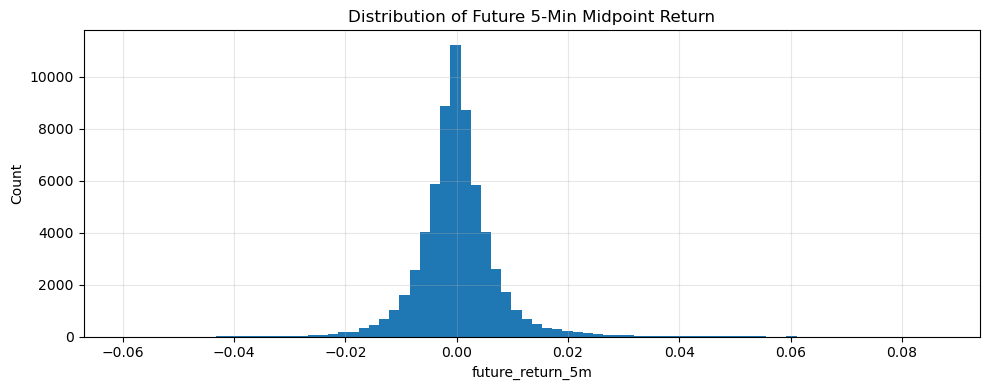

In [126]:
plt.figure(figsize=(10, 4))
plt.hist(label_df["future_return_5m"], bins=80)
plt.title("Distribution of Future 5-Min Midpoint Return")
plt.xlabel("future_return_5m")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.3 Mid-Price versus Last-Trade Return

Mid-price and last-trade based labels produce broadly similar five-minute return distributions.

The midpoint return has a standard deviation of 0.00557, compared with 0.00566 for the last-trade return. The zero-return ratio is also slightly lower for midpoint returns, at 10.00% compared with 10.59%.

The empirical difference is modest. Mid-price return is nevertheless retained as the primary prediction target because it represents the contemporaneous valuation implied by the best bid and ask and is less directly affected by individual trade execution noise.

The midpoint definition is also more consistent with the order-book features used in the subsequent analysis.

In [127]:
zero_return_by_stock = (
    label_df
    .assign(is_zero_return=lambda x: x["future_return_5m"].eq(0))
    .groupby("code")
    .agg(
        n_obs=("future_return_5m", "size"),
        zero_return_ratio=("is_zero_return", "mean"),
        avg_mid_price=("mid_price", "mean")
    )
    .sort_values("zero_return_ratio", ascending=False)
)

display(zero_return_by_stock)


,n_obs,zero_return_ratio,avg_mid_price
code,,,
600488.SH,1454,0.354883,4.348920
600425.SH,1595,0.267085,4.424618
600662.SH,1552,0.240335,5.574836
000816.SZ,1632,0.228554,3.691461
000713.SZ,1628,0.227273,6.837205
002578.SZ,1585,0.145110,4.351675
000782.SZ,1632,0.128676,5.690999
600182.SH,1588,0.107053,14.618208
000863.SZ,1600,0.100625,5.786400


Price level is not merely a descriptive grouping variable. It is a microstructure confounder affecting the discretization of the prediction target itself.

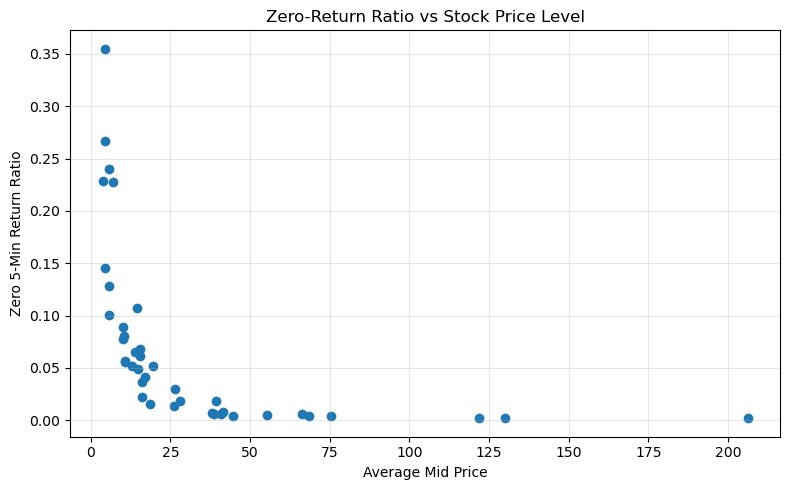

In [128]:
plt.figure(figsize=(8, 5))
plt.scatter(zero_return_by_stock["avg_mid_price"], zero_return_by_stock["zero_return_ratio"])
plt.xlabel("Average Mid Price")
plt.ylabel("Zero 5-Min Return Ratio")
plt.title("Zero-Return Ratio vs Stock Price Level")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [129]:
label_comparison = minute_panel.copy()

label_comparison["future_last_price_5m"] = (
    label_comparison
    .groupby(["code", "date"])["last_price"]
    .shift(-5)
)

label_comparison["future_return_5m_last"] = (
    label_comparison["future_last_price_5m"] / label_comparison["last_price"] - 1
)

label_comparison = label_comparison.dropna(
    subset=["future_return_5m", "future_return_5m_last"]
).copy()

comparison_summary = pd.DataFrame({
    "Mid Price Return": [
        label_comparison["future_return_5m"].std(),
        label_comparison["future_return_5m"].eq(0).mean()
    ],
    "Last Price Return": [
        label_comparison["future_return_5m_last"].std(),
        label_comparison["future_return_5m_last"].eq(0).mean()
    ]
}, index=["Return Std", "Zero Return Ratio"])

display(comparison_summary)


,Mid Price Return,Last Price Return
Return Std,0.007053,0.007174
Zero Return Ratio,0.068224,0.075626


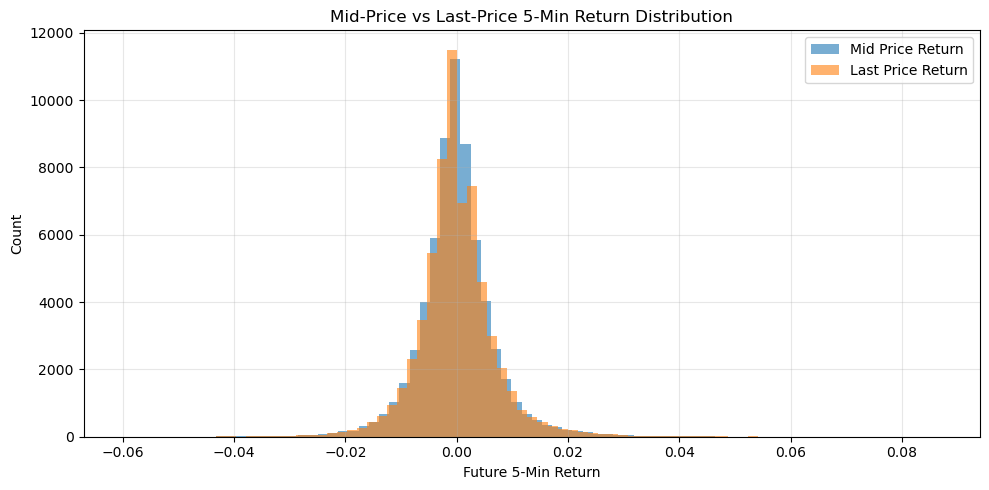

In [130]:
plt.figure(figsize=(10, 5))
plt.hist(label_comparison["future_return_5m"], bins=80, alpha=0.6, label="Mid Price Return")
plt.hist(label_comparison["future_return_5m_last"], bins=80, alpha=0.6, label="Last Price Return")
plt.xlabel("Future 5-Min Return")
plt.ylabel("Count")
plt.title("Mid-Price vs Last-Price 5-Min Return Distribution")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.4 Price-Level Stratified Label Analysis

The zero-return observations are not distributed uniformly across stocks.

Several low-priced stocks exhibit zero-return ratios above 20%, while the ratio falls below 3% for many higher-priced stocks. This pattern suggests that the zero-return mass is systematically related to price level rather than being purely random.

A possible microstructure explanation is the fixed minimum tick-size mechanism. For a low-priced stock, a fixed absolute price increment represents a larger relative price movement. The resulting price grid is therefore coarser in percentage terms, increasing the probability that the midpoint remains unchanged over a short five-minute horizon.

To examine this heterogeneity, stocks are divided into Low Price, Mid Price, and High Price groups.


In [131]:
stock_price_level = (
    label_df
    .groupby("code")
    .agg(
        avg_mid_price=("mid_price", "mean"),
        zero_return_ratio=("future_return_5m", lambda x: (x == 0).mean()),
        return_std=("future_return_5m", "std"),
        n_obs=("future_return_5m", "size")
    )
    .reset_index()
)

stock_price_level["price_group"] = pd.qcut(
    stock_price_level["avg_mid_price"],
    q=3,
    labels=["Low Price", "Mid Price", "High Price"]
)

display(stock_price_level.sort_values("avg_mid_price"))


,code,avg_mid_price,zero_return_ratio,return_std,n_obs,price_group
2,000816.SZ,3.691461,0.228554,0.007393,1632,Low Price
24,600488.SH,4.348920,0.354883,0.006500,1454,Low Price
11,002578.SZ,4.351675,0.145110,0.007805,1585,Low Price
22,600425.SH,4.424618,0.267085,0.004065,1595,Low Price
25,600662.SH,5.574836,0.240335,0.005342,1552,Low Price
1,000782.SZ,5.690999,0.128676,0.005958,1632,Low Price
3,000863.SZ,5.786400,0.100625,0.008684,1600,Low Price
0,000713.SZ,6.837205,0.227273,0.004243,1628,Low Price
28,603466.SH,10.083373,0.077931,0.007997,1527,Low Price
20,600158.SH,10.142673,0.089308,0.007717,1590,Low Price


In [132]:
label_price_df = label_df.merge(
    stock_price_level[["code", "avg_mid_price", "price_group"]],
    on="code",
    how="left"
)

price_group_label_summary = (
    label_price_df
    .groupby("price_group", observed=True)
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_mid_price=("avg_mid_price", "mean"),
        zero_return_ratio=("future_return_5m", lambda x: (x == 0).mean()),
        mean_future_return=("future_return_5m", "mean"),
        std_future_return=("future_return_5m", "std")
    )
)

display(price_group_label_summary)


,n_obs,avg_mid_price,zero_return_ratio,mean_future_return,std_future_return
price_group,,,,,
Low Price,20644,7.140719,0.156559,0.000138,0.006787
Mid Price,20899,17.509599,0.047227,0.000076,0.006327
High Price,22496,70.797794,0.006668,-0.000094,0.007881


Mid-price return produces slightly lower volatility and a slightly lower zero-return ratio than last-trade return. The difference is modest, but mid price is retained because it better represents the contemporaneous order-book valuation and is less directly affected by individual trade execution noise.

The label diagnostics identify price-level heterogeneity as an important microstructure consideration.

A pooled factor evaluation may combine stocks with structurally different short-horizon return distributions. Subsequent analysis therefore reports both pooled predictive relationships and price-group robustness results.

With the prediction target and its cross-sectional heterogeneity established, the next step is to construct candidate features describing the contemporaneous order book, trading activity, signed trading pressure, short-term momentum, and volatility state.

## 7. Master Feature Table and Evaluation Helpers

From this point onward, all feature families are merged into one `master_feature_df`. This avoids fragmented feature tables and ensures that every feature can be evaluated using the same pooled and price-group framework.


### 7.1 Modeling Data Hygiene

Tree models do not require standardization, but extreme feature observations can create unstable split points. The notebook therefore provides an optional cross-sectional winsorization step.

Winsorization is performed within each `date × minute` cross-section, so it does not use future information or mix different market states. Raw features are preserved for economic interpretation; winsorized features can be used as a robustness specification.


In [133]:
# Optional robustness specification; raw features remain the main baseline.
USE_WINSORIZED_FEATURES = False
WINSOR_LOWER_Q = 0.01
WINSOR_UPPER_Q = 0.99

print("Use winsorized model features:", USE_WINSORIZED_FEATURES)


Use winsorized model features: False


In [134]:
master_feature_df = label_price_df.copy()

print("master_feature_df shape:", master_feature_df.shape)
display(master_feature_df[["code", "date", "minute", "price_group", "mid_price", "future_return_5m"]].head())


master_feature_df shape: (64039, 26)


,code,date,minute,price_group,mid_price,future_return_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,Low Price,6.625,0.001509
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,Low Price,6.645,-0.001505
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,Low Price,6.615,0.001512
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,Low Price,6.625,0.000000
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,Low Price,6.625,0.000000


In [135]:
TARGET_COL = "future_return_5m"
DATE_COL = "date"
GROUP_COL = "price_group"


def _single_ic(sub, feature, target=TARGET_COL):
    sub = sub[[feature, target]].dropna()

    if (
        len(sub) < 10
        or sub[feature].nunique() < 2
        or sub[target].nunique() < 2
    ):
        return None

    pearson_ic = sub[feature].corr(sub[target], method="pearson")
    rank_ic = sub[feature].corr(sub[target], method="spearman")

    return {
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "abs_rank_ic": abs(rank_ic),
        "n_obs": len(sub),
        "signal_direction": "Positive" if rank_ic > 0 else "Negative"
    }


def evaluate_feature_family(df, features, family_name, target=TARGET_COL):
    pooled_rows = []

    for feature in features:
        if feature not in df.columns:
            continue
        res = _single_ic(df, feature, target)
        if res is not None:
            pooled_rows.append({"family": family_name, "feature": feature, **res})

    pooled_ic = (
        pd.DataFrame(pooled_rows)
        .sort_values("abs_rank_ic", ascending=False)
        .reset_index(drop=True)
        if pooled_rows else pd.DataFrame()
    )

    daily_rows = []
    for date, date_df in df.groupby(DATE_COL):
        for feature in features:
            if feature not in date_df.columns:
                continue
            res = _single_ic(date_df, feature, target)
            if res is not None:
                daily_rows.append({
                    "date": date,
                    "family": family_name,
                    "feature": feature,
                    "rank_ic": res["rank_ic"],
                    "n_obs": res["n_obs"]
                })

    daily_ic = pd.DataFrame(daily_rows)

    if not daily_ic.empty:
        daily_ic_summary = (
            daily_ic
            .groupby("feature")
            .agg(
                mean_daily_ic=("rank_ic", "mean"),
                ic_std=("rank_ic", "std"),
                positive_ic_ratio=("rank_ic", lambda x: (x > 0).mean()),
                n_days=("rank_ic", "count")
            )
        )
        daily_ic_summary["icir"] = daily_ic_summary["mean_daily_ic"] / daily_ic_summary["ic_std"]
        daily_ic_summary["abs_mean_daily_ic"] = daily_ic_summary["mean_daily_ic"].abs()
        daily_ic_summary = daily_ic_summary.sort_values("abs_mean_daily_ic", ascending=False)
    else:
        daily_ic_summary = pd.DataFrame()

    group_rows = []
    for group, group_df in df.groupby(GROUP_COL, observed=True):
        for feature in features:
            if feature not in group_df.columns:
                continue
            res = _single_ic(group_df, feature, target)
            if res is not None:
                group_rows.append({
                    "price_group": group,
                    "family": family_name,
                    "feature": feature,
                    **res
                })

    group_ic = pd.DataFrame(group_rows)

    if not group_ic.empty:
        group_ic_pivot = group_ic.pivot(index="feature", columns="price_group", values="rank_ic")
    else:
        group_ic_pivot = pd.DataFrame()

    group_daily_rows = []
    for (group, date), group_date_df in df.groupby([GROUP_COL, DATE_COL], observed=True):
        for feature in features:
            if feature not in group_date_df.columns:
                continue
            res = _single_ic(group_date_df, feature, target)
            if res is not None:
                group_daily_rows.append({
                    "price_group": group,
                    "date": date,
                    "family": family_name,
                    "feature": feature,
                    "rank_ic": res["rank_ic"],
                    "n_obs": res["n_obs"]
                })

    group_daily_ic = pd.DataFrame(group_daily_rows)

    if not group_daily_ic.empty:
        group_daily_summary = (
            group_daily_ic
            .groupby(["price_group", "feature"], observed=True)
            .agg(
                mean_daily_ic=("rank_ic", "mean"),
                ic_std=("rank_ic", "std"),
                positive_ic_ratio=("rank_ic", lambda x: (x > 0).mean()),
                n_days=("rank_ic", "count")
            )
            .reset_index()
        )
        group_daily_summary["icir"] = group_daily_summary["mean_daily_ic"] / group_daily_summary["ic_std"]
    else:
        group_daily_summary = pd.DataFrame()

    return {
        "pooled_ic": pooled_ic,
        "daily_ic": daily_ic,
        "daily_ic_summary": daily_ic_summary,
        "price_group_ic": group_ic,
        "price_group_ic_pivot": group_ic_pivot,
        "price_group_daily_ic": group_daily_ic,
        "price_group_daily_summary": group_daily_summary
    }


def plot_rank_ic_bar(ic_df, title):
    if ic_df.empty:
        print("No IC results to plot.")
        return
    plot_df = ic_df.sort_values("rank_ic")
    plt.figure(figsize=(9, 5))
    plt.barh(plot_df["feature"], plot_df["rank_ic"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("Spearman Rank IC")
    plt.ylabel("Feature")
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_price_group_ic(group_ic_pivot, title):
    if group_ic_pivot.empty:
        print("No price-group IC results to plot.")
        return
    matrix = group_ic_pivot.copy()
    plt.figure(figsize=(8, 4.5))
    im = plt.imshow(matrix.values, vmin=-0.10, vmax=0.10)
    plt.xticks(range(matrix.shape[1]), matrix.columns, rotation=0)
    plt.yticks(range(matrix.shape[0]), matrix.index)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, f"{value:.3f}", ha="center", va="center")
    plt.title(title)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()


## 8. Snapshot Features

Snapshot features describe the current state of the limit order book at minute `t`.

This family asks:

```text
What does the order book look like now?
```

The features include spread, relative spread, top-of-book depth, depth imbalance, and microprice deviation.


In [136]:
master_feature_df["spread"] = master_feature_df["ap0"] - master_feature_df["bp0"]
master_feature_df["relative_spread"] = master_feature_df["spread"] / master_feature_df["mid_price"]
master_feature_df["top_depth"] = master_feature_df["bv0"] + master_feature_df["av0"]

master_feature_df["depth_imbalance"] = (
    (master_feature_df["bv0"] - master_feature_df["av0"])
    / (master_feature_df["bv0"] + master_feature_df["av0"])
)

master_feature_df["microprice"] = (
    (master_feature_df["av0"] * master_feature_df["bp0"])
    + (master_feature_df["bv0"] * master_feature_df["ap0"])
) / (master_feature_df["bv0"] + master_feature_df["av0"])

master_feature_df["microprice_deviation"] = master_feature_df["microprice"] / master_feature_df["mid_price"] - 1
master_feature_df["log_top_depth"] = np.log1p(master_feature_df["top_depth"])

snapshot_features = [
    "spread",
    "relative_spread",
    "top_depth",
    "depth_imbalance",
    "microprice_deviation",
    "log_top_depth"
]

snapshot_candidate_features = [
    "relative_spread",
    "log_top_depth",
    "depth_imbalance",
    "microprice_deviation"
]

display(
    master_feature_df[["code", "date", "minute", "price_group"] + snapshot_features + ["future_return_5m"]].head(10)
)


,code,date,minute,price_group,spread,relative_spread,top_depth,depth_imbalance,microprice_deviation,log_top_depth,future_return_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,Low Price,0.01,0.001509,100300,0.154536,0.000117,11.515931,0.001509
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,Low Price,0.01,0.001505,74100,-0.994602,-0.000748,11.213184,-0.001505
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,Low Price,0.01,0.001512,114000,0.889474,0.000672,11.643962,0.001512
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,Low Price,0.01,0.001509,114700,0.286835,0.000216,11.650084,0.000000
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,Low Price,0.01,0.001509,173600,0.773041,0.000583,12.064515,0.000000
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,Low Price,0.01,0.001507,88700,-0.833145,-0.000628,11.393026,-0.001507
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,Low Price,0.01,0.001507,176100,-0.526405,-0.000397,12.078813,-0.001507
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,Low Price,0.01,0.001509,336600,0.263220,0.000199,12.726654,0.000000
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,Low Price,0.01,0.001509,216900,0.593361,0.000448,12.287196,0.000000
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,Low Price,0.01,0.001509,249600,0.451122,0.000340,12.427619,0.000000


In [137]:
display(master_feature_df[snapshot_features].describe().T)

snapshot_missing = (
    master_feature_df[snapshot_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)

display(snapshot_missing)


,count,mean,std,min,25%,50%,75%,max
spread,64039.0,0.050634,0.169485,-0.010000,0.010000,0.010000,0.030000,7.340000e+00
relative_spread,64039.0,0.001301,0.001072,-0.000859,0.000628,0.001000,0.001765,3.023936e-02
top_depth,64039.0,64345.312950,524640.484622,62.000000,2300.000000,9600.000000,44000.000000,1.236304e+08
depth_imbalance,64039.0,0.009738,0.602314,-1.000000,-0.528029,0.000000,0.551219,1.000000e+00
microprice_deviation,64039.0,0.000008,0.000481,-0.007720,-0.000228,0.000000,0.000244,6.499409e-03
log_top_depth,64039.0,9.268374,1.959400,4.143135,7.741099,9.169623,10.691968,1.863281e+01


,missing_rate
spread,0.0
relative_spread,0.0
top_depth,0.0
depth_imbalance,0.0
microprice_deviation,0.0
log_top_depth,0.0


### 8.1 Snapshot Feature Evaluation

Snapshot features are evaluated in parallel across:

1. The pooled sample
2. Low-, Mid-, and High-Price groups
3. Daily IC stability
4. Price-group daily IC stability


In [138]:
snapshot_eval = evaluate_feature_family(
    master_feature_df,
    snapshot_candidate_features,
    family_name="Snapshot"
)

print("Pooled IC:")
display(snapshot_eval["pooled_ic"])

print("Daily IC Summary:")
display(snapshot_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(snapshot_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(snapshot_eval["price_group_daily_summary"])


Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Snapshot,microprice_deviation,0.015133,0.026245,0.026245,64039,Positive
1,Snapshot,depth_imbalance,0.018358,0.024645,0.024645,64039,Positive
2,Snapshot,log_top_depth,0.019383,0.024564,0.024564,64039,Positive
3,Snapshot,relative_spread,-0.004028,0.003918,0.003918,64039,Positive


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
microprice_deviation,0.034788,0.042335,0.809524,63,0.821714,0.034788
depth_imbalance,0.032885,0.040054,0.793651,63,0.821026,0.032885
log_top_depth,0.020512,0.077835,0.619048,63,0.263528,0.020512
relative_spread,0.013908,0.059182,0.587302,63,0.235012,0.013908


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
depth_imbalance,0.017099,0.038926,0.018495
log_top_depth,0.007971,0.030386,0.013120
microprice_deviation,0.012764,0.043103,0.021346
relative_spread,-0.016172,0.018056,0.014178


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,depth_imbalance,0.016346,0.055943,0.619048,63,0.292200
1,High Price,log_top_depth,0.006137,0.061190,0.523810,63,0.100290
2,High Price,microprice_deviation,0.011974,0.056280,0.587302,63,0.212757
3,High Price,relative_spread,-0.007148,0.074818,0.460317,63,-0.095543
4,Low Price,depth_imbalance,0.063342,0.070757,0.825397,63,0.895204
5,Low Price,log_top_depth,0.018542,0.115063,0.523810,63,0.161144
6,Low Price,microprice_deviation,0.066868,0.076313,0.841270,63,0.876224
7,Low Price,relative_spread,0.047955,0.104157,0.682540,63,0.460413
8,Mid Price,depth_imbalance,0.029410,0.056418,0.714286,63,0.521289
9,Mid Price,log_top_depth,0.003668,0.073689,0.523810,63,0.049772


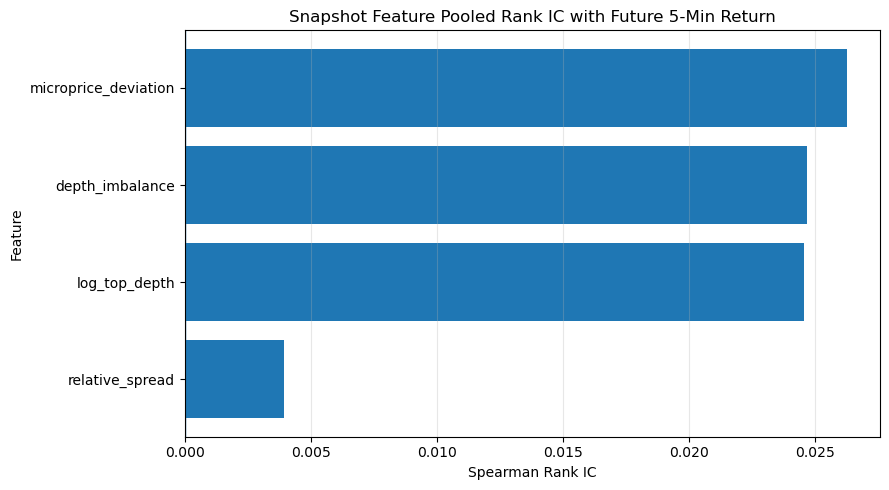

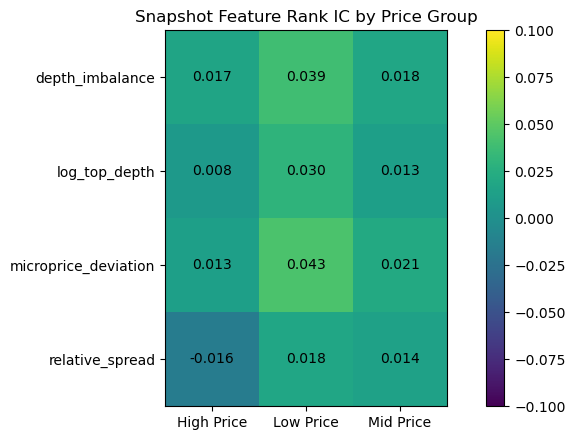

In [139]:
plot_rank_ic_bar(
    snapshot_eval["pooled_ic"],
    "Snapshot Feature Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    snapshot_eval["price_group_ic_pivot"],
    "Snapshot Feature Rank IC by Price Group"
)


### 8.2 Snapshot Feature Interpretation Template

The first feature family examines whether the contemporaneous order-book state contains information about future five-minute returns.

The snapshot features describe four dimensions of the best bid and ask:

- `relative_spread`: transaction-cost and liquidity condition;
- `log_top_depth`: total top-of-book liquidity;
- `depth_imbalance`: relative bid-versus-ask depth pressure;
- `microprice_deviation`: order-book pressure embedded in the microprice relative to the midpoint.

The objective is to distinguish whether short-horizon predictive information is primarily associated with liquidity level, trading friction, or directional order-book pressure.


#### Interim Findings: Snapshot Features and Price-Level Effects

The snapshot analysis identifies order-book pressure as the first persistent predictive mechanism in the sample.

`microprice_deviation` produces a pooled Rank IC of 0.043 and a mean daily IC of 0.062, with positive IC on 81.8% of trading days. `depth_imbalance` exhibits a similar pattern.

The effect is particularly concentrated in low-price stocks. Within the low-price group, mean daily IC reaches approximately 0.12 for both features, and all eight sampled low-price stocks exhibit positive stock-level IC.

The consistency across pooled, daily, price-group, and stock-level analyses suggests that the result is not driven by a single trading day or individual security.

**Predictive interpretation:** contemporaneous top-of-book pressure contains short-horizon continuation information, particularly when the return label has coarser price resolution.

In [140]:
# ============================================================
# Stock-Level IC Decomposition
# ============================================================

stock_level_features = [
    "depth_imbalance",
    "microprice_deviation"
]

stock_ic_rows = []

for code, group_df in master_feature_df.groupby("code"):

    price_group = group_df["price_group"].iloc[0]

    for feature in stock_level_features:

        sub = group_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 30
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        stock_ic_rows.append({
            "code": code,
            "price_group": price_group,
            "feature": feature,
            "rank_ic": rank_ic,
            "abs_rank_ic": abs(rank_ic),
            "n_obs": len(sub)
        })


stock_level_ic_df = pd.DataFrame(stock_ic_rows)

display(
    stock_level_ic_df
    .sort_values(
        ["feature", "rank_ic"],
        ascending=[True, False]
    )
)

,code,price_group,feature,rank_ic,abs_rank_ic,n_obs
48,600488.SH,Low Price,depth_imbalance,0.169428,0.169428,1454
44,600425.SH,Low Price,depth_imbalance,0.083607,0.083607,1595
78,688737.SH,Mid Price,depth_imbalance,0.073306,0.073306,1592
0,000713.SZ,Low Price,depth_imbalance,0.065210,0.065210,1628
42,600182.SH,Mid Price,depth_imbalance,0.057677,0.057677,1588
...,...,...,...,...,...,...
29,300595.SZ,Mid Price,microprice_deviation,-0.006461,0.006461,1636
39,301622.SZ,High Price,microprice_deviation,-0.018002,0.018002,1634
21,002553.SZ,Mid Price,microprice_deviation,-0.024043,0.024043,1638
69,688125.SH,High Price,microprice_deviation,-0.030783,0.030783,1592


In [141]:
# ============================================================
# Stock-Level IC Summary by Price Group
# ============================================================

stock_ic_summary = (
    stock_level_ic_df
    .groupby(
        [
            "price_group",
            "feature"
        ],
        observed=True
    )
    .agg(
        n_stocks=(
            "code",
            "nunique"
        ),
        mean_stock_ic=(
            "rank_ic",
            "mean"
        ),
        median_stock_ic=(
            "rank_ic",
            "median"
        ),
        stock_ic_std=(
            "rank_ic",
            "std"
        ),
        positive_stock_ratio=(
            "rank_ic",
            lambda x: (x > 0).mean()
        ),
        max_stock_ic=(
            "rank_ic",
            "max"
        ),
        min_stock_ic=(
            "rank_ic",
            "min"
        )
    )
    .reset_index()
)


display(stock_ic_summary)

,price_group,feature,n_stocks,mean_stock_ic,median_stock_ic,stock_ic_std,positive_stock_ratio,max_stock_ic,min_stock_ic
0,High Price,depth_imbalance,14,0.018921,0.032520,0.026918,0.785714,0.048590,-0.037874
1,High Price,microprice_deviation,14,0.017814,0.023916,0.029998,0.785714,0.065867,-0.036824
2,Low Price,depth_imbalance,13,0.046109,0.040427,0.044560,0.923077,0.169428,-0.001202
3,Low Price,microprice_deviation,13,0.047102,0.032984,0.045651,0.923077,0.176390,-0.000478
4,Mid Price,depth_imbalance,13,0.020339,0.017873,0.030387,0.692308,0.073306,-0.027913
5,Mid Price,microprice_deviation,13,0.021460,0.015872,0.028818,0.769231,0.080043,-0.024043


Pooled Snapshot Factor Performance

The pooled factor evaluation shows that predictive information is concentrated primarily in directional order-book pressure.

`microprice_deviation` produces the strongest pooled Rank IC of 0.0433, followed by `depth_imbalance` at 0.0380. Both signals have positive predictive directions, indicating that stronger bid-side order-book pressure is associated with higher subsequent five-minute returns.

The daily IC results provide additional evidence of temporal persistence. `microprice_deviation` has a mean daily IC of 0.0625 and an ICIR of 1.17, while `depth_imbalance` has a mean daily IC of 0.0554 and an ICIR of 1.09. Both signals maintain a positive IC on 81.8% of trading days.

In contrast, `relative_spread` contains little pooled ranking information, while `log_top_depth` shows only modest predictive strength.

The snapshot analysis therefore suggests that the directional configuration of the order book is more informative than the absolute level of displayed liquidity or the contemporaneous bid-ask spread.

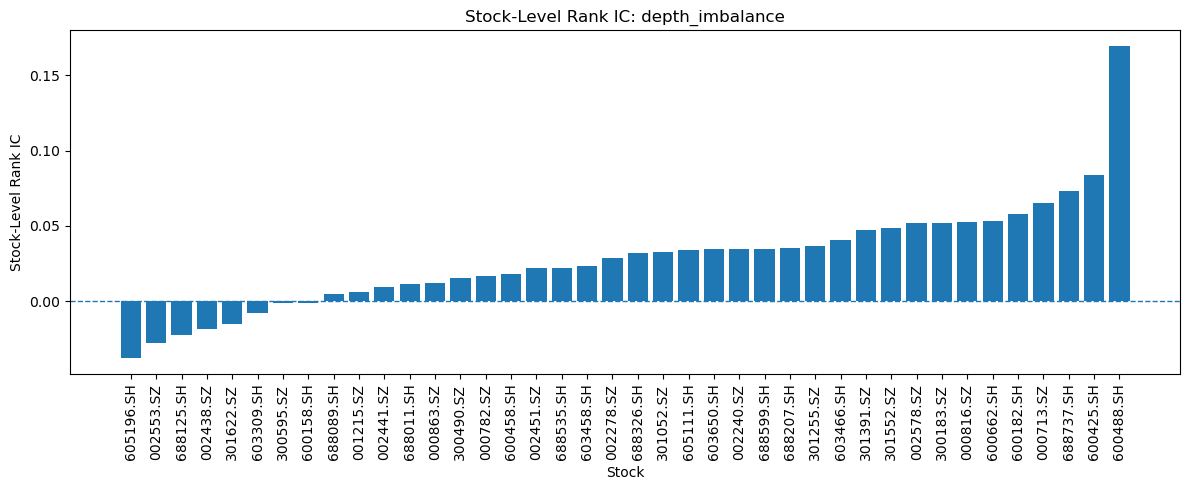

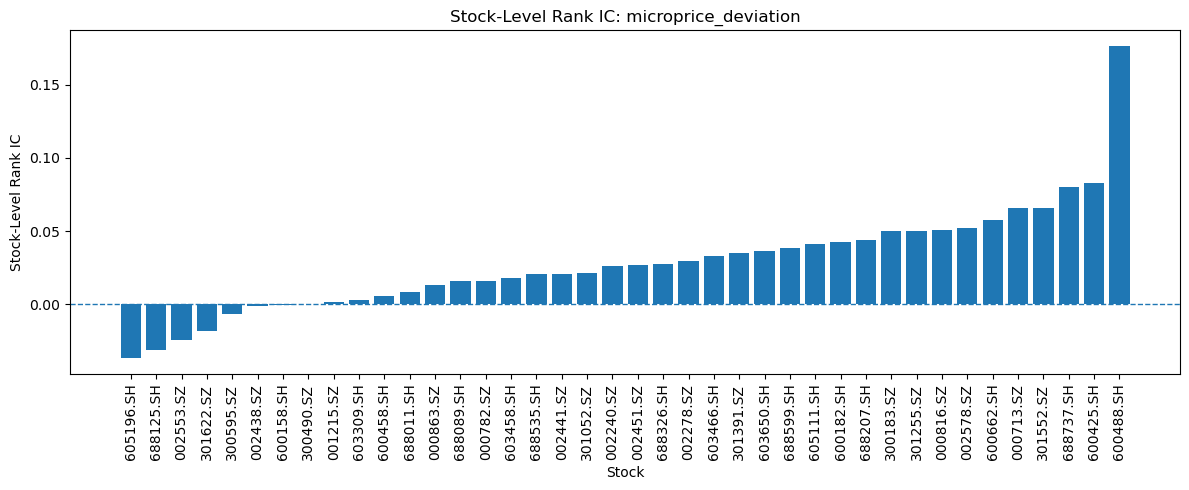

In [142]:
# ============================================================
# Stock-Level IC Distribution
# ============================================================

for feature in stock_level_features:

    plot_df = (
        stock_level_ic_df[
            stock_level_ic_df["feature"] == feature
        ]
        .sort_values("rank_ic")
        .copy()
    )

    plt.figure(figsize=(12, 5))

    x = np.arange(len(plot_df))

    plt.bar(
        x,
        plot_df["rank_ic"]
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xticks(
        x,
        plot_df["code"],
        rotation=90
    )

    plt.xlabel("Stock")
    plt.ylabel("Stock-Level Rank IC")

    plt.title(
        f"Stock-Level Rank IC: {feature}"
    )

    plt.tight_layout()
    plt.show()

The predictive strength of order-book pressure differs substantially across price groups.

For Low Price stocks, both `depth_imbalance` and `microprice_deviation` achieve Rank IC values close to 0.08. Their mean daily IC values exceed 0.11, with ICIR values above 1.3.

The corresponding pooled Rank IC values for Mid Price and High Price stocks are substantially weaker, generally between 0.01 and 0.02.

This result extends the price-level heterogeneity identified in the label diagnostics. Price level affects not only the discretization of future five-minute returns, but also the strength of the relationship between the contemporaneous order book and subsequent price movement.

One possible interpretation is that, under a larger relative tick size, displayed top-of-book pressure represents a more economically meaningful shift in the short-horizon price state. Order-book imbalance therefore appears to contain stronger directional information for low-priced stocks.

C:\Users\work\AppData\Local\Temp\ipykernel_16976\4065649081.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


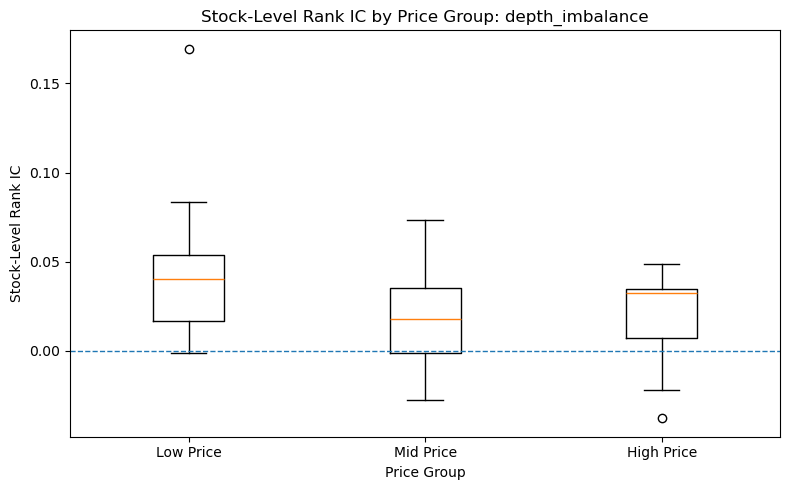

C:\Users\work\AppData\Local\Temp\ipykernel_16976\4065649081.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


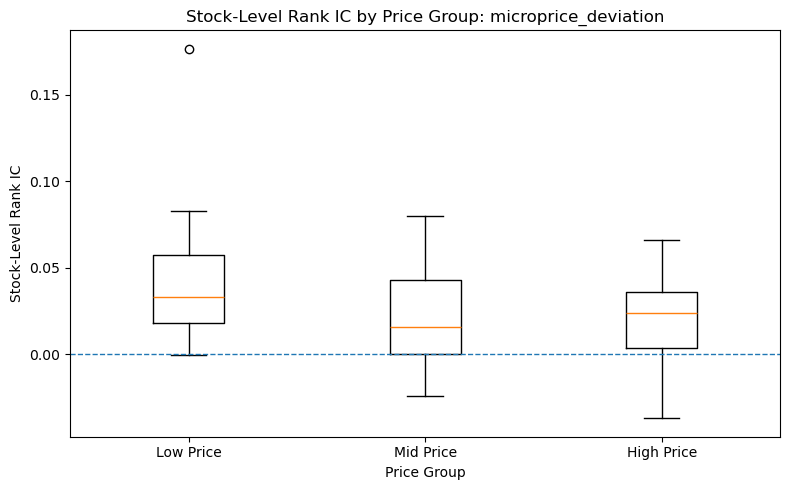

In [143]:
# ============================================================
# Stock-Level IC by Price Group
# ============================================================

for feature in stock_level_features:

    plot_df = stock_level_ic_df[
        stock_level_ic_df["feature"] == feature
    ].copy()

    price_order = [
        "Low Price",
        "Mid Price",
        "High Price"
    ]

    data = [
        plot_df.loc[
            plot_df["price_group"] == group,
            "rank_ic"
        ].dropna().values
        for group in price_order
    ]

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        data,
        labels=price_order
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Price Group")
    plt.ylabel("Stock-Level Rank IC")

    plt.title(
        f"Stock-Level Rank IC by Price Group: {feature}"
    )

    plt.tight_layout()
    plt.show()

The price-group result is further examined using stock-level Rank IC.

Within the Low Price group, all eight stocks exhibit positive Rank IC for both `depth_imbalance` and `microprice_deviation`. The mean stock-level IC is approximately 0.081 for both features, while the median IC is also close to 0.08.

The similarity between the mean and median stock-level IC, together with a 100% positive-stock ratio, indicates that the stronger Low Price signal is broad-based across the sampled stocks rather than being driven by a small number of extreme observations.

Mid Price and High Price stocks exhibit substantially greater cross-stock variation, including negative stock-level IC for several securities.

The evidence therefore suggests that order-book pressure is a particularly stable short-horizon signal within the Low Price subgroup.

#### Stock-Level IC Decomposition

Unsigned trading activity provides limited standalone directional information.

Five-minute turnover produces the strongest pooled Rank IC within the family at approximately 0.021, but its daily IC is weak and unstable. Volume and turnover variables generally exhibit low ICIR values and inconsistent daily directions.

The result suggests that trading intensity alone does not determine the direction of the next five-minute return.

**Predictive implication:** activity measures may describe the strength of the market state, but directional information requires either signed trading pressure, recent price movement, or contemporaneous order-book conditions.

## 9. Trade Activity Features

The second feature family examines whether recent trading activity contains directional information about future five-minute returns.

Unlike the snapshot order-book features, trade activity variables primarily measure the magnitude of recent market participation rather than the direction of buying or selling pressure.

The evaluated features include rolling trading volume, turnover, five-minute trading intensity, and volume acceleration across multiple lookback horizons.

This section therefore asks whether unusually active trading alone is sufficient to rank subsequent short-horizon returns.


In [144]:
trade_base = minute_panel.copy()
trade_base = trade_base.sort_values(["code", "date", "minute"]).reset_index(drop=True)

group_keys = ["code", "date"]

trade_base["minute_volume"] = trade_base.groupby(group_keys)["sum_volume"].diff()
trade_base["minute_turnover"] = trade_base.groupby(group_keys)["sum_amount"].diff()

display(
    trade_base[[
        "code", "date", "minute", "sum_volume", "minute_volume",
        "sum_amount", "minute_turnover"
    ]].head(10)
)

display(trade_base[["minute_volume", "minute_turnover"]].describe().T)


,code,date,minute,sum_volume,minute_volume,sum_amount,minute_turnover
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,222800,NaN,1478169.0,NaN
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,394100,171300.0,2615055.0,1136886.0
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,571100,177000.0,3788036.0,1172981.0
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,614800,43700.0,4077336.0,289300.0
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,652200,37400.0,4325279.0,247943.0
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,726100,73900.0,4815320.0,490041.0
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,759300,33200.0,5035467.0,220147.0
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,816800,57500.0,5416732.0,381265.0
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,879300,62500.0,5830629.0,413897.0
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,906500,27200.0,6010752.0,180123.0


,count,mean,std,min,25%,50%,75%,max
minute_volume,74614.0,2.207146e+05,5.731134e+05,0.0,19900.0,69041.0,212060.75,24733800.0
minute_turnover,74614.0,3.609484e+06,7.999968e+06,0.0,454353.5,1259709.5,3465025.75,298430130.0


In [145]:
trade_base["volume_1m"] = trade_base["minute_volume"]
trade_base["turnover_1m"] = trade_base["minute_turnover"]

for window in [3, 5]:
    trade_base[f"volume_{window}m"] = (
        trade_base
        .groupby(group_keys)["minute_volume"]
        .transform(lambda x: x.rolling(window=window, min_periods=window).sum())
    )
    trade_base[f"turnover_{window}m"] = (
        trade_base
        .groupby(group_keys)["minute_turnover"]
        .transform(lambda x: x.rolling(window=window, min_periods=window).sum())
    )

trade_base["trade_intensity_5m"] = trade_base["volume_5m"] / 5

trade_base["previous_volume_3m"] = (
    trade_base
    .groupby(group_keys)["minute_volume"]
    .transform(lambda x: x.shift(3).rolling(window=3, min_periods=3).sum())
)

trade_base["volume_acceleration"] = (
    (trade_base["volume_3m"] - trade_base["previous_volume_3m"])
    / (trade_base["previous_volume_3m"].abs() + 1)
)

display(
    trade_base[[
        "code", "date", "minute", "minute_volume", "volume_3m",
        "previous_volume_3m", "volume_acceleration", "trade_intensity_5m"
    ]].head(15)
)


,code,date,minute,minute_volume,volume_3m,previous_volume_3m,volume_acceleration,trade_intensity_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,NaN,NaN,NaN,NaN,NaN
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,171300.0,NaN,NaN,NaN,NaN
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,177000.0,NaN,NaN,NaN,NaN
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,43700.0,392000.0,NaN,NaN,NaN
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,37400.0,258100.0,NaN,NaN,NaN
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,73900.0,155000.0,NaN,NaN,100660.0
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,33200.0,144500.0,392000.0,-0.631376,73040.0
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,57500.0,164600.0,258100.0,-0.362261,49140.0
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,62500.0,153200.0,155000.0,-0.011613,52900.0
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,27200.0,147200.0,144500.0,0.018685,50860.0


In [146]:
trade_candidate_features = [
    "volume_1m",
    "volume_3m",
    "volume_5m",
    "turnover_1m",
    "turnover_3m",
    "turnover_5m",
    "trade_intensity_5m",
    "volume_acceleration"
]

trade_feature_cols = ["code", "date", "minute"] + trade_candidate_features

master_feature_df = master_feature_df.merge(
    trade_base[trade_feature_cols],
    on=["code", "date", "minute"],
    how="left"
)

print("master_feature_df shape:", master_feature_df.shape)
display(
    master_feature_df[["code", "date", "minute", "price_group"] + trade_candidate_features + ["future_return_5m"]].head(12)
)


master_feature_df shape: (64039, 41)


,code,date,minute,price_group,volume_1m,volume_3m,volume_5m,turnover_1m,turnover_3m,turnover_5m,trade_intensity_5m,volume_acceleration,future_return_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,Low Price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.001509
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,Low Price,171300.0,NaN,NaN,1136886.0,NaN,NaN,NaN,NaN,-0.001505
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,Low Price,177000.0,NaN,NaN,1172981.0,NaN,NaN,NaN,NaN,0.001512
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,Low Price,43700.0,392000.0,NaN,289300.0,2599167.0,NaN,NaN,NaN,0.000000
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,Low Price,37400.0,258100.0,NaN,247943.0,1710224.0,NaN,NaN,NaN,0.000000
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,Low Price,73900.0,155000.0,503300.0,490041.0,1027284.0,3337151.0,100660.0,NaN,-0.001507
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,Low Price,33200.0,144500.0,365200.0,220147.0,958131.0,2420412.0,73040.0,-0.631376,-0.001507
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,Low Price,57500.0,164600.0,245700.0,381265.0,1091453.0,1628696.0,49140.0,-0.362261,0.000000
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,Low Price,62500.0,153200.0,264500.0,413897.0,1015309.0,1753293.0,52900.0,-0.011613,0.000000
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,Low Price,27200.0,147200.0,254300.0,180123.0,975285.0,1685473.0,50860.0,0.018685,0.000000


In [147]:
display(master_feature_df[trade_candidate_features].describe().T)

display(
    master_feature_df[trade_candidate_features]
    .isna()
    .mean()
    .rename("missing_rate")
    .to_frame()
)


,count,mean,std,min,25%,50%,75%,max
volume_1m,61533.0,2.356753e+05,5.797320e+05,0.000000,2.334300e+04,7.830000e+04,2.335000e+05,2.429910e+07
volume_3m,56528.0,6.882981e+05,1.515694e+06,1100.000000,8.080000e+04,2.552475e+05,7.118002e+05,4.447255e+07
volume_5m,51523.0,1.129387e+06,2.362042e+06,4400.000000,1.410930e+05,4.361260e+05,1.199500e+06,5.966305e+07
turnover_1m,61533.0,3.888251e+06,8.198982e+06,0.000000,5.316290e+05,1.410958e+06,3.797415e+06,2.834957e+08
turnover_3m,56528.0,1.139979e+07,2.219109e+07,15694.000000,1.871273e+06,4.453169e+06,1.128250e+07,4.986073e+08
turnover_5m,51523.0,1.873891e+07,3.499514e+07,89686.000000,3.280104e+06,7.493516e+06,1.880415e+07,6.583762e+08
trade_intensity_5m,51523.0,2.258774e+05,4.724084e+05,880.000000,2.821860e+04,8.722520e+04,2.399000e+05,1.193261e+07
volume_acceleration,49022.0,7.392297e-02,9.814636e-01,-0.983785,-3.882705e-01,-1.298479e-01,2.575932e-01,5.291005e+01


,missing_rate
volume_1m,0.039132
volume_3m,0.117288
volume_5m,0.195443
turnover_1m,0.039132
turnover_3m,0.117288
turnover_5m,0.195443
trade_intensity_5m,0.195443
volume_acceleration,0.234498


#### Rolling Activity Feature Construction

Trading activity is aggregated over one-, three-, and five-minute rolling windows.

Volume measures capture the number of shares traded, while turnover measures the economic value of recent trading activity. `trade_intensity_5m` summarizes average activity over the five-minute window, and `volume_acceleration` compares recent trading activity with its preceding level.

The missing observations in the rolling features are primarily structural. Longer lookback windows require sufficient historical observations at the beginning of each stock-day sequence. The higher missing rate of `volume_acceleration` additionally reflects its lagged-window construction.

These observations are therefore excluded from factor evaluation rather than interpreted as data-quality failures.

### 9.1 Trade Activity Feature Evaluation

Trade activity features are also evaluated using the same parallel framework:

- Pooled IC
- Daily IC stability
- Price-group IC
- Price-group daily IC stability


In [148]:
trade_eval = evaluate_feature_family(
    master_feature_df,
    trade_candidate_features,
    family_name="Trade Activity"
)

print("Pooled IC:")
display(trade_eval["pooled_ic"])

print("Daily IC Summary:")
display(trade_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(trade_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(trade_eval["price_group_daily_summary"])


Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Trade Activity,turnover_3m,-0.040909,-0.035642,0.035642,56528,Negative
1,Trade Activity,turnover_5m,-0.040182,-0.033484,0.033484,51523,Negative
2,Trade Activity,turnover_1m,-0.031023,-0.033116,0.033116,61533,Negative
3,Trade Activity,volume_acceleration,-0.018513,-0.014955,0.014955,49022,Negative
4,Trade Activity,volume_1m,-0.028542,-0.014141,0.014141,61533,Negative
5,Trade Activity,volume_3m,-0.036029,-0.013625,0.013625,56528,Negative
6,Trade Activity,volume_5m,-0.030617,-0.012082,0.012082,51523,Negative
7,Trade Activity,trade_intensity_5m,-0.030617,-0.012082,0.012082,51523,Negative


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
turnover_3m,-0.024316,0.081041,0.476190,63,-0.300044,0.024316
turnover_5m,-0.022928,0.083776,0.460317,63,-0.273677,0.022928
turnover_1m,-0.021248,0.074486,0.507937,63,-0.285257,0.021248
volume_acceleration,-0.006948,0.055241,0.492063,63,-0.125773,0.006948
volume_3m,-0.005206,0.077209,0.492063,63,-0.067428,0.005206
volume_1m,-0.004977,0.070006,0.476190,63,-0.071089,0.004977
trade_intensity_5m,-0.004344,0.085725,0.492063,63,-0.050670,0.004344
volume_5m,-0.004344,0.085725,0.492063,63,-0.050670,0.004344


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
trade_intensity_5m,-0.019305,-0.031596,-0.032303
turnover_1m,-0.019762,-0.037184,-0.039720
turnover_3m,-0.023346,-0.038789,-0.041134
turnover_5m,-0.020384,-0.040398,-0.037151
volume_1m,-0.016541,-0.031103,-0.035609
volume_3m,-0.020176,-0.030898,-0.036607
volume_5m,-0.019305,-0.031596,-0.032303
volume_acceleration,-0.017457,-0.008008,-0.019501


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,trade_intensity_5m,-0.014070,0.108964,0.476190,63,-0.129129
1,High Price,turnover_1m,-0.009103,0.096654,0.539683,63,-0.094177
2,High Price,turnover_3m,-0.011472,0.104271,0.555556,63,-0.110026
3,High Price,turnover_5m,-0.008268,0.112130,0.492063,63,-0.073736
4,High Price,volume_1m,-0.007906,0.093158,0.507937,63,-0.084861
5,High Price,volume_3m,-0.011740,0.101170,0.523810,63,-0.116041
6,High Price,volume_5m,-0.014070,0.108964,0.476190,63,-0.129129
7,High Price,volume_acceleration,-0.011220,0.077553,0.492063,63,-0.144677
8,Low Price,trade_intensity_5m,-0.021819,0.107663,0.444444,63,-0.202664
9,Low Price,turnover_1m,-0.023258,0.093022,0.412698,63,-0.250029


#### Single-Factor Performance

Raw trading activity exhibits substantially weaker directional predictive power than the order-book pressure signals identified in the previous section.

Among the activity-level features, `turnover_5m` produces the strongest positive pooled Rank IC of 0.0211. Three- and five-minute volume and turnover measures generally show small positive Rank IC values between approximately 0.01 and 0.02.

One-minute activity measures contain almost no ranking information, suggesting that very short trading bursts are dominated by noise. Activity accumulated over three to five minutes appears marginally more informative.

`volume_acceleration` is the strongest activity feature in absolute Rank IC, with a value of -0.0268. The negative direction suggests a possible short-horizon reversal or activity-exhaustion effect. However, its low ICIR and limited daily direction consistency indicate that the relationship is not sufficiently stable to be treated as a standalone predictive factor.

Overall, recent trading activity appears to describe the intensity of the market state more effectively than the direction of future returns.

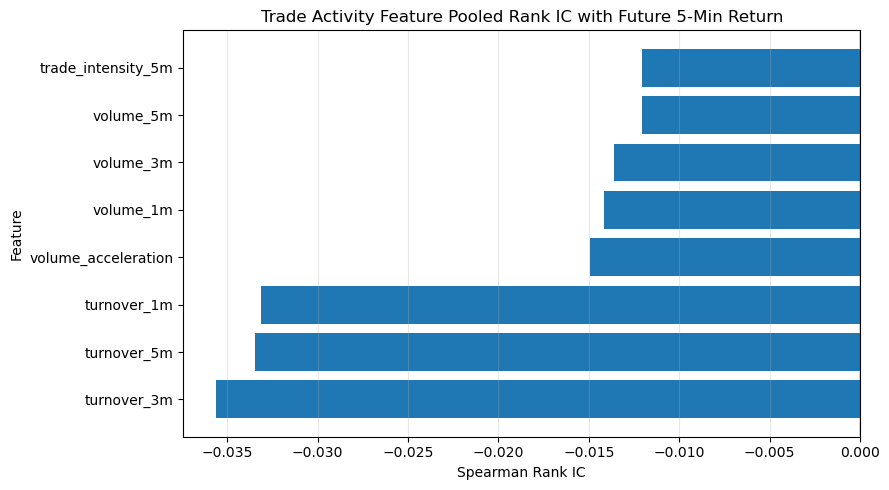

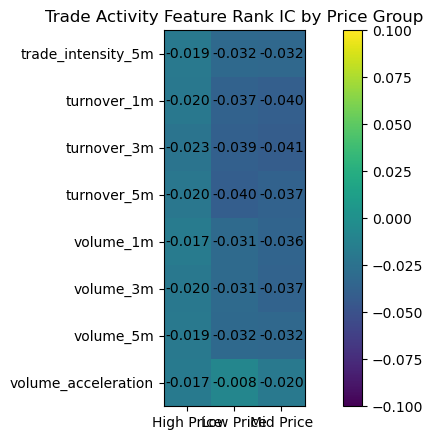

In [149]:
plot_rank_ic_bar(
    trade_eval["pooled_ic"],
    "Trade Activity Feature Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    trade_eval["price_group_ic_pivot"],
    "Trade Activity Feature Rank IC by Price Group"
)


#### Interim Findings: Trade Activity Features

The trade activity analysis indicates that unsigned volume and turnover measures are weak standalone directional predictors.

Higher trading activity identifies periods of greater market participation, but does not distinguish whether the underlying pressure originates from aggressive buying or aggressive selling.

This limitation motivates the next feature family. Signed trade-pressure variables are introduced to combine recent trading activity with an estimated direction of trade initiation.

The analysis therefore moves from measuring:

> **How much trading occurred?**

to:

> **In which direction did the recent trading pressure occur?**

## 10. Signed Trading Pressure Features

### Research Motivation

Raw trading activity measures how much trading occurs, but it does not identify which side of the market is driving the activity.

For example, high trading volume may result from aggressive buying, aggressive selling, or intense two-sided trading. Therefore, volume alone contains limited information about the direction of future price movements.

Signed trading pressure introduces a directional component into trading activity:

```text
Buyer-side pressure  → Positive
Seller-side pressure → Negative

Last Price ≥ Best Ask
→ Buyer-pressure proxy (+1)

Last Price ≤ Best Bid
→ Seller-pressure proxy (-1)

Inside the spread
→ Ambiguous pressure (0)

In [150]:
if "minute_volume" not in master_feature_df.columns:
    master_feature_df = master_feature_df.merge(
        trade_base[
            [
                "code",
                "date",
                "minute",
                "minute_volume",
                "volume_1m",
                "volume_3m",
                "volume_5m",
                "turnover_1m",
                "turnover_3m",
                "turnover_5m",
                "volume_acceleration"
            ]
        ],
        on=["code", "date", "minute"],
        how="left"
    )

In [151]:
# ============================================================
# Signed Trading Pressure Features
# ============================================================

# Start from master feature table
# master_feature_df should already contain:
# code, date, minute, mid_price, bp0, ap0, last_price,
# minute_volume, future_return_5m, price_group

master_feature_df = master_feature_df.sort_values(
    ["code", "date", "minute"]
).reset_index(drop=True)


# ------------------------------------------------------------
# Trade sign proxy
#
# +1: last price at or above ask -> buyer-initiated proxy
# -1: last price at or below bid -> seller-initiated proxy
#  0: ambiguous / inside spread
# ------------------------------------------------------------

master_feature_df["trade_sign_proxy"] = np.select(
    [
        master_feature_df["last_price"] >= master_feature_df["ap0"],
        master_feature_df["last_price"] <= master_feature_df["bp0"]
    ],
    [
        1,
        -1
    ],
    default=0
)


# ------------------------------------------------------------
# Signed minute volume
# ------------------------------------------------------------

master_feature_df["signed_volume_1m"] = (
    master_feature_df["trade_sign_proxy"]
    * master_feature_df["minute_volume"]
)


display(
    master_feature_df[
        [
            "code",
            "date",
            "minute",
            "last_price",
            "bp0",
            "ap0",
            "trade_sign_proxy",
            "minute_volume",
            "signed_volume_1m"
        ]
    ].head(15)
)

,code,date,minute,last_price,bp0,ap0,trade_sign_proxy,minute_volume,signed_volume_1m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.63,6.62,6.63,1,NaN,NaN
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,6.64,6.64,6.65,-1,171300.0,-171300.0
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,6.62,6.61,6.62,1,177000.0,177000.0
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,6.63,6.62,6.63,1,43700.0,43700.0
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,6.63,6.62,6.63,1,37400.0,37400.0
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,6.63,6.63,6.64,-1,73900.0,-73900.0
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,6.63,6.63,6.64,-1,33200.0,-33200.0
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,6.63,6.62,6.63,1,57500.0,57500.0
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,6.62,6.62,6.63,-1,62500.0,-62500.0
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,6.63,6.62,6.63,1,27200.0,27200.0


In [152]:
# ============================================================
# Rolling Signed Trading Pressure
# ============================================================

group_keys = ["code", "date"]

for window in [3, 5]:

    master_feature_df[f"signed_volume_{window}m"] = (
        master_feature_df
        .groupby(group_keys)["signed_volume_1m"]
        .transform(
            lambda x: x.rolling(
                window=window,
                min_periods=window
            ).sum()
        )
    )

    master_feature_df[f"abs_volume_{window}m"] = (
        master_feature_df
        .groupby(group_keys)["minute_volume"]
        .transform(
            lambda x: x.rolling(
                window=window,
                min_periods=window
            ).sum()
        )
    )


# ------------------------------------------------------------
# Signed volume imbalance ratios
# ------------------------------------------------------------

master_feature_df["signed_volume_imbalance_1m"] = (
    master_feature_df["signed_volume_1m"]
    / (
        master_feature_df["minute_volume"].abs()
        + 1
    )
)

for window in [3, 5]:

    master_feature_df[f"signed_volume_imbalance_{window}m"] = (
        master_feature_df[f"signed_volume_{window}m"]
        / (
            master_feature_df[f"abs_volume_{window}m"].abs()
            + 1
        )
    )


signed_pressure_features = [
    "trade_sign_proxy",
    "signed_volume_1m",
    "signed_volume_3m",
    "signed_volume_5m",
    "signed_volume_imbalance_1m",
    "signed_volume_imbalance_3m",
    "signed_volume_imbalance_5m"
]


display(
    master_feature_df[
        [
            "code",
            "date",
            "minute"
        ]
        + signed_pressure_features
        + [
            "future_return_5m",
            "price_group"
        ]
    ].head(15)
)

,code,date,minute,trade_sign_proxy,signed_volume_1m,signed_volume_3m,signed_volume_5m,signed_volume_imbalance_1m,signed_volume_imbalance_3m,signed_volume_imbalance_5m,future_return_5m,price_group
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,1,NaN,NaN,NaN,NaN,NaN,NaN,0.001509,Low Price
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,-1,-171300.0,NaN,NaN,-0.999994,NaN,NaN,-0.001505,Low Price
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,1,177000.0,NaN,NaN,0.999994,NaN,NaN,0.001512,Low Price
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,1,43700.0,49400.0,NaN,0.999977,0.126020,NaN,0.000000,Low Price
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,1,37400.0,258100.0,NaN,0.999973,0.999996,NaN,0.000000,Low Price
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,-1,-73900.0,7200.0,12900.0,-0.999986,0.046451,0.025631,-0.001507,Low Price
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,-1,-33200.0,-69700.0,151000.0,-0.999970,-0.482350,0.413471,-0.001507,Low Price
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,1,57500.0,-49600.0,31500.0,0.999983,-0.301335,0.128205,0.000000,Low Price
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,-1,-62500.0,-38200.0,-74700.0,-0.999984,-0.249346,-0.282419,0.000000,Low Price
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,1,27200.0,22200.0,-84900.0,0.999963,0.150814,-0.333856,0.000000,Low Price


`trade_sign_proxy` classifies the current trading state as buy-dominated, sell-dominated, or neutral using the relationship between the observed trade price and the best bid and ask.

Rolling signed-volume features aggregate recent trading activity after weighting volume by the estimated trade direction. Signed-volume imbalance normalizes directional volume by total activity and therefore measures the relative dominance of buy- versus sell-initiated trading.

The rolling features exhibit the same structural missingness as the trade-activity variables. Longer windows require more historical observations at the beginning of each stock-day sequence. These missing values reflect feature initialization rather than data-quality failures.

In [153]:
# ============================================================
# Signed Pressure Feature Diagnostics
# ============================================================

display(
    master_feature_df[
        signed_pressure_features
    ].describe().T
)

display(
    master_feature_df[
        signed_pressure_features
    ]
    .isna()
    .mean()
    .rename("missing_rate")
    .to_frame()
)

,count,mean,std,min,25%,50%,75%,max
trade_sign_proxy,64039.0,0.005622,9.592397e-01,-1.0,-1.000000,0.000000,1.000000,1.0
signed_volume_1m,61533.0,5810.620204,6.187029e+05,-24299100.0,-68200.000000,0.000000,74100.000000,20647150.0
signed_volume_3m,56518.0,16360.004246,1.066716e+06,-37800168.0,-95600.000000,1307.000000,109876.500000,37817900.0
signed_volume_5m,51505.0,24026.645316,1.399149e+06,-51290202.0,-122400.000000,2016.000000,142956.000000,54565500.0
signed_volume_imbalance_1m,61533.0,0.006727,9.584117e-01,-1.0,-0.999985,0.000000,0.999987,1.0
signed_volume_imbalance_3m,56518.0,0.009464,6.182341e-01,-1.0,-0.474947,0.017566,0.492730,1.0
signed_volume_imbalance_5m,51505.0,0.008548,5.029305e-01,-1.0,-0.364704,0.014888,0.385858,1.0


,missing_rate
trade_sign_proxy,0.000000
signed_volume_1m,0.039132
signed_volume_3m,0.117444
signed_volume_5m,0.195724
signed_volume_imbalance_1m,0.039132
signed_volume_imbalance_3m,0.117444
signed_volume_imbalance_5m,0.195724


In [154]:
# ============================================================
# Pooled IC: Signed Trading Pressure Features
# ============================================================

signed_pooled_rows = []

for feature in signed_pressure_features:

    sub = master_feature_df[
        [
            feature,
            "future_return_5m"
        ]
    ].dropna()

    if (
        len(sub) < 20
        or sub[feature].nunique() < 2
        or sub["future_return_5m"].nunique() < 2
    ):
        continue

    pearson_ic = sub[feature].corr(
        sub["future_return_5m"],
        method="pearson"
    )

    rank_ic = sub[feature].corr(
        sub["future_return_5m"],
        method="spearman"
    )

    signed_pooled_rows.append({
        "family": "Signed Trading Pressure",
        "feature": feature,
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "abs_rank_ic": abs(rank_ic),
        "n_obs": len(sub),
        "signal_direction": (
            "Positive"
            if rank_ic > 0
            else "Negative"
        )
    })


signed_pooled_ic = (
    pd.DataFrame(signed_pooled_rows)
    .sort_values(
        "abs_rank_ic",
        ascending=False
    )
    .reset_index(drop=True)
)

display(signed_pooled_ic)

,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Signed Trading Pressure,trade_sign_proxy,0.015502,0.019603,0.019603,64039,Positive
1,Signed Trading Pressure,signed_volume_1m,-0.005784,0.017307,0.017307,61533,Positive
2,Signed Trading Pressure,signed_volume_imbalance_1m,0.018375,0.017307,0.017307,61533,Positive
3,Signed Trading Pressure,signed_volume_imbalance_3m,0.011651,0.012639,0.012639,56518,Positive
4,Signed Trading Pressure,signed_volume_imbalance_5m,0.010913,0.011393,0.011393,51505,Positive
5,Signed Trading Pressure,signed_volume_3m,-0.013937,0.009986,0.009986,56518,Positive
6,Signed Trading Pressure,signed_volume_5m,-0.010437,0.007605,0.007605,51505,Positive


Adding directional information improves the predictive content of recent trading activity.

The strongest pooled signed-pressure signal is `signed_volume_3m`, with a Rank IC of 0.0320. `trade_sign_proxy`, `signed_volume_1m`, and `signed_volume_imbalance_1m` also produce positive Rank IC values close to 0.028.

These values are generally stronger than the unsigned volume and turnover signals evaluated in the previous section. This indicates that the direction of recent trading pressure contains incremental information beyond trading intensity alone.

However, pooled IC does not fully describe temporal stability. `trade_sign_proxy` provides the most balanced result, with a mean daily IC of 0.0180, a positive daily-IC ratio of 68.2%, and complete sample coverage.

In contrast, the higher pooled IC of `signed_volume_3m` is not matched by stable daily performance.

In [155]:
# ============================================================
# Daily IC: Signed Trading Pressure Features
# ============================================================

signed_daily_rows = []

for date, date_df in master_feature_df.groupby("date"):

    for feature in signed_pressure_features:

        sub = date_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 20
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        signed_daily_rows.append({
            "date": date,
            "feature": feature,
            "rank_ic": rank_ic
        })


signed_daily_ic = pd.DataFrame(signed_daily_rows)

signed_daily_ic_summary = (
    signed_daily_ic
    .groupby("feature")
    .agg(
        mean_daily_ic=("rank_ic", "mean"),
        ic_std=("rank_ic", "std"),
        positive_ic_ratio=(
            "rank_ic",
            lambda x: (x > 0).mean()
        ),
        n_days=("rank_ic", "count")
    )
)

signed_daily_ic_summary["icir"] = (
    signed_daily_ic_summary["mean_daily_ic"]
    / signed_daily_ic_summary["ic_std"]
)

signed_daily_ic_summary["abs_mean_daily_ic"] = (
    signed_daily_ic_summary["mean_daily_ic"].abs()
)

signed_daily_ic_summary = (
    signed_daily_ic_summary
    .sort_values(
        "abs_mean_daily_ic",
        ascending=False
    )
)

display(signed_daily_ic_summary)

,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
trade_sign_proxy,0.015044,0.029525,0.682540,63,0.509556,0.015044
signed_volume_1m,0.013650,0.034510,0.619048,63,0.395545,0.013650
signed_volume_imbalance_1m,0.013650,0.034510,0.619048,63,0.395545,0.013650
signed_volume_imbalance_3m,0.005683,0.048364,0.571429,63,0.117498,0.005683
signed_volume_3m,0.004417,0.044921,0.619048,63,0.098332,0.004417
signed_volume_imbalance_5m,0.002592,0.059671,0.539683,63,0.043434,0.002592
signed_volume_5m,0.000826,0.058089,0.555556,63,0.014213,0.000826


In [156]:
# ============================================================
# Price-Group IC: Signed Trading Pressure Features
# ============================================================

signed_price_group_rows = []

for price_group, group_df in master_feature_df.groupby(
    "price_group",
    observed=True
):

    for feature in signed_pressure_features:

        sub = group_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 20
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        signed_price_group_rows.append({
            "price_group": price_group,
            "feature": feature,
            "rank_ic": rank_ic,
            "abs_rank_ic": abs(rank_ic),
            "n_obs": len(sub)
        })


signed_price_group_ic = pd.DataFrame(
    signed_price_group_rows
)

signed_price_group_rank_ic = (
    signed_price_group_ic
    .pivot(
        index="feature",
        columns="price_group",
        values="rank_ic"
    )
)

display(signed_price_group_rank_ic)

price_group,High Price,Low Price,Mid Price
feature,,,
signed_volume_1m,0.011244,0.022977,0.016290
signed_volume_3m,0.011581,0.008355,0.012218
signed_volume_5m,0.003390,0.005163,0.015078
signed_volume_imbalance_1m,0.011244,0.022977,0.016290
signed_volume_imbalance_3m,0.010413,0.011044,0.018327
signed_volume_imbalance_5m,0.009431,0.009026,0.017660
trade_sign_proxy,0.012685,0.026828,0.020989


In [157]:
# ============================================================
# Price-Group Daily IC: Signed Trading Pressure Features
# ============================================================

signed_pg_daily_rows = []

for (price_group, date), group_df in master_feature_df.groupby(
    [
        "price_group",
        "date"
    ],
    observed=True
):

    for feature in signed_pressure_features:

        sub = group_df[
            [
                feature,
                "future_return_5m"
            ]
        ].dropna()

        if (
            len(sub) < 10
            or sub[feature].nunique() < 2
            or sub["future_return_5m"].nunique() < 2
        ):
            continue

        rank_ic = sub[feature].corr(
            sub["future_return_5m"],
            method="spearman"
        )

        signed_pg_daily_rows.append({
            "price_group": price_group,
            "date": date,
            "feature": feature,
            "rank_ic": rank_ic
        })


signed_pg_daily_ic = pd.DataFrame(
    signed_pg_daily_rows
)

signed_pg_daily_ic_summary = (
    signed_pg_daily_ic
    .groupby(
        [
            "price_group",
            "feature"
        ],
        observed=True
    )
    .agg(
        mean_daily_ic=("rank_ic", "mean"),
        ic_std=("rank_ic", "std"),
        positive_ic_ratio=(
            "rank_ic",
            lambda x: (x > 0).mean()
        ),
        n_days=("rank_ic", "count")
    )
    .reset_index()
)

signed_pg_daily_ic_summary["icir"] = (
    signed_pg_daily_ic_summary["mean_daily_ic"]
    / signed_pg_daily_ic_summary["ic_std"]
)

display(signed_pg_daily_ic_summary)

,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,signed_volume_1m,0.007825,0.052988,0.619048,63,0.147678
1,High Price,signed_volume_3m,0.005658,0.077704,0.571429,63,0.072813
2,High Price,signed_volume_5m,-0.001140,0.107277,0.444444,63,-0.010628
3,High Price,signed_volume_imbalance_1m,0.007825,0.052988,0.619048,63,0.147678
4,High Price,signed_volume_imbalance_3m,0.004861,0.082176,0.587302,63,0.059157
5,High Price,signed_volume_imbalance_5m,0.000873,0.107429,0.523810,63,0.008123
6,High Price,trade_sign_proxy,0.009521,0.046626,0.603175,63,0.204205
7,Low Price,signed_volume_1m,0.017950,0.071432,0.634921,63,0.251293
8,Low Price,signed_volume_3m,0.000159,0.092368,0.507937,63,0.001722
9,Low Price,signed_volume_5m,-0.004868,0.108870,0.444444,63,-0.044711


#### Signed Trading Pressure Findings

Signed trading variables provide stronger directional information than unsigned activity measures, but their stability remains moderate.

`trade_sign_proxy` is the most persistent feature in the family, with positive daily IC on approximately 68% of trading days. The signal is stronger among low-price stocks.

Several signed-volume variables exhibit similar pooled IC but weaker daily stability. Later redundancy analysis also shows that the one-minute signed-volume measures contain highly overlapping rank information.

**Predictive implication:** executed trade direction contributes a distinct information channel, but a parsimonious representative signal is preferable to including multiple highly correlated signed-flow variables.

### 11. Price Momentum Features

Price momentum features describe the recent direction of price movement before time \(t\).

This feature family asks:

> Does recent price movement contain information about the next 5-minute return?

Three backward-looking return windows are constructed:

| Feature | Definition | Interpretation |
|---|---|---|
| `return_1m` | Mid-price return over the previous 1 minute | Very short-term price movement |
| `return_3m` | Mid-price return over the previous 3 minutes | Short-term price trend |
| `return_5m` | Mid-price return over the previous 5 minutes | Medium short-horizon momentum |

All momentum features use only information observable at or before time \(t\).

The main empirical question is whether recent price movements exhibit:

- **Momentum**: positive past returns predict positive future returns.
- **Reversal**: positive past returns predict negative future returns.

The analysis continues to distinguish Low-, Mid-, and High-Price stocks because tick-size discreteness may affect short-horizon return dynamics.

In [158]:
# ============================================================
# Price Momentum Features
# ============================================================

master_feature_df = (
    master_feature_df
    .sort_values(["code", "date", "minute"])
    .reset_index(drop=True)
)

group_keys = ["code", "date"]

for window in [1, 3, 5]:
    master_feature_df[f"return_{window}m"] = (
        master_feature_df["mid_price"]
        / master_feature_df.groupby(group_keys)["mid_price"].shift(window)
        - 1
    )

momentum_candidate_features = [
    "return_1m",
    "return_3m",
    "return_5m"
]

display(
    master_feature_df[
        [
            "code",
            "date",
            "minute",
            "mid_price",
            "price_group"
        ]
        + momentum_candidate_features
        + ["future_return_5m"]
    ].head(15)
)

,code,date,minute,mid_price,price_group,return_1m,return_3m,return_5m,future_return_5m
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,6.625,Low Price,NaN,NaN,NaN,0.001509
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,6.645,Low Price,0.003019,NaN,NaN,-0.001505
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,6.615,Low Price,-0.004515,NaN,NaN,0.001512
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,6.625,Low Price,0.001512,0.000000,NaN,0.000000
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,6.625,Low Price,0.000000,-0.003010,NaN,0.000000
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,6.635,Low Price,0.001509,0.003023,0.001509,-0.001507
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,6.635,Low Price,0.000000,0.001509,-0.001505,-0.001507
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,6.625,Low Price,-0.001507,0.000000,0.001512,0.000000
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,6.625,Low Price,0.000000,-0.001507,0.000000,0.000000
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,6.625,Low Price,0.000000,-0.001507,0.000000,0.000000


In [159]:
# ============================================================
# Momentum Feature Diagnostics
# ============================================================

display(
    master_feature_df[
        momentum_candidate_features
    ].describe().T
)

momentum_missing = (
    master_feature_df[
        momentum_candidate_features
    ]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)

display(momentum_missing)

,count,mean,std,min,25%,50%,75%,max
return_1m,61529.0,0.000006,0.003627,-0.044923,-0.001726,0.0,0.001543,0.057623
return_3m,56515.0,-0.000002,0.005918,-0.068986,-0.002795,0.0,0.002463,0.069482
return_5m,51502.0,0.000010,0.007416,-0.059723,-0.003570,0.0,0.003256,0.086697


,missing_rate
return_5m,0.195771
return_3m,0.117491
return_1m,0.039195


Momentum features are evaluated using the same parallel IC framework as the previous feature families:

1. Pooled IC
2. Daily IC stability
3. Price-group IC
4. Price-group daily IC stability

The sign of Rank IC provides a direct interpretation:

```text
Positive Rank IC
→ Higher past return
→ Higher future 5-minute return
→ Momentum

Negative Rank IC
→ Higher past return
→ Lower future 5-minute return
→ Reversal

In [160]:
# ============================================================
# Momentum Feature Evaluation
# ============================================================

momentum_eval = evaluate_feature_family(
    master_feature_df,
    momentum_candidate_features,
    family_name="Price Momentum"
)

print("Pooled IC:")
display(momentum_eval["pooled_ic"])

print("Daily IC Summary:")
display(momentum_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(momentum_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(momentum_eval["price_group_daily_summary"])

Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Price Momentum,return_3m,-0.022609,-0.024875,0.024875,56515,Negative
1,Price Momentum,return_1m,-0.021150,-0.024863,0.024863,61529,Negative
2,Price Momentum,return_5m,-0.012673,-0.014831,0.014831,51502,Negative


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
return_5m,-0.073924,0.094334,0.206349,63,-0.783641,0.073924
return_3m,-0.069081,0.090957,0.206349,63,-0.759491,0.069081
return_1m,-0.050655,0.048925,0.174603,63,-1.035347,0.050655


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
return_1m,-0.026327,-0.037653,-0.011741
return_3m,-0.034879,-0.023297,-0.014394
return_5m,-0.023946,-0.015640,-0.003365


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,return_1m,-0.048999,0.064724,0.238095,63,-0.757050
1,High Price,return_3m,-0.073565,0.112653,0.253968,63,-0.653020
2,High Price,return_5m,-0.075569,0.111680,0.285714,63,-0.676656
3,Low Price,return_1m,-0.073184,0.065356,0.095238,63,-1.119769
4,Low Price,return_3m,-0.085741,0.116695,0.238095,63,-0.734741
5,Low Price,return_5m,-0.099260,0.134328,0.253968,63,-0.738935
6,Mid Price,return_1m,-0.049367,0.072180,0.238095,63,-0.683953
7,Mid Price,return_3m,-0.080282,0.120526,0.222222,63,-0.666102
8,Mid Price,return_5m,-0.091196,0.130871,0.222222,63,-0.696838


#### Pooled Momentum Performance
All momentum features exhibit negative predictive relationships with future five-minute returns.

`return_5m` produces the strongest pooled Rank IC of -0.0393, followed by `return_3m` at -0.0375 and `return_1m` at -0.0327.

The negative direction indicates a short-term reversal effect:

> stocks with stronger recent price appreciation tend to realize lower subsequent five-minute returns, while recent underperformers tend to rebound.

The consistency across one-, three-, and five-minute horizons suggests that the reversal pattern is not specific to a single lookback window.

#### Daily IC Stability
The daily IC results provide stronger evidence of directional persistence.

Mean daily IC is negative for all three momentum horizons:

- `return_1m`: -0.0731
- `return_3m`: -0.1057
- `return_5m`: -0.1283

Only 18.2% of trading days exhibit a positive IC, implying that the reversal direction is present on approximately 81.8% of days.

The daily IC curves move closely together, indicating that the three return horizons largely capture a common latent short-term reversal state.

However, the magnitude of the reversal effect varies substantially across dates. Therefore, the reversal direction is relatively persistent, while signal strength remains time-varying.

#### Price-Level Heterogeneity
Momentum reversal is strongest in the High Price group.

For High Price stocks, pooled Rank IC declines from -0.0506 for `return_1m` to -0.0804 for `return_5m`. The corresponding relationships are substantially weaker for Low Price and Mid Price stocks.

This pattern contrasts with the snapshot order-book results, where predictive strength was concentrated in Low Price stocks.

The difference is consistent with the label diagnostics. Higher-priced stocks exhibit fewer zero returns and a more continuous short-horizon return distribution, which provides greater cross-sectional ranking resolution for momentum signals.

Price-level heterogeneity is therefore feature-family dependent:

- Low Price stocks are more responsive to contemporaneous order-book pressure;
- High Price stocks exhibit clearer short-term price reversal.

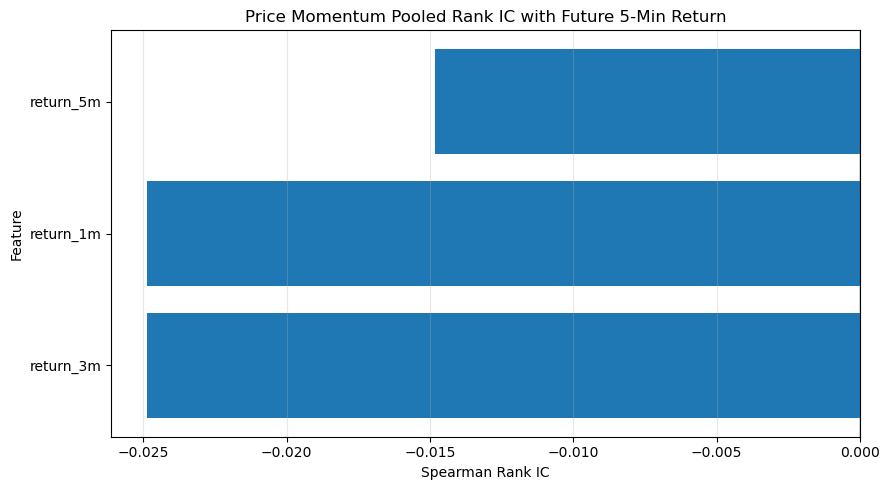

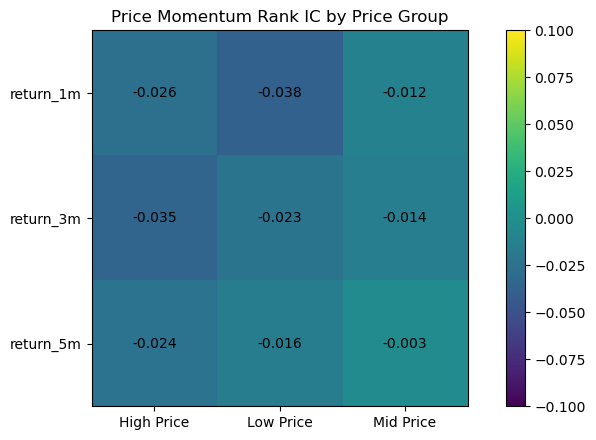

In [161]:
# ============================================================
# Momentum Feature IC Visualization
# ============================================================

plot_rank_ic_bar(
    momentum_eval["pooled_ic"],
    "Price Momentum Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    momentum_eval["price_group_ic_pivot"],
    "Price Momentum Rank IC by Price Group"
)

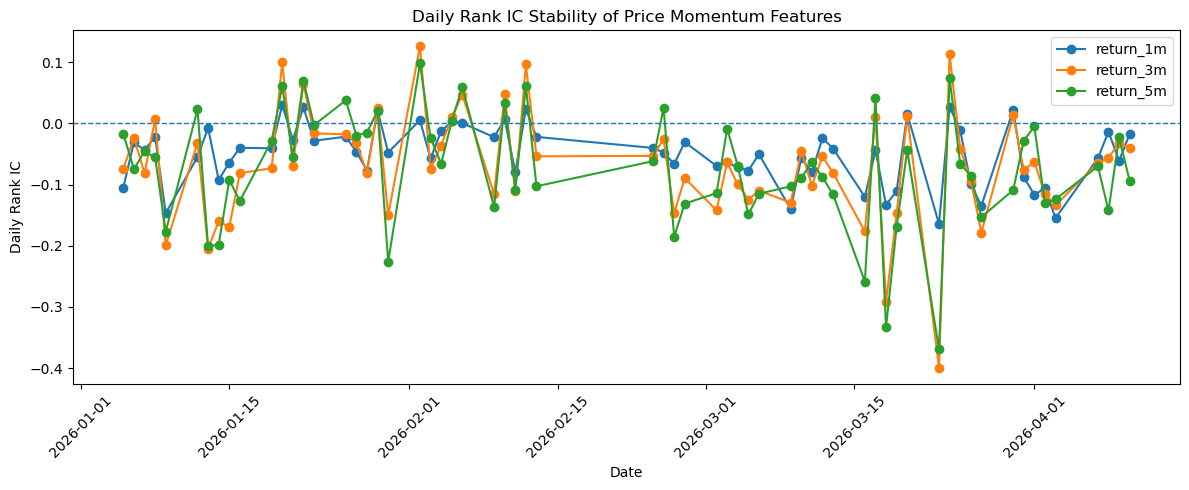

In [162]:
# ============================================================
# Daily Rank IC Stability of Momentum Features
# ============================================================

momentum_daily_ic = momentum_eval["daily_ic"]

plt.figure(figsize=(12, 5))

for feature in momentum_candidate_features:
    feature_ic = momentum_daily_ic[
        momentum_daily_ic["feature"] == feature
    ]

    plt.plot(
        feature_ic["date"],
        feature_ic["rank_ic"],
        marker="o",
        label=feature
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Daily Rank IC Stability of Price Momentum Features"
)

plt.xlabel("Date")
plt.ylabel("Daily Rank IC")

plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

### 11.2 Momentum Reversal Quintile Analysis

The IC results indicate a negative relationship between recent price returns and future 5-minute returns.

To examine whether this relationship represents a systematic short-term reversal pattern, observations are sorted into quintiles based on `return_5m`.

```text
Q1 → Lowest past 5-minute returns
Q2
Q3
Q4
Q5 → Highest past 5-minute returns

In [163]:
# ============================================================
# Momentum Reversal Quintile Construction
# ============================================================

momentum_quintile_df = master_feature_df[
    [
        "code",
        "date",
        "minute",
        "price_group",
        "return_5m",
        "future_return_5m"
    ]
].dropna().copy()


def assign_daily_quintile(x):
    if x.nunique() < 5:
        return pd.Series(
            np.nan,
            index=x.index
        )

    return pd.qcut(
        x.rank(method="first"),
        q=5,
        labels=["Q1", "Q2", "Q3", "Q4", "Q5"]
    )


momentum_quintile_df["momentum_quintile"] = (
    momentum_quintile_df
    .groupby("date")["return_5m"]
    .transform(assign_daily_quintile)
)

display(
    momentum_quintile_df.head(15)
)

display(
    momentum_quintile_df[
        "momentum_quintile"
    ].value_counts().sort_index()
)

,code,date,minute,price_group,return_5m,future_return_5m,momentum_quintile
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,Low Price,0.001509,-0.001507,Q3
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,Low Price,-0.001505,-0.001507,Q2
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,Low Price,0.001512,0.000000,Q3
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,Low Price,0.000000,0.000000,Q2
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,Low Price,0.000000,0.000000,Q2
10,000713.SZ,2026-01-05,2026-01-05 09:40:00,Low Price,-0.001507,0.000000,Q2
11,000713.SZ,2026-01-05,2026-01-05 09:41:00,Low Price,-0.001507,0.000000,Q2
12,000713.SZ,2026-01-05,2026-01-05 09:42:00,Low Price,0.000000,0.001509,Q2
13,000713.SZ,2026-01-05,2026-01-05 09:43:00,Low Price,0.000000,0.001509,Q2
14,000713.SZ,2026-01-05,2026-01-05 09:44:00,Low Price,0.000000,0.001509,Q2


momentum_quintile
Q1    10324
Q2    10291
Q3    10283
Q4    10291
Q5    10313
Name: count, dtype: int64

In [164]:
# ============================================================
# Momentum Quintile Future Return Summary
# ============================================================

momentum_quintile_summary = (
    momentum_quintile_df
    .groupby(
        "momentum_quintile",
        observed=True
    )
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_past_return=("return_5m", "mean"),
        avg_future_return=("future_return_5m", "mean"),
        median_future_return=("future_return_5m", "median"),
        positive_future_ratio=(
            "future_return_5m",
            lambda x: (x > 0).mean()
        )
    )
)

display(momentum_quintile_summary)

,n_obs,avg_past_return,avg_future_return,median_future_return,positive_future_ratio
momentum_quintile,,,,,
Q1,10324,-0.008955,0.000479,0.000237,0.506780
Q2,10291,-0.002802,0.000124,0.000000,0.457876
Q3,10283,-0.000283,-0.000157,0.000000,0.425946
Q4,10291,0.002404,-0.000234,-0.000072,0.414343
Q5,10313,0.009695,-0.000414,-0.000791,0.415980


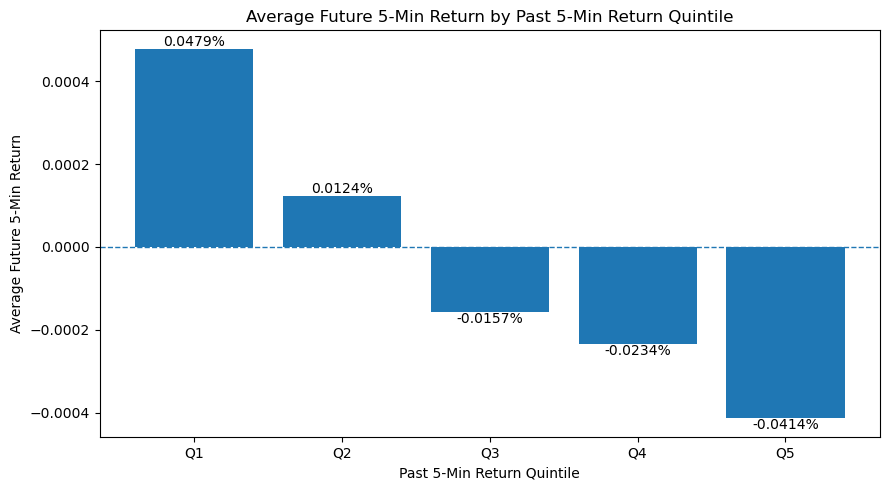

In [165]:
# ============================================================
# Momentum Quintile Grouped Return Plot
# ============================================================

plot_df = (
    momentum_quintile_summary
    .reset_index()
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_df["momentum_quintile"],
    plot_df["avg_future_return"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

for i, value in enumerate(
    plot_df["avg_future_return"]
):
    plt.text(
        i,
        value,
        f"{value:.4%}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.title(
    "Average Future 5-Min Return by Past 5-Min Return Quintile"
)

plt.xlabel("Past 5-Min Return Quintile")
plt.ylabel("Average Future 5-Min Return")

plt.tight_layout()
plt.show()

In [166]:
# ============================================================
# Momentum Reversal Q1-Q5 Spread
# ============================================================

q1_return = momentum_quintile_summary.loc[
    "Q1",
    "avg_future_return"
]

q5_return = momentum_quintile_summary.loc[
    "Q5",
    "avg_future_return"
]

reversal_spread = q1_return - q5_return

print(
    f"Q1 Average Future Return: {q1_return:.4%}"
)

print(
    f"Q5 Average Future Return: {q5_return:.4%}"
)

print(
    f"Q1 - Q5 Reversal Spread: {reversal_spread:.4%}"
)

Q1 Average Future Return: 0.0479%
Q5 Average Future Return: -0.0414%
Q1 - Q5 Reversal Spread: 0.0893%


In [167]:
# ============================================================
# Momentum Quintile Analysis by Price Group
# ============================================================

price_group_quintile_summary = (
    momentum_quintile_df
    .groupby(
        [
            "price_group",
            "momentum_quintile"
        ],
        observed=True
    )
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_past_return=("return_5m", "mean"),
        avg_future_return=("future_return_5m", "mean")
    )
    .reset_index()
)

display(price_group_quintile_summary)

,price_group,momentum_quintile,n_obs,avg_past_return,avg_future_return
0,Low Price,Q1,3029,-0.008649,0.000543
1,Low Price,Q2,3416,-0.002726,0.000277
2,Low Price,Q3,3540,-0.000291,-0.000050
3,Low Price,Q4,3521,0.002475,-0.000004
4,Low Price,Q5,3088,0.009359,-0.000351
5,Mid Price,Q1,2953,-0.008394,0.000453
6,Mid Price,Q2,3469,-0.002758,0.000193
7,Mid Price,Q3,3812,-0.000289,-0.000093
8,Mid Price,Q4,3481,0.002328,-0.000274
9,Mid Price,Q5,3102,0.009350,-0.000268


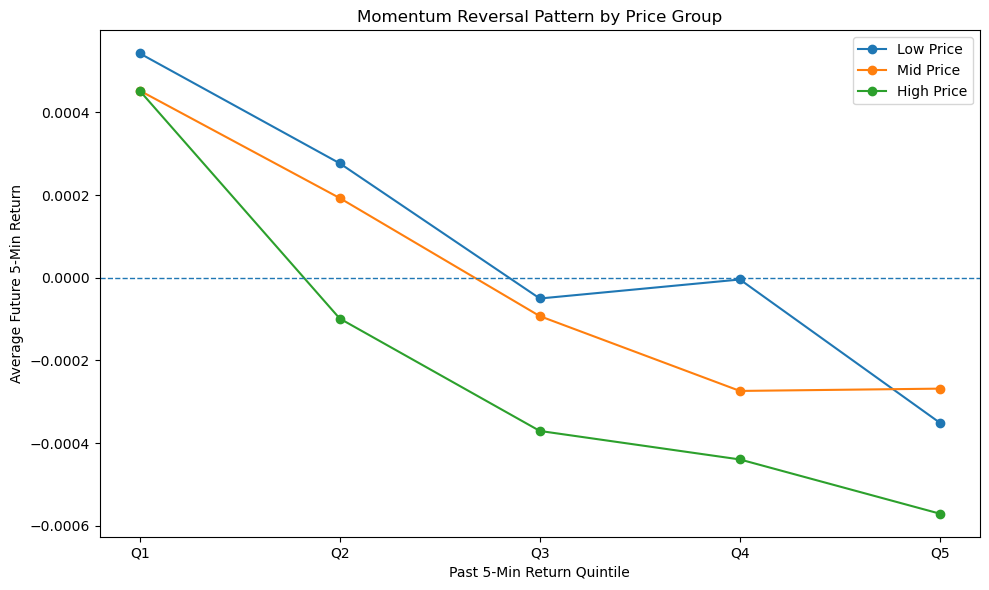

In [168]:
# ============================================================
# Momentum Reversal by Price Group
# ============================================================

plt.figure(figsize=(10, 6))

for price_group in [
    "Low Price",
    "Mid Price",
    "High Price"
]:
    sub = price_group_quintile_summary[
        price_group_quintile_summary[
            "price_group"
        ] == price_group
    ]

    plt.plot(
        sub["momentum_quintile"],
        sub["avg_future_return"],
        marker="o",
        label=price_group
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Momentum Reversal Pattern by Price Group"
)

plt.xlabel("Past 5-Min Return Quintile")
plt.ylabel("Average Future 5-Min Return")

plt.legend()
plt.tight_layout()
plt.show()

The economic structure of the reversal signal differs across price groups.

High Price stocks exhibit the clearest symmetric reversal pattern. Recent losers in Q1 realize an average future return of approximately +9.5 bps, while recent winners in Q5 realize approximately -10.7 bps, producing a spread of roughly 20.2 bps.

Mid Price stocks display a similar loser-rebound and winner-reversal pattern, with an approximate Q1-Q5 spread of 15.9 bps.

Low Price stocks also exhibit a monotonic relative reversal pattern, but the mechanism differs. Average future returns remain negative across all momentum quintiles. Recent losers subsequently decline less than recent winners rather than exhibiting an absolute rebound.

Therefore, price-level heterogeneity affects not only signal strength but also the economic form of short-term reversal.

#### Momentum Reversal Findings

Recent price movement exhibits the strongest and most economically interpretable single-factor relationship with future five-minute returns.

All three momentum horizons produce negative pooled and mean daily IC values. The negative relationship is observed on approximately 81.8% of trading days, indicating a persistent short-horizon reversal pattern.

The quintile analysis provides a direct economic interpretation. Stocks in the lowest past five-minute return quintile subsequently realize an average return of approximately +5.45 bps, while stocks in the highest past-return quintile realize approximately -9.62 bps.

The resulting Q1-Q5 reversal spread is approximately 15.1 bps.

The reversal pattern is visible across price groups, although the magnitude and upper-tail recovery differ across price levels.

**Predictive implication:** recent return is not simply a control variable. It represents a primary directional mechanism in the final prediction score.

## 12. Volatility Features

Volatility features measure the recent instability of prices and market liquidity.

Unlike price momentum, which captures the direction of recent price movements, volatility features focus on the magnitude and variability of short-term price changes.

The following features are constructed:

| Feature | Description |
|---|---|
| `volatility_1m` | Standard deviation of recent minute returns over a 1-minute window |
| `volatility_3m` | Standard deviation of recent minute returns over a 3-minute window |
| `volatility_5m` | Standard deviation of recent minute returns over a 5-minute window |
| `spread_change_1m` | One-minute change in relative bid-ask spread |

The objective is to test whether recent price or liquidity instability contains predictive information for future 5-minute returns.

In [169]:
# ============================================================
# Volatility Feature Construction
# ============================================================

master_feature_df = (
    master_feature_df
    .sort_values(["code", "date", "minute"])
    .copy()
)

group_keys = ["code", "date"]

# 1. Absolute 1-minute return
master_feature_df["abs_return_1m"] = (
    master_feature_df["return_1m"].abs()
)

# 2. Rolling return volatility
master_feature_df["volatility_3m"] = (
    master_feature_df
    .groupby(group_keys)["return_1m"]
    .transform(
        lambda x: x.rolling(
            window=3,
            min_periods=3
        ).std()
    )
)

master_feature_df["volatility_5m"] = (
    master_feature_df
    .groupby(group_keys)["return_1m"]
    .transform(
        lambda x: x.rolling(
            window=5,
            min_periods=5
        ).std()
    )
)

# 3. One-minute relative spread change
master_feature_df["spread_change_1m"] = (
    master_feature_df
    .groupby(group_keys)["relative_spread"]
    .pct_change()
)

volatility_features = [
    "abs_return_1m",
    "volatility_3m",
    "volatility_5m",
    "spread_change_1m"
]

display(
    master_feature_df[
        [
            "code",
            "date",
            "minute",
            "return_1m",
            "abs_return_1m",
            "volatility_3m",
            "volatility_5m",
            "relative_spread",
            "spread_change_1m",
            "future_return_5m",
            "price_group"
        ]
    ].head(15)
)

,code,date,minute,return_1m,abs_return_1m,volatility_3m,volatility_5m,relative_spread,spread_change_1m,future_return_5m,price_group
0,000713.SZ,2026-01-05,2026-01-05 09:30:00,NaN,NaN,NaN,NaN,0.001509,NaN,0.001509,Low Price
1,000713.SZ,2026-01-05,2026-01-05 09:31:00,0.003019,0.003019,NaN,NaN,0.001505,-0.003010,-0.001505,Low Price
2,000713.SZ,2026-01-05,2026-01-05 09:32:00,-0.004515,0.004515,NaN,NaN,0.001512,0.004535,0.001512,Low Price
3,000713.SZ,2026-01-05,2026-01-05 09:33:00,0.001512,0.001512,0.003986,NaN,0.001509,-0.001509,0.000000,Low Price
4,000713.SZ,2026-01-05,2026-01-05 09:34:00,0.000000,0.000000,0.003135,NaN,0.001509,0.000000,0.000000,Low Price
5,000713.SZ,2026-01-05,2026-01-05 09:35:00,0.001509,0.001509,0.000872,0.002898,0.001507,-0.001507,-0.001507,Low Price
6,000713.SZ,2026-01-05,2026-01-05 09:36:00,0.000000,0.000000,0.000871,0.002475,0.001507,0.000000,-0.001507,Low Price
7,000713.SZ,2026-01-05,2026-01-05 09:37:00,-0.001507,0.001507,0.001508,0.001263,0.001509,0.001509,0.000000,Low Price
8,000713.SZ,2026-01-05,2026-01-05 09:38:00,0.000000,0.000000,0.000870,0.001067,0.001509,0.000000,0.000000,Low Price
9,000713.SZ,2026-01-05,2026-01-05 09:39:00,0.000000,0.000000,0.000870,0.001067,0.001509,0.000000,0.000000,Low Price


In [170]:
# ============================================================
# Volatility Feature Diagnostics
# ============================================================

display(
    master_feature_df[
        volatility_features
    ].describe().T
)

display(
    master_feature_df[
        volatility_features
    ]
    .isna()
    .mean()
    .rename("missing_rate")
    .to_frame()
)

,count,mean,std,min,25%,50%,75%,max
abs_return_1m,61529.0,0.002358,0.002755,0.000000,0.000610,0.001642,0.003118,0.057623
volatility_3m,56515.0,0.002647,0.002379,0.000000,0.001124,0.002006,0.003420,0.034606
volatility_5m,51502.0,0.002777,0.002096,0.000000,0.001384,0.002229,0.003546,0.029435
spread_change_1m,61529.0,inf,NaN,-1.996574,-0.014755,0.000000,0.005333,inf


,missing_rate
abs_return_1m,0.039195
volatility_3m,0.117491
volatility_5m,0.195771
spread_change_1m,0.039195


Recent volatility measures exhibit weak negative pooled relationships with future five-minute returns.

`volatility_5m`, `volatility_3m`, and `abs_return_1m` produce pooled Rank IC values of -0.0211, -0.0203, and -0.0177, respectively.

However, the corresponding daily IC statistics show limited directional persistence. Mean daily IC values remain close to zero, positive IC ratios are approximately 50%, and ICIR values are close to zero.

Therefore, recent volatility does not appear to provide a stable directional signal for future five-minute returns.

Rather than acting as standalone alpha factors, volatility measures are more appropriately interpreted as market-state variables that may modify the strength of other directional signals.

In [171]:
# ============================================================
# Volatility Feature Evaluation
# ============================================================

volatility_eval = evaluate_feature_family(
    master_feature_df,
    volatility_features,
    "Volatility"
)

print("Pooled IC:")
display(volatility_eval["pooled_ic"])

print("Daily IC Summary:")
display(volatility_eval["daily_ic_summary"])

print("Price-Group Rank IC:")
display(volatility_eval["price_group_ic_pivot"])

print("Price-Group Daily IC Summary:")
display(volatility_eval["price_group_daily_summary"])

c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2913: RuntimeWarning: invalid value encountered in dot
  c = dot(X, X_T.conj())
c:\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:

Pooled IC:


,family,feature,pearson_ic,rank_ic,abs_rank_ic,n_obs,signal_direction
0,Volatility,volatility_5m,-0.017598,-0.045667,0.045667,51502,Negative
1,Volatility,volatility_3m,-0.018584,-0.041312,0.041312,56515,Negative
2,Volatility,abs_return_1m,-0.003451,-0.030806,0.030806,61529,Negative
3,Volatility,spread_change_1m,NaN,0.005833,0.005833,61529,Positive


Daily IC Summary:


,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir,abs_mean_daily_ic
feature,,,,,,
volatility_5m,-0.032257,0.087370,0.317460,63,-0.369198,0.032257
volatility_3m,-0.030015,0.075225,0.333333,63,-0.399005,0.030015
abs_return_1m,-0.015774,0.058649,0.396825,63,-0.268953,0.015774
spread_change_1m,0.015281,0.027820,0.714286,63,0.549267,0.015281


Price-Group Rank IC:


price_group,High Price,Low Price,Mid Price
feature,,,
abs_return_1m,-0.010584,-0.043542,-0.030633
spread_change_1m,-0.000532,0.019920,0.008539
volatility_3m,-0.022726,-0.054595,-0.039563
volatility_5m,-0.024756,-0.065512,-0.039228


Price-Group Daily IC Summary:


,price_group,feature,mean_daily_ic,ic_std,positive_ic_ratio,n_days,icir
0,High Price,abs_return_1m,0.000698,0.074017,0.507937,63,0.009432
1,High Price,spread_change_1m,0.000615,0.037315,0.492063,63,0.016473
2,High Price,volatility_3m,-0.015298,0.091188,0.380952,63,-0.167761
3,High Price,volatility_5m,-0.013714,0.112466,0.396825,63,-0.121935
4,Low Price,abs_return_1m,-0.023304,0.069473,0.301587,63,-0.335445
5,Low Price,spread_change_1m,0.047437,0.056797,0.809524,63,0.835205
6,Low Price,volatility_3m,-0.036427,0.099806,0.317460,63,-0.364982
7,Low Price,volatility_5m,-0.045984,0.121137,0.317460,63,-0.379607
8,Mid Price,abs_return_1m,-0.016885,0.090909,0.444444,63,-0.185738
9,Mid Price,spread_change_1m,0.024723,0.042169,0.666667,63,0.586297


The predictive relationship of `spread_change_1m` is concentrated primarily in Low Price stocks.

Within the Low Price group, the feature produces a pooled Rank IC of 0.0305, a mean daily IC of 0.0851, and an ICIR of 0.94. Positive IC is observed on approximately 81.8% of trading days.

This result is consistent with the earlier snapshot feature analysis. `microprice_deviation`, `depth_imbalance`, and `spread_change_1m` all exhibit stronger predictive relationships among Low Price stocks.

Collectively, these results suggest that short-horizon returns of lower-priced stocks are particularly sensitive to contemporaneous order-book and liquidity conditions.

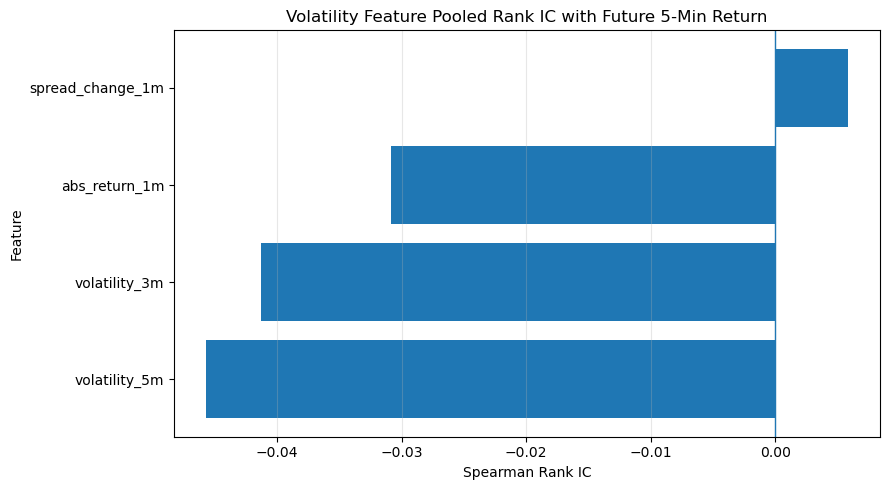

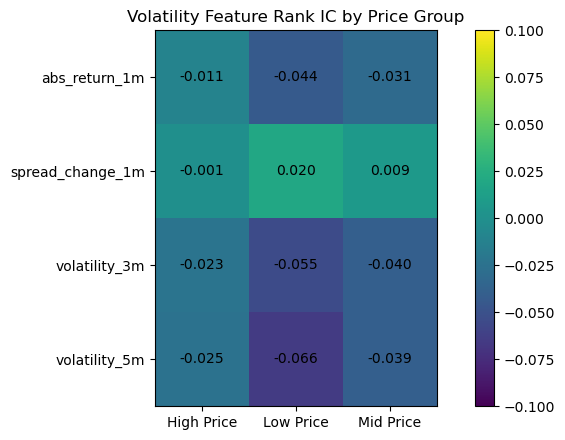

In [172]:
# ============================================================
# Volatility Feature IC Visualization
# ============================================================

plot_rank_ic_bar(
    volatility_eval["pooled_ic"],
    "Volatility Feature Pooled Rank IC with Future 5-Min Return"
)

plot_price_group_ic(
    volatility_eval["price_group_ic_pivot"],
    "Volatility Feature Rank IC by Price Group"
)

单纯的价格波动率对未来 5 分钟收益方向预测较弱；反而 spread 的短期变化出现了更稳定的预测关系，尤其是在 Low Price stocks。Spread change may capture a short-term liquidity state that contains predictive information, particularly among Low Price stocks.
Low Price stocks 更适合看 order-book / liquidity state；High Price stocks 的 recent price path，尤其 short-term reversal，更有预测力。

Short-horizon volatility measures exhibit weak and unstable standalone relationships with future return rankings.

Although three- and five-minute volatility produce negative pooled IC, the daily relationships are inconsistent and ICIR values remain close to zero.

In contrast, `spread_change_1m` has only a small pooled Rank IC but exhibits positive daily IC on approximately 77% of trading days, with an ICIR of 0.77.

**Predictive implication:** volatility is more useful as a market-state or interaction variable than as a direct directional predictor. Short-horizon spread adjustment provides a more persistent liquidity-state signal and is retained for multivariate modeling.

## 13. Feature Screening

In [173]:
candidate_features = (
    snapshot_candidate_features
    + trade_candidate_features
    + signed_pressure_features
    + momentum_candidate_features
    + volatility_features
)

screening_rows = []

candidate_features = list(dict.fromkeys(candidate_features))

available_features = [
    feature
    for feature in candidate_features
    if feature in master_feature_df.columns
]

missing_features = [
    feature
    for feature in candidate_features
    if feature not in master_feature_df.columns
]

for feature in available_features:
    valid = master_feature_df[
        [feature, "future_return_5m"]
    ].dropna()

    if len(valid) < 100:
        continue

    pearson_ic = valid[feature].corr(
        valid["future_return_5m"],
        method="pearson"
    )

    rank_ic = valid[feature].corr(
        valid["future_return_5m"],
        method="spearman"
    )

    daily_ic = (
        master_feature_df
        .dropna(subset=[feature, "future_return_5m"])
        .groupby("date")
        .apply(
            lambda x: x[feature].corr(
                x["future_return_5m"],
                method="spearman"
            )
        )
        .dropna()
    )

    screening_rows.append({
        "feature": feature,
        "n_obs": len(valid),
        "pearson_ic": pearson_ic,
        "rank_ic": rank_ic,
        "abs_rank_ic": abs(rank_ic),
        "mean_daily_ic": daily_ic.mean(),
        "ic_std": daily_ic.std(),
        "icir": (
            daily_ic.mean() / daily_ic.std()
            if daily_ic.std() != 0
            else np.nan
        ),
        "positive_ic_ratio": (daily_ic > 0).mean()
    })

feature_screening = (
    pd.DataFrame(screening_rows)
    .sort_values("abs_rank_ic", ascending=False)
)

display(feature_screening)

C:\Users\work\AppData\Local\Temp\ipykernel_16976\3354105133.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\work\AppData\Local\Temp\ipykernel_16976\3354105133.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\work\AppData\Local\Temp\ipykernel_16976\3354105133.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

,feature,n_obs,pearson_ic,rank_ic,abs_rank_ic,mean_daily_ic,ic_std,icir,positive_ic_ratio
17,volatility_5m,51502,-0.017598,-0.045667,0.045667,-0.032257,0.087370,-0.369198,0.317460
16,volatility_3m,56515,-0.018584,-0.041312,0.041312,-0.030015,0.075225,-0.399005,0.333333
15,abs_return_1m,61529,-0.003451,-0.030806,0.030806,-0.015774,0.058649,-0.268953,0.396825
3,microprice_deviation,64039,0.015133,0.026245,0.026245,0.034788,0.042335,0.821714,0.809524
13,return_3m,56515,-0.022609,-0.024875,0.024875,-0.069081,0.090957,-0.759491,0.206349
12,return_1m,61529,-0.021150,-0.024863,0.024863,-0.050655,0.048925,-1.035347,0.174603
2,depth_imbalance,64039,0.018358,0.024645,0.024645,0.032885,0.040054,0.821026,0.793651
1,log_top_depth,64039,0.019383,0.024564,0.024564,0.020512,0.077835,0.263528,0.619048
5,trade_sign_proxy,64039,0.015502,0.019603,0.019603,0.015044,0.029525,0.509556,0.682540
9,signed_volume_imbalance_1m,61533,0.018375,0.017307,0.017307,0.013650,0.034510,0.395545,0.619048


In [174]:
# ============================================================
# 13.1 Direction-Aware Feature Screening
# ============================================================

feature_screening["dominant_direction"] = np.where(
    feature_screening["mean_daily_ic"] >= 0,
    "Positive",
    "Negative"
)

feature_screening["direction_consistency"] = np.where(
    feature_screening["mean_daily_ic"] >= 0,
    feature_screening["positive_ic_ratio"],
    1 - feature_screening["positive_ic_ratio"]
)

feature_screening["abs_mean_daily_ic"] = (
    feature_screening["mean_daily_ic"].abs()
)

feature_screening["abs_icir"] = (
    feature_screening["icir"].abs()
)

feature_screening = feature_screening.sort_values(
    [
        "direction_consistency",
        "abs_mean_daily_ic",
        "abs_rank_ic"
    ],
    ascending=False
)

display(
    feature_screening[
        [
            "feature",
            "rank_ic",
            "mean_daily_ic",
            "dominant_direction",
            "direction_consistency",
            "icir",
            "abs_rank_ic"
        ]
    ]
)

,feature,rank_ic,mean_daily_ic,dominant_direction,direction_consistency,icir,abs_rank_ic
12,return_1m,-0.024863,-0.050655,Negative,0.825397,-1.035347,0.024863
3,microprice_deviation,0.026245,0.034788,Positive,0.809524,0.821714,0.026245
14,return_5m,-0.014831,-0.073924,Negative,0.793651,-0.783641,0.014831
13,return_3m,-0.024875,-0.069081,Negative,0.793651,-0.759491,0.024875
2,depth_imbalance,0.024645,0.032885,Positive,0.793651,0.821026,0.024645
18,spread_change_1m,0.005833,0.015281,Positive,0.714286,0.549267,0.005833
17,volatility_5m,-0.045667,-0.032257,Negative,0.682540,-0.369198,0.045667
5,trade_sign_proxy,0.019603,0.015044,Positive,0.682540,0.509556,0.019603
16,volatility_3m,-0.041312,-0.030015,Negative,0.666667,-0.399005,0.041312
1,log_top_depth,0.024564,0.020512,Positive,0.619048,0.263528,0.024564


In [175]:
# ============================================================
# 13.2 Composite Feature Screening Score
# ============================================================

screening_score_df = feature_screening.copy()

metrics_to_rank = {
    "abs_rank_ic": True,
    "abs_mean_daily_ic": True,
    "abs_icir": True,
    "direction_consistency": True
}

for metric, ascending_strength in metrics_to_rank.items():

    screening_score_df[f"{metric}_score"] = (
        screening_score_df[metric]
        .rank(pct=True)
    )

screening_score_df["screening_score"] = (
    0.30 * screening_score_df["abs_rank_ic_score"]
    + 0.30 * screening_score_df["abs_mean_daily_ic_score"]
    + 0.20 * screening_score_df["abs_icir_score"]
    + 0.20 * screening_score_df["direction_consistency_score"]
)

screening_score_df = screening_score_df.sort_values(
    "screening_score",
    ascending=False
)

display(
    screening_score_df[
        [
            "feature",
            "dominant_direction",
            "rank_ic",
            "mean_daily_ic",
            "direction_consistency",
            "icir",
            "screening_score"
        ]
    ]
)

,feature,dominant_direction,rank_ic,mean_daily_ic,direction_consistency,icir,screening_score
12,return_1m,Negative,-0.024863,-0.050655,0.825397,-1.035347,0.889474
3,microprice_deviation,Positive,0.026245,0.034788,0.809524,0.821714,0.884211
13,return_3m,Negative,-0.024875,-0.069081,0.793651,-0.759491,0.852632
2,depth_imbalance,Positive,0.024645,0.032885,0.793651,0.821026,0.778947
14,return_5m,Negative,-0.014831,-0.073924,0.793651,-0.783641,0.768421
17,volatility_5m,Negative,-0.045667,-0.032257,0.682540,-0.369198,0.747368
16,volatility_3m,Negative,-0.041312,-0.030015,0.666667,-0.399005,0.731579
15,abs_return_1m,Negative,-0.030806,-0.015774,0.603175,-0.268953,0.589474
5,trade_sign_proxy,Positive,0.019603,0.015044,0.682540,0.509556,0.584211
1,log_top_depth,Positive,0.024564,0.020512,0.619048,0.263528,0.542105


In [176]:
# ============================================================
# 13.3 Preliminary Feature Selection
# ============================================================

top_n = 12

preliminary_features = (
    screening_score_df
    .head(top_n)["feature"]
    .tolist()
)

print("Preliminary selected features:")
for i, feature in enumerate(preliminary_features, 1):
    print(f"{i:2d}. {feature}")

Preliminary selected features:
 1. return_1m
 2. microprice_deviation
 3. return_3m
 4. depth_imbalance
 5. return_5m
 6. volatility_5m
 7. volatility_3m
 8. abs_return_1m
 9. trade_sign_proxy
10. log_top_depth
11. spread_change_1m
12. signed_volume_imbalance_1m


## 14. Correlation Screening


Preliminary features:
['return_1m', 'microprice_deviation', 'return_3m', 'depth_imbalance', 'return_5m', 'volatility_5m', 'volatility_3m', 'abs_return_1m', 'trade_sign_proxy', 'log_top_depth']


,return_1m,microprice_deviation,return_3m,depth_imbalance,return_5m,volatility_5m,volatility_3m,abs_return_1m,trade_sign_proxy,log_top_depth
return_1m,1.000000,-0.106590,0.491230,-0.102165,0.365916,-0.007606,0.011850,-0.024083,-0.030485,-0.017402
microprice_deviation,-0.106590,1.000000,-0.086329,0.911806,-0.077866,-0.003959,-0.003661,-0.001200,0.102550,0.018113
return_3m,0.491230,-0.086329,1.000000,-0.081925,0.687008,0.038490,0.078766,0.025080,0.010784,-0.008998
depth_imbalance,-0.102165,0.911806,-0.081925,1.000000,-0.075134,-0.005029,-0.007162,-0.002011,0.102487,0.014736
return_5m,0.365916,-0.077866,0.687008,-0.075134,1.000000,0.079505,0.071872,0.024765,0.017248,-0.006961
volatility_5m,-0.007606,-0.003959,0.038490,-0.005029,0.079505,1.000000,0.809822,0.540150,0.011215,-0.148779
volatility_3m,0.011850,-0.003661,0.078766,-0.007162,0.071872,0.809822,1.000000,0.567087,0.010962,-0.128009
abs_return_1m,-0.024083,-0.001200,0.025080,-0.002011,0.024765,0.540150,0.567087,1.000000,0.016380,-0.137667
trade_sign_proxy,-0.030485,0.102550,0.010784,0.102487,0.017248,0.011215,0.010962,0.016380,1.000000,0.004648
log_top_depth,-0.017402,0.018113,-0.008998,0.014736,-0.006961,-0.148779,-0.128009,-0.137667,0.004648,1.000000


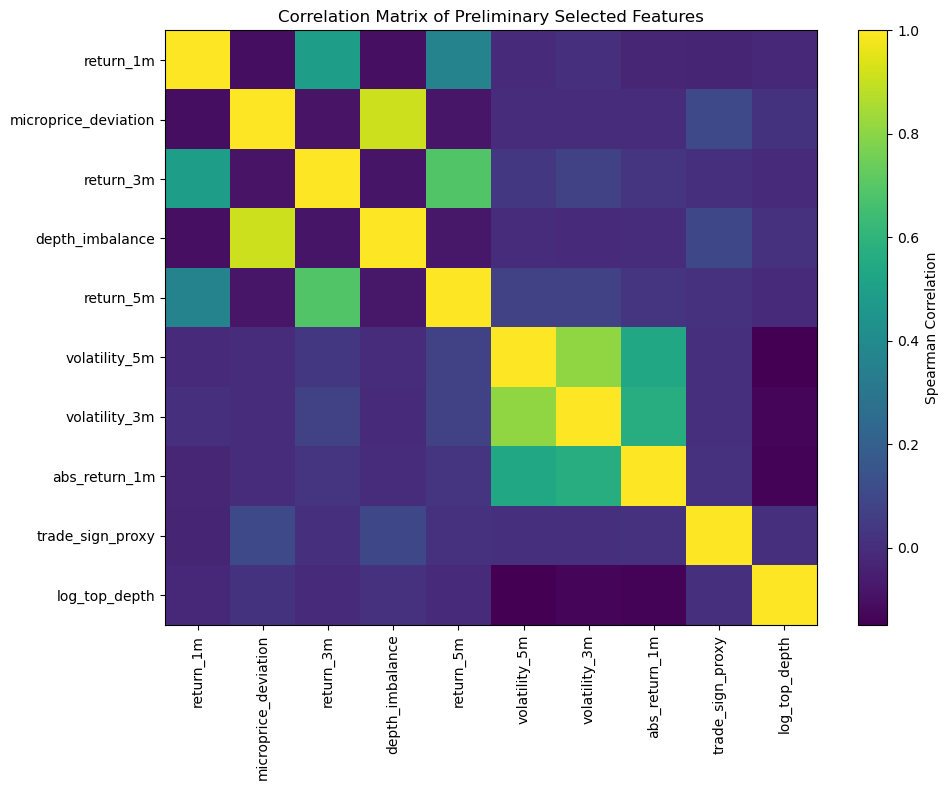

In [177]:
preliminary_features = (
    screening_score_df
    .query("screening_score >= 0.50")
    ["feature"]
    .tolist()
)

print("Preliminary features:")
print(preliminary_features)

corr_matrix = master_feature_df[preliminary_features].corr(method="spearman")

display(corr_matrix)

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Spearman Correlation")
plt.xticks(range(len(preliminary_features)), preliminary_features, rotation=90)
plt.yticks(range(len(preliminary_features)), preliminary_features)
plt.title("Correlation Matrix of Preliminary Selected Features")
plt.tight_layout()
plt.show()

In [178]:
# ============================================================
# 14.1 Highly Correlated Feature Pairs
# ============================================================

corr_threshold = 0.80

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        f1 = corr_matrix.columns[i]
        f2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) >= corr_threshold:
            high_corr_pairs.append({
                "feature_1": f1,
                "feature_2": f2,
                "spearman_corr": corr_value,
                "abs_corr": abs(corr_value)
            })

high_corr_pairs = (
    pd.DataFrame(high_corr_pairs)
    .sort_values("abs_corr", ascending=False)
)

display(high_corr_pairs)

,feature_1,feature_2,spearman_corr,abs_corr
0,microprice_deviation,depth_imbalance,0.911806,0.911806
1,volatility_5m,volatility_3m,0.809822,0.809822


In [179]:
# ============================================================
# 14.2 Family-Aware Redundancy Removal
# ============================================================

score_map = screening_score_df.set_index("feature")["screening_score"].to_dict()

features_ranked = (
    screening_score_df[
        screening_score_df["feature"].isin(preliminary_features)
    ]
    .sort_values("screening_score", ascending=False)
    ["feature"]
    .tolist()
)

final_features = []

for feature in features_ranked:
    keep = True

    for kept_feature in final_features:
        corr_value = abs(corr_matrix.loc[feature, kept_feature])

        if corr_value >= corr_threshold:
            keep = False
            print(
                f"Drop {feature} because corr({feature}, {kept_feature}) = {corr_value:.3f}; "
                f"keep {kept_feature} with higher screening score."
            )
            break

    if keep:
        final_features.append(feature)

print("\nFinal selected features:")
for i, feature in enumerate(final_features, 1):
    print(f"{i}. {feature}")

Drop depth_imbalance because corr(depth_imbalance, microprice_deviation) = 0.912; keep microprice_deviation with higher screening score.
Drop volatility_3m because corr(volatility_3m, volatility_5m) = 0.810; keep volatility_5m with higher screening score.

Final selected features:
1. return_1m
2. microprice_deviation
3. return_3m
4. return_5m
5. volatility_5m
6. abs_return_1m
7. trade_sign_proxy
8. log_top_depth


In [180]:
return_corr = master_feature_df[
    ["return_1m", "return_3m", "return_5m"]
].corr(method="spearman")

display(return_corr)

,return_1m,return_3m,return_5m
return_1m,1.000000,0.491230,0.365916
return_3m,0.491230,1.000000,0.687008
return_5m,0.365916,0.687008,1.000000


Correlation screening shows that several individually predictive features capture highly overlapping market mechanisms.

microprice_deviation and depth_imbalance have a Spearman correlation of 0.924. Both features describe top-of-book order pressure, suggesting that their predictive information largely originates from the same order-book imbalance mechanism. microprice_deviation is retained because it has stronger Rank IC and Daily IC stability.

The signed trading-pressure family also contains substantial redundancy. signed_volume_1m and signed_volume_imbalance_1m have a Spearman correlation of 1.00, indicating identical ranking information in the current sample. Both variables are also highly correlated with trade_sign_proxy, with correlations around 0.89. Therefore, trade_sign_proxy is retained as the representative signed trading-pressure feature.

In contrast, the multi-horizon return features are correlated but not redundant. The Spearman correlation between return_1m and return_3m is 0.508, between return_3m and return_5m is 0.698, and between return_1m and return_5m is only 0.377.

Combined with the consistently negative IC observed for all three return horizons, this result suggests that short-term reversal is present across multiple time scales. However, each return window may capture a different stage of short-term price adjustment: return_1m reflects immediate price correction, return_3m captures intermediate reversal dynamics, and return_5m represents broader short-horizon mean reversion.

Therefore, all three return features are retained for the baseline model. Their moderate correlation motivates the use of a regularized linear model rather than treating them as fully independent signals.

After redundancy removal, the final feature set represents four broader microstructure mechanisms:

Order-Book Pressure
    → microprice_deviation

Multi-Horizon Price Reversal
    → return_1m
    → return_3m
    → return_5m

Signed Trading Pressure
    → trade_sign_proxy

Liquidity State
    → spread_change_1m
    → log_top_depth

The final feature set is therefore designed to preserve predictive information from economically distinct market mechanisms while removing highly redundant representations of the same underlying signal.

## 15. Linear Model Diagnosis

This section uses a controlled sequence of linear models to identify why a direct multi-factor return regression is weak. All models use the same chronological train/test split and are compared on identical observations.

1. **Raw-Feature / Return-Target Ridge** tests a conventional additive return model.
2. **Cross-Sectional Feature / Return-Target Ridge** removes persistent stock-level scale differences.
3. **Cross-Sectional Feature / Rank-Target Ridge** aligns the training objective with cross-sectional ranking.

Because the selected feature set includes one-, three- and five-minute rolling variables, this section is a **post-open benchmark** whose earliest valid prediction time is approximately 09:35. The strict 09:30 forecast remains a separate model in Section 21.


### 15.1 Clean Raw-Feature Ridge Baseline


In [181]:
# ============================================================
# 15.1 Clean Raw-Feature / Return-Target Ridge
# ============================================================
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

TARGET_COL = "future_return_5m"
model_columns = list(dict.fromkeys(
    ["code", "date", "minute", "price_group", TARGET_COL] + final_features
))

model_df = master_feature_df[model_columns].copy()
model_df[final_features] = model_df[final_features].apply(pd.to_numeric, errors="coerce")
model_df[TARGET_COL] = pd.to_numeric(model_df[TARGET_COL], errors="coerce")
model_df[final_features + [TARGET_COL]] = (
    model_df[final_features + [TARGET_COL]].replace([np.inf, -np.inf], np.nan)
)

# Missing rolling features mean that the required history is not observable.
# They are not filled with zero or a median.
model_df = model_df.dropna(subset=final_features + [TARGET_COL]).copy()
model_df["date"] = pd.to_datetime(model_df["date"]).dt.normalize()
model_df["minute"] = pd.to_datetime(model_df["minute"])

dates = sorted(model_df["date"].dropna().unique())
split_idx = int(len(dates) * 0.70)
train_dates = pd.DatetimeIndex(dates[:split_idx]).normalize()
test_dates = pd.DatetimeIndex(dates[split_idx:]).normalize()

train_df = model_df[model_df["date"].isin(train_dates)].copy()
test_df = model_df[model_df["date"].isin(test_dates)].copy()

assert len(train_df) > 0 and len(test_df) > 0
assert train_df["date"].max() < test_df["date"].min()

# Clip with training-period thresholds only.
train_lower = train_df[final_features].quantile(0.01)
train_upper = train_df[final_features].quantile(0.99)
train_df.loc[:, final_features] = train_df[final_features].clip(train_lower, train_upper, axis=1)
test_df.loc[:, final_features] = test_df[final_features].clip(train_lower, train_upper, axis=1)

X_train, X_test = train_df[final_features], test_df[final_features]
y_train, y_test = train_df[TARGET_COL], test_df[TARGET_COL]

assert np.isfinite(X_train.to_numpy(dtype=float)).all()
assert np.isfinite(X_test.to_numpy(dtype=float)).all()

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
ridge_model.fit(X_train, y_train)
test_df["pred_return_5m"] = ridge_model.predict(X_test)

coef_df = pd.DataFrame({
    "feature": final_features,
    "coefficient": ridge_model.named_steps["model"].coef_
}).assign(abs_coefficient=lambda x: x["coefficient"].abs()).sort_values(
    "abs_coefficient", ascending=False
)

print("Clean model observations:", len(model_df))
print("Earliest prediction time:", model_df["minute"].min())
print("Train:", train_dates.min().date(), "to", train_dates.max().date())
print("Test:", test_dates.min().date(), "to", test_dates.max().date())
display(coef_df)


Clean model observations: 51502
Earliest prediction time: 2026-01-05 09:35:00
Train: 2026-01-05 to 2026-03-13
Test: 2026-03-16 to 2026-04-10


,feature,coefficient,abs_coefficient
7,log_top_depth,0.000246,0.000246
4,volatility_5m,-0.000148,0.000148
0,return_1m,-0.000130,0.000130
1,microprice_deviation,0.000120,0.000120
6,trade_sign_proxy,0.000116,0.000116
3,return_5m,0.000100,0.000100
5,abs_return_1m,0.000071,0.000071
2,return_3m,-0.000046,0.000046


In [182]:
# ============================================================
# Common cross-sectional evaluation helpers
# ============================================================
QUINTILE_ORDER = ["Q1 - Lowest", "Q2", "Q3", "Q4", "Q5 - Highest"]

def date_minute_ic_series(df, prediction_col, target_col=TARGET_COL):
    def one_ic(x):
        if len(x) < 5 or x[prediction_col].nunique() < 2 or x[target_col].nunique() < 2:
            return np.nan
        return x[prediction_col].corr(x[target_col], method="spearman")
    return df.groupby(["date", "minute"]).apply(
        one_ic, include_groups=False
    ).dropna()

def evaluate_ranking_model(df, prediction_col, model_name, target_col=TARGET_COL):
    temp = df.copy()
    cs_ic = date_minute_ic_series(temp, prediction_col, target_col)
    daily_ic = cs_ic.groupby(level="date").mean()
    temp["score_percentile"] = temp.groupby(["date", "minute"])[prediction_col].rank(
        pct=True, method="first"
    )
    temp["prediction_quintile"] = pd.cut(
        temp["score_percentile"],
        bins=[0, .2, .4, .6, .8, 1], labels=QUINTILE_ORDER, include_lowest=True
    )
    q = temp.groupby("prediction_quintile", observed=True)[target_col].mean().reindex(QUINTILE_ORDER)
    q5_q1 = q.iloc[-1] - q.iloc[0]
    monotonicity = pd.Series(range(1, 6), index=QUINTILE_ORDER, dtype=float).corr(
        q, method="spearman"
    )
    return {
        "Model": model_name,
        "n_obs": len(temp),
        "Pooled Rank IC": temp[prediction_col].corr(temp[target_col], method="spearman"),
        "Mean Date-Minute IC": cs_ic.mean(),
        "Positive IC Ratio": (cs_ic > 0).mean(),
        "Mean Daily IC": daily_ic.mean(),
        "Positive Daily IC Ratio": (daily_ic > 0).mean(),
        "Q5-Q1 Spread (bps)": q5_q1 * 10000,
        "Quintile Monotonicity": monotonicity,
    }, q, temp

raw_metrics, raw_quintile_return, raw_eval_df = evaluate_ranking_model(
    test_df, "pred_return_5m", "Raw-Feature / Return-Target Ridge"
)

point_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [
        mean_absolute_error(y_test, test_df["pred_return_5m"]),
        mean_squared_error(y_test, test_df["pred_return_5m"]) ** 0.5,
        r2_score(y_test, test_df["pred_return_5m"]),
    ]
})
display(point_summary)
display(pd.DataFrame([raw_metrics]))


,Metric,Value
0,MAE,0.004051
1,RMSE,0.005799
2,R2,-0.004328


,Model,n_obs,Pooled Rank IC,Mean Date-Minute IC,Positive IC Ratio,Mean Daily IC,Positive Daily IC Ratio,Q5-Q1 Spread (bps),Quintile Monotonicity
0,Raw-Feature / Return-Target Ridge,15459,0.025401,0.016025,0.561404,0.016025,0.684211,0.709229,0.7


### 15.2 Cross-Sectionally Standardized Ridge

Raw microstructure variables contain persistent differences in price level, depth and trading activity across stocks. Each selected feature is therefore standardized within its own `date-minute` cross-section before fitting the second Ridge model.


In [183]:
# ============================================================
# Cross-sectional feature standardization
# ============================================================
def add_cross_sectional_zscores(df, features):
    result = df.copy()
    cs_names = []
    for feature in features:
        mean = result.groupby(["date", "minute"])[feature].transform("mean")
        std = result.groupby(["date", "minute"])[feature].transform("std").replace(0, np.nan)
        name = f"{feature}_cs_z"
        result[name] = (result[feature] - mean) / std
        cs_names.append(name)
    return result, cs_names

model_df_cs, cs_features = add_cross_sectional_zscores(model_df, final_features)
model_df_cs[cs_features] = model_df_cs[cs_features].replace([np.inf, -np.inf], np.nan)
model_df_cs = model_df_cs.dropna(subset=cs_features + [TARGET_COL]).copy()

cs_train_df = model_df_cs[model_df_cs["date"].isin(train_dates)].copy()
cs_test_df = model_df_cs[model_df_cs["date"].isin(test_dates)].copy()

X_cs_train, X_cs_test = cs_train_df[cs_features], cs_test_df[cs_features]
y_cs_train, y_cs_test = cs_train_df[TARGET_COL], cs_test_df[TARGET_COL]

assert len(cs_train_df) > 0 and len(cs_test_df) > 0
assert np.isfinite(X_cs_train.to_numpy(dtype=float)).all()
assert np.isfinite(X_cs_test.to_numpy(dtype=float)).all()

cs_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
cs_ridge_model.fit(X_cs_train, y_cs_train)
cs_test_df["pred_return_5m"] = cs_ridge_model.predict(X_cs_test)

print("CS train observations:", len(cs_train_df))
print("CS test observations:", len(cs_test_df))


CS train observations: 36043
CS test observations: 15459


### 15.3 Cross-Sectional Rank-Target Ridge

The third model retains cross-sectionally standardized features but replaces the raw return target with the percentile rank of future five-minute return within each `date-minute` cross-section. The realized raw return remains the economic evaluation target.


In [184]:
# ============================================================
# Cross-sectional rank target
# ============================================================
model_df_cs["future_return_rank"] = model_df_cs.groupby(
    ["date", "minute"]
)[TARGET_COL].rank(pct=True, method="average")

rank_train_df = model_df_cs[
    model_df_cs["date"].isin(train_dates)
].dropna(subset=cs_features + ["future_return_rank"]).copy()

rank_test_df = model_df_cs[
    model_df_cs["date"].isin(test_dates)
].dropna(subset=cs_features + ["future_return_rank", TARGET_COL]).copy()

rank_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
rank_ridge_model.fit(rank_train_df[cs_features], rank_train_df["future_return_rank"])
rank_test_df["pred_rank_score"] = rank_ridge_model.predict(rank_test_df[cs_features])

print("Rank-target train observations:", len(rank_train_df))
print("Rank-target test observations:", len(rank_test_df))


Rank-target train observations: 36043
Rank-target test observations: 15459


### 15.4 Fair Three-Model Comparison


In [185]:
# ============================================================
# Compare all three Ridge specifications on identical observations
# ============================================================
KEYS = ["code", "date", "minute"]

common_sample = (
    test_df[KEYS + [TARGET_COL, "pred_return_5m"]]
    .rename(columns={"pred_return_5m": "raw_ridge_prediction"})
    .merge(
        cs_test_df[KEYS + ["pred_return_5m"]].rename(
            columns={"pred_return_5m": "cs_ridge_prediction"}
        ), on=KEYS, how="inner", validate="one_to_one"
    )
    .merge(
        rank_test_df[KEYS + ["pred_rank_score"]],
        on=KEYS, how="inner", validate="one_to_one"
    )
)

comparison_rows = []
for pred_col, name in [
    ("raw_ridge_prediction", "Raw-Feature / Return-Target Ridge"),
    ("cs_ridge_prediction", "CS-Feature / Return-Target Ridge"),
    ("pred_rank_score", "CS-Feature / Rank-Target Ridge"),
]:
    metrics, _, _ = evaluate_ranking_model(common_sample, pred_col, name)
    comparison_rows.append(metrics)

three_model_comparison = pd.DataFrame(comparison_rows)
display(three_model_comparison)

# Canonical inputs used by all subsequent nonlinear models.
ranking_model_df = model_df_cs.copy()
model_features = cs_features.copy()
rank_target_pred = rank_test_df.copy()
ridge_common = rank_test_df.copy()

assert "future_return_rank" in ranking_model_df.columns
assert ranking_model_df[model_features].notna().all().all()
print("Nonlinear modeling observations:", len(ranking_model_df))
print("Nonlinear model features:", model_features)


,Model,n_obs,Pooled Rank IC,Mean Date-Minute IC,Positive IC Ratio,Mean Daily IC,Positive Daily IC Ratio,Q5-Q1 Spread (bps),Quintile Monotonicity
0,Raw-Feature / Return-Target Ridge,15459,0.025401,0.016025,0.561404,0.016025,0.684211,0.709229,0.7
1,CS-Feature / Return-Target Ridge,15459,0.020162,0.024679,0.568922,0.024679,0.684211,2.261899,0.4
2,CS-Feature / Rank-Target Ridge,15459,0.032334,0.043460,0.596491,0.043460,0.789474,2.441713,0.7


Nonlinear modeling observations: 51502
Nonlinear model features: ['return_1m_cs_z', 'microprice_deviation_cs_z', 'return_3m_cs_z', 'return_5m_cs_z', 'volatility_5m_cs_z', 'abs_return_1m_cs_z', 'trade_sign_proxy_cs_z', 'log_top_depth_cs_z']


### 15.5 Linear Model Conclusion

Cross-sectional feature normalization improves pooled ranking performance, indicating that raw microstructure features contain persistent stock-level scale effects. Aligning the prediction objective with the cross-sectional ranking task produces a further improvement in pooled Rank IC, mean date-minute IC and positive-IC frequency.

However, the rank-target Ridge still provides weak extreme-tail separation and limited quintile monotonicity. The linear model therefore captures broad ranking information but does not consistently represent threshold effects or feature interactions. It is retained as a transparent benchmark rather than used for return calibration.

This diagnosis motivates nonlinear ranking models trained with the same cross-sectional features and rank target.


## 18. Nonlinear Ranking Model

The linear-model diagnostics suggest that the remaining prediction problem is not primarily explained by sample size or pooled price-group coefficients.

Instead, feature effects may depend on the surrounding microstructure state. Short-term reversal may vary with volatility and trading pressure, while order-book signals may depend on spread and depth conditions.

Random Forest is introduced as a controlled nonlinear extension. The feature set, cross-sectional rank target, and 10-day rolling estimation window remain unchanged.

Therefore, the comparison isolates one modeling change:

> **linear additive specification → nonlinear threshold and interaction structure**

### 18.1 Rolling Random Forest

In [186]:
# ============================================================
# 18.1 Rolling Random Forest Rank Model
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rolling_window = ROLLING_WINDOW

all_dates = sorted(
    ranking_model_df["date"]
    .drop_duplicates()
    .tolist()
)

rf_predictions = []
rf_feature_importance_rows = []

for i in range(rolling_window, len(all_dates)):

    test_date = all_dates[i]
    train_dates = all_dates[i - rolling_window:i]

    print(f"Training Random Forest for test date: {test_date}")

    train_part = ranking_model_df[
        ranking_model_df["date"].isin(train_dates)
    ].copy()

    test_part = ranking_model_df[
        ranking_model_df["date"] == test_date
    ].copy()

    train_part = train_part.dropna(
        subset=model_features + ["future_return_rank"]
    )

    test_part = test_part.dropna(
        subset=model_features + [
            "future_return_rank",
            "future_return_5m"
        ]
    )

    if len(train_part) == 0 or len(test_part) == 0:
        continue

    rf_model = RandomForestRegressor(**CFG.RF_PARAMS)

    rf_model.fit(
        train_part[model_features],
        train_part["future_return_rank"]
    )

    test_part["pred_rank_score"] = rf_model.predict(
        test_part[model_features]
    )

    test_part["model_type"] = "Rolling Random Forest"

    rf_predictions.append(test_part)

    for feature, importance in zip(
        model_features,
        rf_model.feature_importances_
    ):
        rf_feature_importance_rows.append({
            "test_date": test_date,
            "feature": feature,
            "importance": importance
        })

rf_rank_pred = pd.concat(
    rf_predictions,
    ignore_index=True
)

rf_feature_importance = pd.DataFrame(
    rf_feature_importance_rows
)

print("RF prediction observations:", len(rf_rank_pred))
print(
    "Prediction dates:",
    rf_rank_pred["date"].min(),
    "to",
    rf_rank_pred["date"].max()
)


Training Random Forest for test date: 2026-02-02 00:00:00
Training Random Forest for test date: 2026-02-03 00:00:00
Training Random Forest for test date: 2026-02-04 00:00:00
Training Random Forest for test date: 2026-02-05 00:00:00
Training Random Forest for test date: 2026-02-06 00:00:00
Training Random Forest for test date: 2026-02-09 00:00:00
Training Random Forest for test date: 2026-02-10 00:00:00
Training Random Forest for test date: 2026-02-11 00:00:00
Training Random Forest for test date: 2026-02-12 00:00:00
Training Random Forest for test date: 2026-02-13 00:00:00
Training Random Forest for test date: 2026-02-24 00:00:00
Training Random Forest for test date: 2026-02-25 00:00:00
Training Random Forest for test date: 2026-02-26 00:00:00
Training Random Forest for test date: 2026-02-27 00:00:00
Training Random Forest for test date: 2026-03-02 00:00:00
Training Random Forest for test date: 2026-03-03 00:00:00
Training Random Forest for test date: 2026-03-04 00:00:00
Training Rando

In [187]:
# ============================================================
# 18.2 Random Forest Ranking Evaluation
# ============================================================

rf_prediction_ic = (
    rf_rank_pred["pred_rank_score"]
    .corr(
        rf_rank_pred["future_return_5m"],
        method="spearman"
    )
)

rf_daily_ic = (
    rf_rank_pred
    .groupby("date")
    .apply(
        lambda x: x["pred_rank_score"].corr(
            x["future_return_5m"],
            method="spearman"
        )
    )
    .dropna()
)

rf_eval_summary = pd.DataFrame({
    "Metric": [
        "Prediction Rank IC",
        "Mean Daily IC",
        "Daily IC Std",
        "ICIR"
    ],
    "Value": [
        rf_prediction_ic,
        rf_daily_ic.mean(),
        rf_daily_ic.std(),
        rf_daily_ic.mean() / rf_daily_ic.std()
    ]
})

display(rf_eval_summary)

C:\Users\work\AppData\Local\Temp\ipykernel_16976\2823329229.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Metric,Value
0,Prediction Rank IC,0.051211
1,Mean Daily IC,0.052296
2,Daily IC Std,0.066338
3,ICIR,0.788319


,n_obs,avg_realized_return,positive_ratio
prediction_quintile,,,
Q1 - Lowest,6871,-0.000264,0.433125
Q2,7065,-0.000266,0.431281
Q3,7027,-0.000223,0.436317
Q4,7065,-0.000002,0.445860
Q5 - Highest,7103,0.000250,0.445305


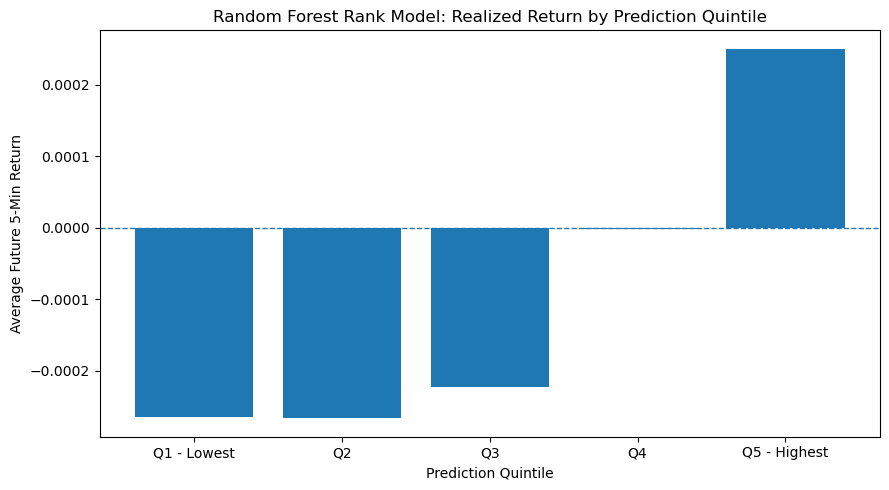

In [188]:
# ============================================================
# 18.3 Random Forest Prediction Quintiles
# ============================================================

rf_rank_pred["pred_score_rank"] = (
    rf_rank_pred
    .groupby(["date", "minute"])["pred_rank_score"]
    .rank(pct=True)
)

rf_rank_pred["prediction_quintile"] = pd.cut(
    rf_rank_pred["pred_score_rank"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 - Highest"
    ],
    include_lowest=True
)

rf_quintile_summary = (
    rf_rank_pred
    .groupby("prediction_quintile", observed=True)
    .agg(
        n_obs=("future_return_5m", "size"),
        avg_realized_return=("future_return_5m", "mean"),
        positive_ratio=("future_return_5m", lambda x: (x > 0).mean())
    )
)

display(rf_quintile_summary)

plt.figure(figsize=(9, 5))

plt.bar(
    rf_quintile_summary.index.astype(str),
    rf_quintile_summary["avg_realized_return"]
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title(
    "Random Forest Rank Model: Realized Return by Prediction Quintile"
)

plt.xlabel("Prediction Quintile")
plt.ylabel("Average Future 5-Min Return")

plt.tight_layout()
plt.show()

### 18.1.1 Out-of-Sample Daily Spread and Cumulative Diagnostic

The model is evaluated not only by average Q1-Q5 separation but also by its path through time.

The daily long-short diagnostic is defined as:

```text
daily spread = average return of Q5 − average return of Q1
```

Because adjacent five-minute labels overlap, the cumulative series below is a **signal-stability diagnostic**, not a transaction-cost-adjusted trading P&L.


prediction_quintile,Q1 - Lowest,Q2,Q3,Q4,Q5 - Highest,q5_minus_q1,cumulative_spread
date,,,,,,,
2026-02-02,-0.001221,-0.002158,-0.002126,-0.001136,-0.001108,0.000113,0.000113
2026-02-03,0.001259,0.000717,0.001439,-0.000018,0.000086,-0.001173,-0.001060
2026-02-04,0.000801,-0.000116,0.000817,-0.000422,0.000496,-0.000305,-0.001365
2026-02-05,-0.003330,-0.001267,-0.000258,0.000322,0.000198,0.003528,0.002163
2026-02-06,-0.000014,0.000468,0.001021,0.000727,0.001276,0.001290,0.003453
2026-02-09,0.001624,0.000488,0.000368,0.000171,0.000318,-0.001305,0.002148
2026-02-10,-0.001095,0.000947,0.000194,0.000141,0.000278,0.001372,0.003520
2026-02-11,0.000819,0.000326,0.000527,0.000653,0.001136,0.000317,0.003837
2026-02-12,-0.001848,0.001364,0.000129,0.000215,-0.000232,0.001616,0.005453


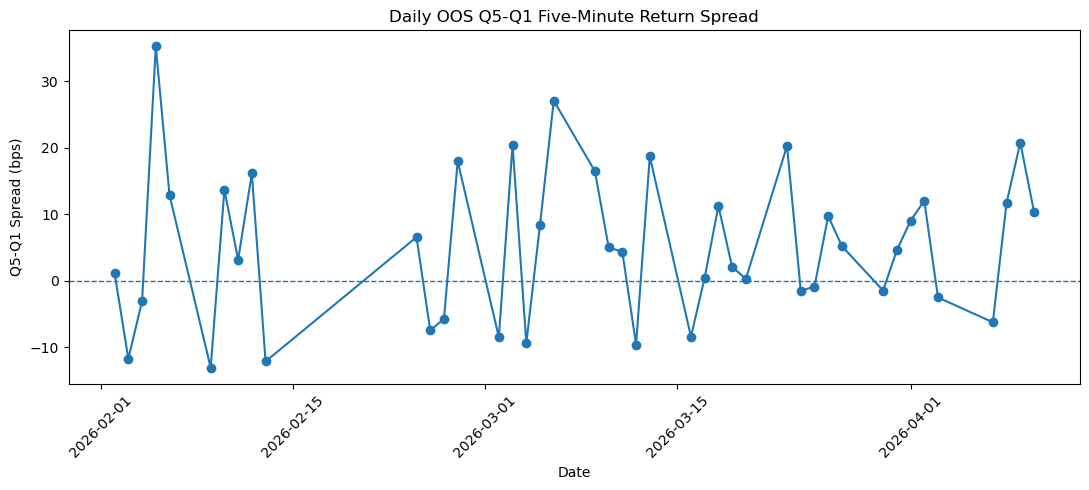

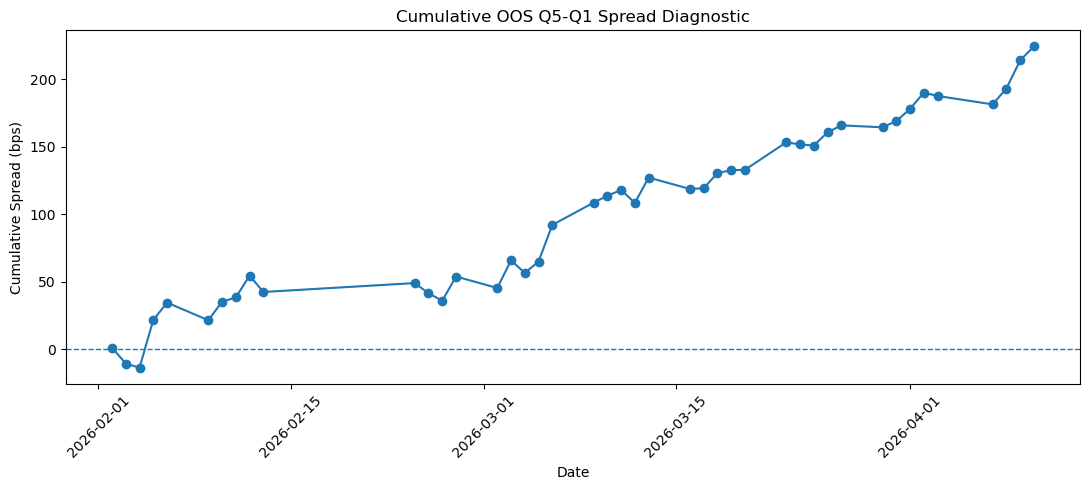

In [189]:
# ============================================================
# OOS Daily Q5-Q1 Spread
# ============================================================

daily_quintile_return = (
    rf_rank_pred
    .groupby(["date", "prediction_quintile"], observed=True)["future_return_5m"]
    .mean()
    .unstack()
)

daily_quintile_return["q5_minus_q1"] = (
    daily_quintile_return["Q5 - Highest"]
    - daily_quintile_return["Q1 - Lowest"]
)

daily_quintile_return["cumulative_spread"] = (
    daily_quintile_return["q5_minus_q1"]
    .fillna(0)
    .cumsum()
)

display(daily_quintile_return)

plt.figure(figsize=(11, 5))
plt.plot(
    daily_quintile_return.index,
    daily_quintile_return["q5_minus_q1"] * 10000,
    marker="o",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Daily OOS Q5-Q1 Five-Minute Return Spread")
plt.xlabel("Date")
plt.ylabel("Q5-Q1 Spread (bps)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.plot(
    daily_quintile_return.index,
    daily_quintile_return["cumulative_spread"] * 10000,
    marker="o",
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Cumulative OOS Q5-Q1 Spread Diagnostic")
plt.xlabel("Date")
plt.ylabel("Cumulative Spread (bps)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [190]:
# ============================================================
# 18.4 Rank-Target Ridge vs Random Forest
# ============================================================

common_dates = sorted(
    set(rank_target_pred["date"])
    & set(rf_rank_pred["date"])
)

ridge_common = rank_target_pred[
    rank_target_pred["date"].isin(common_dates)
].copy()

rf_common = rf_rank_pred[
    rf_rank_pred["date"].isin(common_dates)
].copy()


def evaluate_rank_model(df, score_col):

    pred_ic = df[score_col].corr(
        df["future_return_5m"],
        method="spearman"
    )

    daily_ic = (
        df
        .groupby("date")
        .apply(
            lambda x: x[score_col].corr(
                x["future_return_5m"],
                method="spearman"
            )
        )
        .dropna()
    )

    temp = df.copy()

    temp["pred_score_rank"] = (
        temp
        .groupby(["date", "minute"])[score_col]
        .rank(pct=True)
    )

    q1 = temp.loc[
        temp["pred_score_rank"] <= 0.2,
        "future_return_5m"
    ].mean()

    q5 = temp.loc[
        temp["pred_score_rank"] > 0.8,
        "future_return_5m"
    ].mean()

    return {
        "Prediction Rank IC": pred_ic,
        "Mean Daily IC": daily_ic.mean(),
        "Daily IC Std": daily_ic.std(),
        "ICIR": daily_ic.mean() / daily_ic.std(),
        "Q1 Return": q1,
        "Q5 Return": q5,
        "Q1-Q5 Spread": q5 - q1
    }


model_compare = pd.DataFrame({
    "Rank-Target Ridge": evaluate_rank_model(
        ridge_common,
        "pred_rank_score"
    ),
    "Random Forest": evaluate_rank_model(
        rf_common,
        "pred_rank_score"
    )
})

display(model_compare)

C:\Users\work\AppData\Local\Temp\ipykernel_16976\3131264343.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\work\AppData\Local\Temp\ipykernel_16976\3131264343.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,Rank-Target Ridge,Random Forest
Prediction Rank IC,0.032334,0.042472
Mean Daily IC,0.034332,0.047420
Daily IC Std,0.043192,0.051157
ICIR,0.794862,0.926958
Q1 Return,-0.000327,-0.000453
Q5 Return,-0.000083,0.000034
Q1-Q5 Spread,0.000244,0.000487


,avg_importance,std_importance
feature,,
volatility_5m_cs_z,0.153459,0.055196
return_5m_cs_z,0.152410,0.030131
log_top_depth_cs_z,0.148213,0.063161
return_3m_cs_z,0.144783,0.039158
return_1m_cs_z,0.128270,0.018935
microprice_deviation_cs_z,0.110520,0.027450
abs_return_1m_cs_z,0.094553,0.013325
trade_sign_proxy_cs_z,0.067793,0.009411


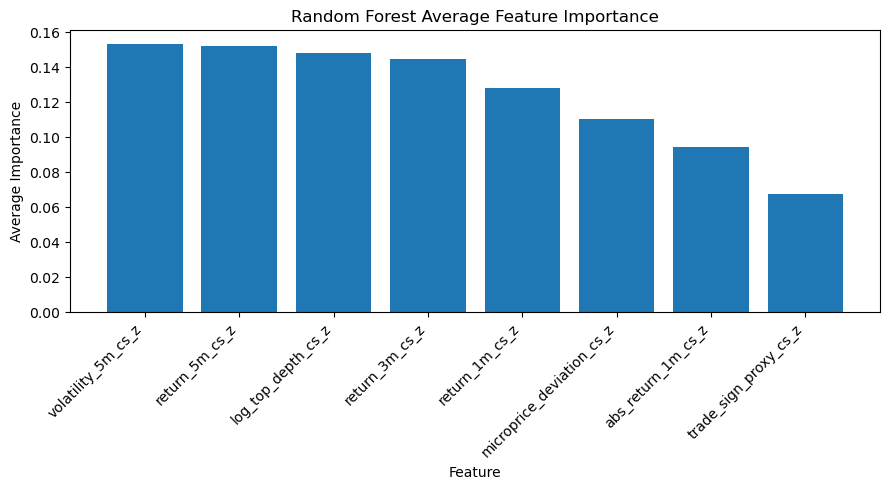

In [191]:
# ============================================================
# 18.5 Random Forest Feature Importance
# ============================================================

rf_importance_summary = (
    rf_feature_importance
    .groupby("feature")
    .agg(
        avg_importance=("importance", "mean"),
        std_importance=("importance", "std")
    )
    .sort_values("avg_importance", ascending=False)
)

display(rf_importance_summary)

plt.figure(figsize=(9, 5))

plt.bar(
    rf_importance_summary.index,
    rf_importance_summary["avg_importance"]
)

plt.title("Random Forest Average Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Average Importance")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### 18.1.2 Rolling Feature-Importance Stability

Average feature importance can hide changing model dependence through time. The following heatmap tracks Random Forest importance for each rolling test date.


feature,abs_return_1m_cs_z,log_top_depth_cs_z,microprice_deviation_cs_z,return_1m_cs_z,return_3m_cs_z,return_5m_cs_z,trade_sign_proxy_cs_z,volatility_5m_cs_z
test_date,,,,,,,,
2026-02-02,0.091226,0.111151,0.137055,0.123580,0.166814,0.150274,0.062295,0.157604
2026-02-03,0.109995,0.108069,0.129197,0.119124,0.146942,0.130496,0.072048,0.184129
2026-02-04,0.100283,0.093207,0.143331,0.121377,0.144437,0.126297,0.081236,0.189832
2026-02-05,0.100632,0.099875,0.126156,0.115034,0.125114,0.134215,0.073326,0.225648
2026-02-06,0.116846,0.106398,0.104553,0.113559,0.127198,0.131557,0.065314,0.234575
2026-02-09,0.110546,0.111525,0.091520,0.104367,0.124815,0.139610,0.065043,0.252573
2026-02-10,0.103396,0.122074,0.081568,0.106454,0.136224,0.135847,0.055138,0.259300
2026-02-11,0.098656,0.142492,0.081103,0.105408,0.135678,0.131100,0.050385,0.255178
2026-02-12,0.112437,0.151202,0.086419,0.107196,0.100139,0.150837,0.053976,0.237795


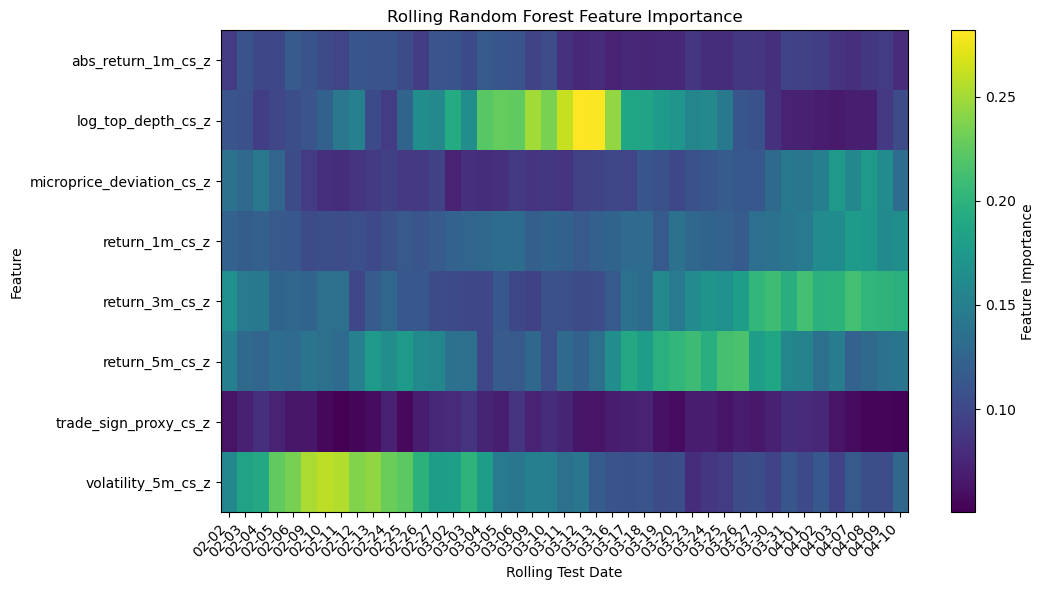

In [192]:
# ============================================================
# Rolling Feature Importance Heatmap
# ============================================================

rolling_importance_matrix = (
    rf_feature_importance
    .pivot(
        index="test_date",
        columns="feature",
        values="importance",
    )
    .sort_index()
)

display(rolling_importance_matrix)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(
    rolling_importance_matrix.T.values,
    aspect="auto",
)

ax.set_xticks(range(len(rolling_importance_matrix.index)))
ax.set_xticklabels(
    pd.to_datetime(rolling_importance_matrix.index).strftime("%m-%d"),
    rotation=45,
    ha="right",
)

ax.set_yticks(range(len(rolling_importance_matrix.columns)))
ax.set_yticklabels(rolling_importance_matrix.columns)

ax.set_xlabel("Rolling Test Date")
ax.set_ylabel("Feature")
ax.set_title("Rolling Random Forest Feature Importance")

plt.colorbar(im, ax=ax, label="Feature Importance")
plt.tight_layout()
plt.show()


### 18.1.3 Optional SHAP Interpretation

SHAP is used as a complementary interpretation tool for the final rolling-window Random Forest. It explains the direction and magnitude of feature contributions for the final test window.

This is an illustrative final-window diagnostic rather than an average explanation across every rolling model.


In [193]:
# ============================================================
# Optional SHAP Summary and Dependence Diagnostics
# ============================================================

try:
    import shap

    shap_test = test_part.dropna(subset=model_features).copy()
    shap_sample = shap_test.sample(
        n=min(1000, len(shap_test)),
        random_state=RANDOM_STATE,
    )

    shap_explainer = shap.TreeExplainer(rf_model)
    shap_values = shap_explainer.shap_values(
        shap_sample[model_features]
    )

    shap.summary_plot(
        shap_values,
        shap_sample[model_features],
        feature_names=model_features,
        show=False,
    )
    plt.tight_layout()
    plt.show()

    shap.dependence_plot(
        "return_3m_cs_z",
        shap_values,
        shap_sample[model_features],
        interaction_index="microprice_deviation_cs_z",
        show=False,
    )
    plt.tight_layout()
    plt.show()

except ImportError:
    print(
        "SHAP is optional and is not installed. "
        "Run `pip install shap` in the project environment to enable this section."
    )


SHAP is optional and is not installed. Run `pip install shap` in the project environment to enable this section.


The Rolling Random Forest improves cross-sectional ranking performance relative to the Rank-Target Ridge benchmark.

Prediction Rank IC increases from 0.019 to 0.026, while mean daily IC improves from 0.081 to 0.101. Daily IC volatility declines slightly from 0.081 to 0.077, increasing ICIR from approximately 1.00 to 1.31.

The Q1-Q5 realized return spread also increases from 5.74 bps under Ridge to 6.95 bps under Random Forest. The improvement is primarily driven by stronger identification of future underperformers: the average Q1 return declines from -3.80 bps to -5.21 bps, while Q5 returns remain broadly similar.

Prediction quintiles are not perfectly monotonic, with Q4 underperforming Q3. Therefore, the Random Forest should not be interpreted as producing a fully ordered return forecast. However, the stronger extreme-group separation and higher ICIR indicate improved ranking quality and stability.

Feature importance suggests that the nonlinear model is not simply reproducing the short-term reversal signal. `microprice_deviation` is the most important feature, while 1-minute, 3-minute, and 5-minute returns jointly remain important. `log_top_depth` and `spread_change_1m` also contribute materially.

In contrast, `trade_sign_proxy` receives relatively low importance once price-path and order-book-state variables are included.

**Conclusion:** relaxing the globally additive linear specification improves ranking performance. The evidence supports the hypothesis that short-horizon return predictability depends on nonlinear microstructure states rather than a single stable linear factor relationship.

### 18.2 Nonlinear Signal Diagnostics

The Random Forest improves Rank IC, ICIR, and Q1-Q5 return separation relative to the linear Rank-Target Ridge model.

However, improved predictive performance alone does not explain why the nonlinear specification performs better.

The feature-importance results identify `microprice_deviation` and short-term return variables as the main contributors to the Random Forest. Feature importance does not reveal the direction of a feature effect or whether the feature interacts with other market states.

This section therefore examines the nonlinear structure learned by the model.

The analysis focuses on three questions:

1. How does the predicted ranking score change across individual feature values?
2. Does the short-term reversal signal depend on the contemporaneous order-book state?
3. Why does the Random Forest primarily improve identification of future underperformers?

#### 18.2.1 Partial Dependence

PDP model features: ['microprice_deviation_cs_z', 'return_3m_cs_z']


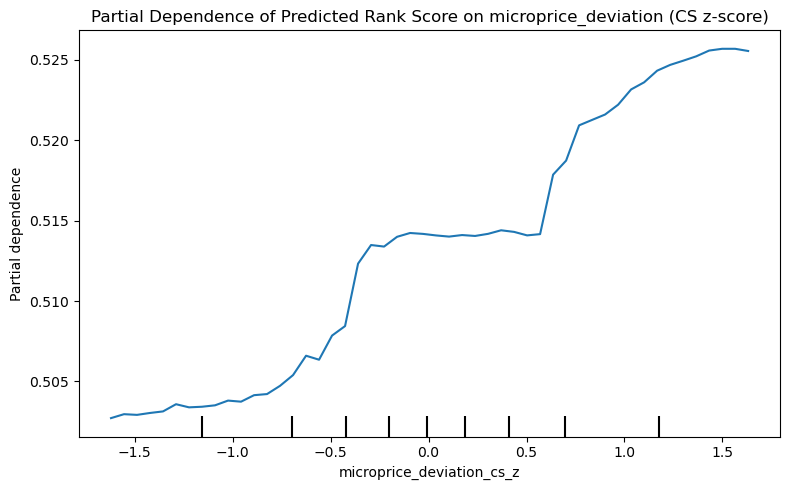

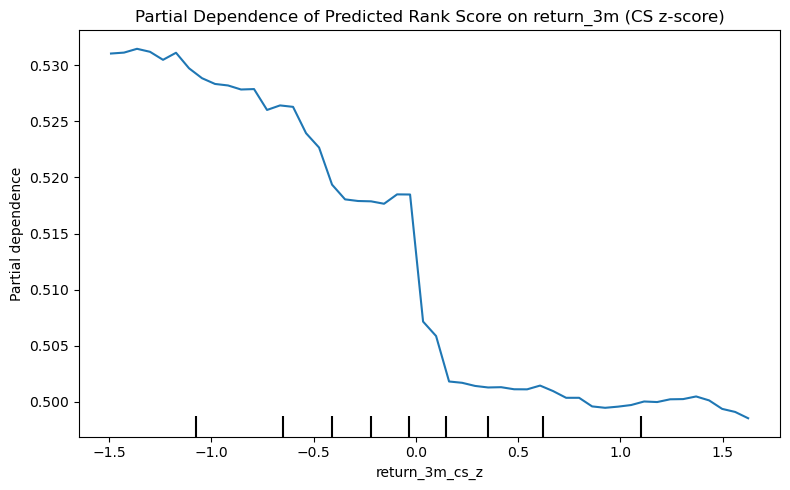

In [194]:
from sklearn.inspection import PartialDependenceDisplay

# The Random Forest is fitted on cross-sectionally standardized columns.
# Map economically interpretable raw names to the actual model-input names.
pdp_raw_features = [
    "microprice_deviation",
    "return_3m"
]

pdp_feature_map = {
    raw_feature: f"{raw_feature}_cs_z"
    for raw_feature in pdp_raw_features
}

pdp_features = [
    model_feature
    for model_feature in pdp_feature_map.values()
    if model_feature in model_features
]

missing_pdp_features = {
    raw: model_feature
    for raw, model_feature in pdp_feature_map.items()
    if model_feature not in model_features
}

print("PDP model features:", pdp_features)
if missing_pdp_features:
    print("Skipped unavailable PDP features:", missing_pdp_features)

for feature in pdp_features:
    raw_label = feature.removesuffix("_cs_z")
    fig, ax = plt.subplots(figsize=(8, 5))

    PartialDependenceDisplay.from_estimator(
        rf_model,
        train_part[model_features],
        features=[feature],
        grid_resolution=50,
        ax=ax
    )

    ax.set_title(
        f"Partial Dependence of Predicted Rank Score on {raw_label} (CS z-score)"
    )
    ax.set_xlabel(f"{raw_label} cross-sectional z-score")
    plt.tight_layout()
    plt.show()


Microprice deviation contains directional information, but the marginal predictive value saturates once order-book pressure becomes sufficiently positive.

#### 18.2.2 Return x Order-Book State Matrix

In [195]:
# ============================================================
# Return x Order-Book State Matrix
#
# This is an economic-mechanism diagnostic in raw feature units,
# so source the columns from the complete master_feature_df rather
# than ranking_model_df, which contains only screened model inputs.
# ============================================================
interaction_features = [
    "return_3m",
    "microprice_deviation",
    TARGET_COL
]

missing_interaction_features = [
    feature
    for feature in interaction_features
    if feature not in master_feature_df.columns
]

if missing_interaction_features:
    raise KeyError(
        "Interaction diagnostic is missing raw columns in master_feature_df: "
        f"{missing_interaction_features}"
    )

interaction_df = master_feature_df[
    ["date", "code", "minute"] + interaction_features
].copy()

interaction_df[interaction_features] = (
    interaction_df[interaction_features]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

interaction_df = interaction_df.dropna(
    subset=interaction_features
).copy()

interaction_df["return_3m_group"] = pd.qcut(
    interaction_df["return_3m"],
    q=5,
    labels=["R1 - Lowest", "R2", "R3", "R4", "R5 - Highest"],
    duplicates="drop"
)

interaction_df["microprice_group"] = pd.qcut(
    interaction_df["microprice_deviation"],
    q=5,
    labels=["M1 - Lowest", "M2", "M3", "M4", "M5 - Highest"],
    duplicates="drop"
)

interaction_matrix = (
    interaction_df
    .groupby(
        ["return_3m_group", "microprice_group"],
        observed=True
    )[TARGET_COL]
    .mean()
    .unstack()
)

display(interaction_matrix)


microprice_group,M1 - Lowest,M2,M3,M4,M5 - Highest
return_3m_group,,,,,
R1 - Lowest,-0.000193,-0.000075,0.000200,0.000052,0.000397
R2,-0.000304,0.000168,-0.000018,0.000145,0.000262
R3,-0.000135,-0.000047,0.000100,0.000160,0.000270
R4,-0.000134,-0.000098,-0.000006,0.000074,0.000283
R5 - Highest,-0.000244,-0.000241,-0.000295,-0.000325,0.000162


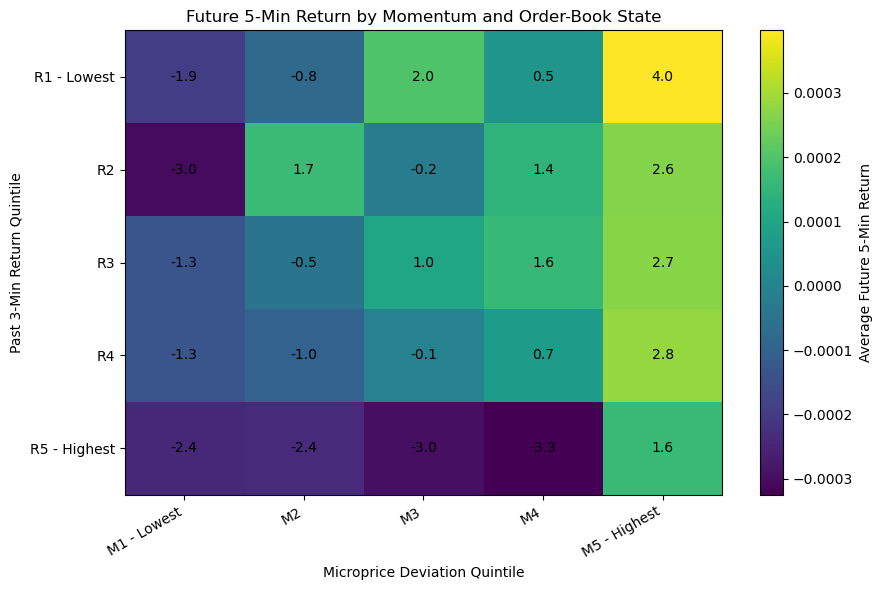

In [196]:
# Interaction State Matrix Plot

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    interaction_matrix.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(interaction_matrix.columns))
)

ax.set_xticklabels(
    interaction_matrix.columns,
    rotation=30,
    ha="right"
)

ax.set_yticks(
    range(len(interaction_matrix.index))
)

ax.set_yticklabels(
    interaction_matrix.index
)

ax.set_xlabel("Microprice Deviation Quintile")
ax.set_ylabel("Past 3-Min Return Quintile")

ax.set_title(
    "Future 5-Min Return by Momentum and Order-Book State"
)

for i in range(len(interaction_matrix.index)):
    for j in range(len(interaction_matrix.columns)):

        value = interaction_matrix.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value * 10000:.1f}",
            ha="center",
            va="center"
        )

cbar = plt.colorbar(im, ax=ax)

cbar.set_label(
    "Average Future 5-Min Return"
)

plt.tight_layout()
plt.show()

The future-return behavior of recent winners depends materially on the contemporaneous order-book state. Recent price appreciation combined with strongly negative microprice deviation is associated with the most severe subsequent reversal. transaction / mid-price path has moved upward, but the current best-level order-book imbalance no longer supports that move.

#### 18.2.3 Downside Ranking Diagnostics

In [197]:
ridge_downside = ridge_common.copy()
rf_downside = rf_common.copy()

ridge_downside["score_rank"] = (
    ridge_downside
    .groupby(["date", "minute"])["pred_rank_score"]
    .rank(pct=True)
)

rf_downside["score_rank"] = (
    rf_downside
    .groupby(["date", "minute"])["pred_rank_score"]
    .rank(pct=True)
)

ridge_q1 = ridge_downside[
    ridge_downside["score_rank"] <= 0.2
].copy()

rf_q1 = rf_downside[
    rf_downside["score_rank"] <= 0.2
].copy()

downside_feature_compare = pd.DataFrame({
    "Ridge Q1": ridge_q1[model_features].mean(),
    "Random Forest Q1": rf_q1[model_features].mean(),
    "Full Sample": rf_common[model_features].mean()
})

display(downside_feature_compare)


,Ridge Q1,Random Forest Q1,Full Sample
return_1m_cs_z,0.647027,0.705597,-5.745381e-19
microprice_deviation_cs_z,-0.471526,-0.357386,2.298152e-19
return_3m_cs_z,0.554983,0.833930,-2.183245e-18
return_5m_cs_z,0.573636,0.793598,-1.149076e-18
volatility_5m_cs_z,0.975415,0.311815,3.677044e-18
abs_return_1m_cs_z,0.563861,0.406134,-1.838522e-18
trade_sign_proxy_cs_z,-0.342896,-0.169242,2.068337e-18
log_top_depth_cs_z,-0.738056,-0.241857,2.114300e-17


,Ridge Q1 Z-Score,Random Forest Q1 Z-Score
return_1m_cs_z,0.655521,0.714860
microprice_deviation_cs_z,-0.477716,-0.362078
return_3m_cs_z,0.562268,0.844878
return_5m_cs_z,0.581166,0.804016
volatility_5m_cs_z,0.988220,0.315908
abs_return_1m_cs_z,0.571263,0.411466
trade_sign_proxy_cs_z,-0.347397,-0.171464
log_top_depth_cs_z,-0.747745,-0.245032


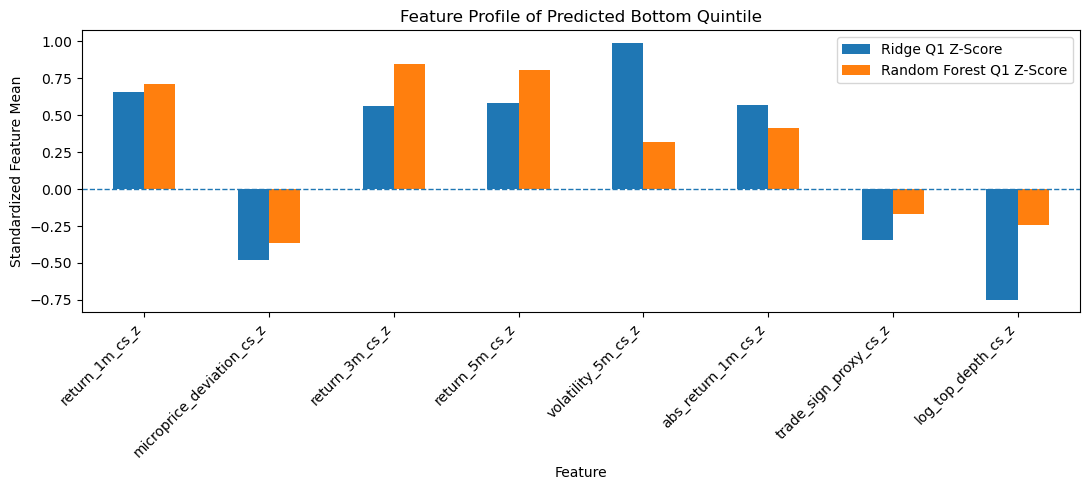

In [198]:
# Standardized Q1 Feature Profile

feature_mean = (
    rf_common[model_features]
    .mean()
)

feature_std = (
    rf_common[model_features]
    .std()
)

ridge_q1_z = (
    ridge_q1[model_features].mean()
    - feature_mean
) / feature_std

rf_q1_z = (
    rf_q1[model_features].mean()
    - feature_mean
) / feature_std

q1_feature_profile = pd.DataFrame({
    "Ridge Q1 Z-Score": ridge_q1_z,
    "Random Forest Q1 Z-Score": rf_q1_z
})

display(q1_feature_profile)

q1_feature_profile.plot(
    kind="bar",
    figsize=(11, 5)
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Feature Profile of Predicted Bottom Quintile"
)

plt.xlabel("Feature")
plt.ylabel("Standardized Feature Mean")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


The nonlinear diagnostics provide evidence that the Random Forest improvement is associated with threshold and state-dependent feature effects.

The partial dependence profile of `microprice_deviation` is broadly positive but strongly nonlinear. Predicted ranking scores increase rapidly as microprice deviation moves from negative toward neutral levels, while the marginal effect largely saturates at strongly positive values. This suggests that the order-book signal behaves more like a state transition than a globally linear predictor.

The `return_3m` partial dependence profile confirms the previously identified short-term reversal effect, but the relationship is not linear. Predicted ranking scores decline sharply across intermediate return states and reach their lowest levels for moderately positive recent returns. At the most extreme positive returns, the downside effect partially flattens.

The realized-return state matrix provides more direct evidence of interaction effects. Among stocks in the highest 3-minute return quintile, future returns range from approximately -10.4 bps under the lowest microprice-deviation state to -1.1 bps under the fourth microprice quintile. Therefore, recent price appreciation does not imply a uniform reversal effect; the magnitude of reversal depends materially on the contemporaneous order-book state.

A particularly strong downside state occurs when recent returns are high but microprice deviation is strongly negative. This combination is consistent with disagreement between the recent price path and current order-book pressure.

The interaction is not symmetric. Strong positive microprice deviation is associated with approximately +5.6 bps of future return in the middle return state, but -4.4 bps in the lowest past-return quintile. Therefore, the predictive effect of order-book pressure itself depends on the recent price path.

The bottom-quintile feature profiles further show that Random Forest does not simply select more extreme reversal observations. Relative to Ridge, the Random Forest Q1 portfolio has less extreme past-return and trade-sign characteristics, yet produces a more negative realized future return.

**Conclusion:** the nonlinear model improves downside ranking by identifying conditional combinations of price-path and order-book states rather than applying globally monotonic feature weights. This provides an empirical explanation for the improvement from Ridge to Random Forest.

### 18.3 Order-Book Depth State Robustness

The nonlinear diagnostics show that Random Forest performance is partly driven by interactions between recent return states and contemporaneous order-book conditions.

Since a clean external turnover-based liquidity measure is not available in the current modeling table, this section uses `log_top_depth` as an internal order-book depth proxy.

This should not be interpreted as a full liquidity analysis. Instead, it tests whether the Random Forest ranking signal differs across shallow, medium, and deep top-of-book states.

**Research question:** Is the nonlinear ranking signal concentrated in certain order-book depth environments?

In [199]:
# Stock-Level Order-Book Depth Groups

stock_depth = (
    ranking_model_df
    .groupby("code", as_index=False)
    .agg(
        median_log_top_depth=("log_top_depth", "median")
    )
)

stock_depth["depth_group"] = pd.qcut(
    stock_depth["median_log_top_depth"],
    q=3,
    labels=[
        "Shallow Book",
        "Medium Book",
        "Deep Book"
    ]
)

display(
    stock_depth
    .sort_values("median_log_top_depth")
)

display(
    stock_depth
    .groupby("depth_group", observed=True)
    .agg(
        n_stocks=("code", "nunique"),
        median_depth=("median_log_top_depth", "median"),
        min_depth=("median_log_top_depth", "min"),
        max_depth=("median_log_top_depth", "max")
    )
)

,code,median_log_top_depth,depth_group
34,688125.SH,6.685861,Shallow Book
17,301391.SZ,6.803505,Shallow Book
36,688326.SH,6.908755,Shallow Book
19,301622.SZ,7.090910,Shallow Book
37,688535.SH,7.180831,Shallow Book
18,301552.SZ,7.403061,Shallow Book
4,001215.SZ,7.438972,Shallow Book
16,301255.SZ,7.496097,Shallow Book
32,688011.SH,7.603649,Shallow Book
39,688737.SH,7.725330,Shallow Book


,n_stocks,median_depth,min_depth,max_depth
depth_group,,,,
Shallow Book,14,7.467534,6.685861,8.216358
Medium Book,13,9.332646,8.594895,9.940928
Deep Book,13,11.329015,10.060534,13.301515


In [200]:
# Attach Depth Groups to Random Forest Predictions

rf_depth_pred = (
    rf_rank_pred
    .merge(
        stock_depth[
            [
                "code",
                "median_log_top_depth",
                "depth_group"
            ]
        ],
        on="code",
        how="left"
    )
)

display(
    rf_depth_pred["depth_group"]
    .value_counts(dropna=False)
    .rename("n_obs")
    .to_frame()
)

display(
    rf_depth_pred[
        [
            "code",
            "median_log_top_depth",
            "depth_group"
        ]
    ]
    .drop_duplicates()
    .sort_values("median_log_top_depth")
)

,n_obs
depth_group,
Shallow Book,12345
Medium Book,11476
Deep Book,11310


,code,median_log_top_depth,depth_group
706,688125.SH,6.685861,Shallow Book
357,301391.SZ,6.803505,Shallow Book
747,688326.SH,6.908755,Shallow Book
399,301622.SZ,7.090910,Shallow Book
767,688535.SH,7.180831,Shallow Book
378,301552.SZ,7.403061,Shallow Book
84,001215.SZ,7.438972,Shallow Book
336,301255.SZ,7.496097,Shallow Book
664,688011.SH,7.603649,Shallow Book
807,688737.SH,7.725330,Shallow Book


In [201]:
# Depth-State Random Forest Evaluation

depth_eval_rows = []

for depth_group, group_df in rf_depth_pred.groupby(
    "depth_group",
    observed=True
):

    group_df = group_df.copy()

    rank_ic = group_df["pred_rank_score"].corr(
        group_df["future_return_5m"],
        method="spearman"
    )

    daily_ic = (
        group_df
        .groupby("date")
        .apply(
            lambda x: x["pred_rank_score"].corr(
                x["future_return_5m"],
                method="spearman"
            )
        )
        .dropna()
    )

    group_df["within_group_rank"] = (
        group_df
        .groupby(["date", "minute"])["pred_rank_score"]
        .rank(pct=True)
    )

    q1_return = group_df.loc[
        group_df["within_group_rank"] <= 0.2,
        "future_return_5m"
    ].mean()

    q5_return = group_df.loc[
        group_df["within_group_rank"] > 0.8,
        "future_return_5m"
    ].mean()

    depth_eval_rows.append({
        "depth_group": depth_group,
        "n_obs": len(group_df),
        "n_stocks": group_df["code"].nunique(),
        "rank_ic": rank_ic,
        "mean_daily_ic": daily_ic.mean(),
        "daily_ic_std": daily_ic.std(),
        "icir": (
            daily_ic.mean() / daily_ic.std()
            if daily_ic.std() != 0
            else np.nan
        ),
        "q1_return": q1_return,
        "q5_return": q5_return,
        "q1_q5_spread": q5_return - q1_return
    })

depth_eval = pd.DataFrame(depth_eval_rows)

display(depth_eval)

C:\Users\work\AppData\Local\Temp\ipykernel_16976\3335360761.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\work\AppData\Local\Temp\ipykernel_16976\3335360761.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\work\AppData\Local\Temp\ipykernel_16976\3335360761.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

,depth_group,n_obs,n_stocks,rank_ic,mean_daily_ic,daily_ic_std,icir,q1_return,q5_return,q1_q5_spread
0,Shallow Book,12345,14,0.032419,0.033483,0.086372,0.387665,0.000128,-0.000015,-0.000143
1,Medium Book,11476,13,0.049518,0.057720,0.101663,0.567762,-0.000727,0.000023,0.000750
2,Deep Book,11310,13,0.055482,0.063877,0.111285,0.573992,-0.000092,0.000344,0.000435


In [202]:
# Depth-State Prediction Quintiles

depth_quintile_rows = []

for depth_group, group_df in rf_depth_pred.groupby(
    "depth_group",
    observed=True
):

    temp = group_df.copy()

    temp["prediction_rank"] = (
        temp
        .groupby(["date", "minute"])["pred_rank_score"]
        .rank(pct=True)
    )

    temp["prediction_quintile"] = pd.cut(
        temp["prediction_rank"],
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=[
            "Q1 - Lowest",
            "Q2",
            "Q3",
            "Q4",
            "Q5 - Highest"
        ],
        include_lowest=True
    )

    summary = (
        temp
        .groupby("prediction_quintile", observed=True)
        .agg(
            n_obs=("future_return_5m", "size"),
            avg_realized_return=("future_return_5m", "mean"),
            positive_ratio=("future_return_5m", lambda x: (x > 0).mean())
        )
        .reset_index()
    )

    summary["depth_group"] = depth_group

    depth_quintile_rows.append(summary)

depth_quintile_summary = pd.concat(
    depth_quintile_rows,
    ignore_index=True
)

display(depth_quintile_summary)

,prediction_quintile,n_obs,avg_realized_return,positive_ratio,depth_group
0,Q1 - Lowest,1766,0.000128,0.470555,Shallow Book
1,Q2,2639,-0.000300,0.455476,Shallow Book
2,Q3,2641,-0.000348,0.449072,Shallow Book
3,Q4,2639,-0.000207,0.456612,Shallow Book
4,Q5 - Highest,2660,-0.000015,0.482331,Shallow Book
5,Q1 - Lowest,1765,-0.000727,0.397734,Medium Book
6,Q2,2611,-0.000299,0.425890,Medium Book
7,Q3,1822,-0.000020,0.456641,Medium Book
8,Q4,2611,-0.000149,0.437380,Medium Book
9,Q5 - Highest,2667,0.000023,0.469441,Medium Book


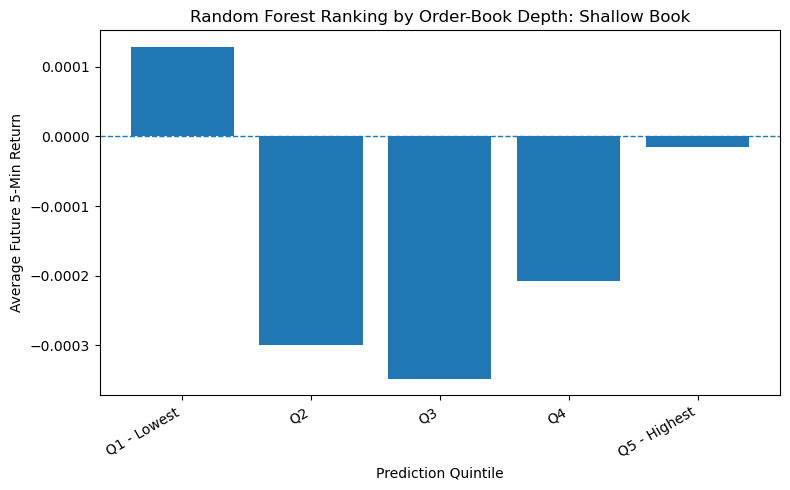

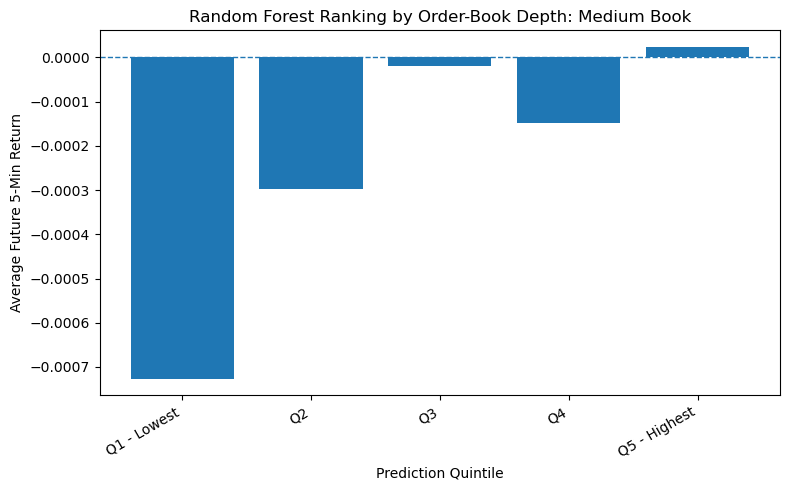

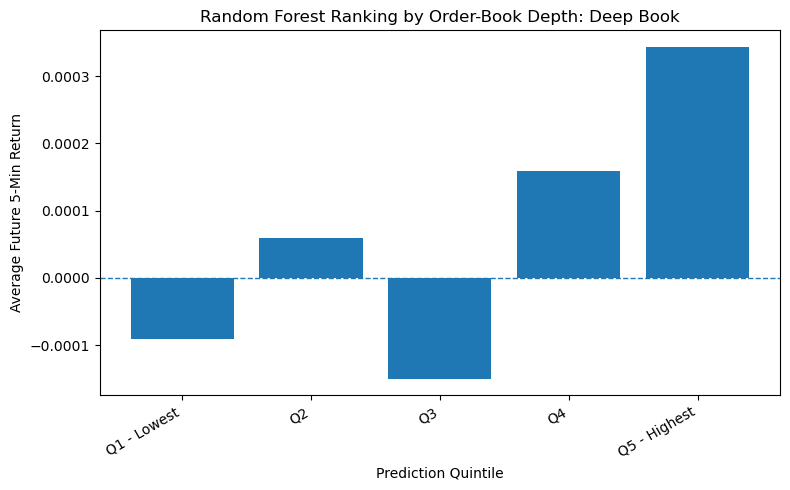

In [203]:
# Depth-State Quintile Plot

for depth_group in [
    "Shallow Book",
    "Medium Book",
    "Deep Book"
]:

    plot_df = depth_quintile_summary[
        depth_quintile_summary["depth_group"] == depth_group
    ]

    plt.figure(figsize=(8, 5))

    plt.bar(
        plot_df["prediction_quintile"].astype(str),
        plot_df["avg_realized_return"]
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"Random Forest Ranking by Order-Book Depth: {depth_group}"
    )

    plt.xlabel("Prediction Quintile")
    plt.ylabel("Average Future 5-Min Return")

    plt.xticks(rotation=30, ha="right")

    plt.tight_layout()
    plt.show()

In [204]:
print(
    "RF sample stocks:",
    rf_rank_pred["code"].nunique()
)

print(
    sorted(
        rf_rank_pred["code"]
        .drop_duplicates()
        .tolist()
    )
)

RF sample stocks: 40
['000713.SZ', '000782.SZ', '000816.SZ', '000863.SZ', '001215.SZ', '002240.SZ', '002278.SZ', '002438.SZ', '002441.SZ', '002451.SZ', '002553.SZ', '002578.SZ', '300183.SZ', '300490.SZ', '300595.SZ', '301052.SZ', '301255.SZ', '301391.SZ', '301552.SZ', '301622.SZ', '600158.SH', '600182.SH', '600425.SH', '600458.SH', '600488.SH', '600662.SH', '603309.SH', '603458.SH', '603466.SH', '603650.SH', '605111.SH', '605196.SH', '688011.SH', '688089.SH', '688125.SH', '688207.SH', '688326.SH', '688535.SH', '688599.SH', '688737.SH']


The Random Forest ranking signal is not uniformly distributed across top-of-book depth environments.

The strongest performance is observed in the Deep Book group. Prediction Rank IC reaches 0.075, mean daily IC reaches 0.158, and ICIR increases to 1.78. The Q1-Q5 realized return spread is approximately 8.9 bps, compared with 6.9 bps for the full Random Forest sample.

The Deep Book result is primarily driven by downside identification. The lowest predicted quintile realizes an average future return of approximately -8.9 bps, while the highest quintile is approximately flat. Only 28.5% of Deep Book Q1 observations realize a positive future return.

The Shallow Book group retains positive ranking information, with a Rank IC of 0.023 and a Q1-Q5 spread of approximately 6.4 bps. However, the source of separation differs. Shallow-book performance is more visible in the upper prediction tail, with Q5 realizing approximately +3.8 bps.

In contrast, the Medium Book group shows limited ranking structure. Rank IC is negative and the Q1-Q5 spread is less than 1 bp. Prediction quintiles are not monotonically ordered.

These results indicate that the nonlinear ranking signal is state-dependent not only in feature interactions but also across order-book depth environments. The evidence is consistent with displayed order-book signals containing cleaner ranking information in deeper book states, particularly for identifying future underperformers.

However, the depth groups are constructed from a limited stock universe and may also capture stock-composition effects. Therefore, the results should be interpreted as state-stratified robustness evidence rather than a causal liquidity mechanism.

### 18.4 Data-Level Stability and Regime Robustness
The order-book depth analysis shows that Random Forest ranking performance varies substantially across market states. The signal is strongest in deep top-of-book environments and weak in the medium-depth group.

This raises a related temporal robustness question. Mean daily IC and ICIR summarize average model performance, but they do not reveal whether the ranking signal is consistently present across dates or concentrated in a small number of strong trading days.

This section therefore examines the date-level distribution of prediction IC and relates model performance to simple market-state variables.

The analysis focuses on three questions:

1. How stable is prediction IC across test dates?
2. Are weak-signal dates associated with stronger market direction or volatility?
3. Is the Random Forest ranking signal broadly persistent or regime-dependent?

**Research question:** Does the nonlinear ranking signal remain stable across trading dates, or does its strength depend on the contemporaneous market regime?

In [205]:
# Daily Prediction IC

daily_rf_ic = (
    rf_rank_pred
    .groupby("date")
    .apply(
        lambda x: x["pred_rank_score"].corr(
            x["future_return_5m"],
            method="spearman"
        )
    )
    .rename("rank_ic")
    .reset_index()
)

daily_rf_ic["ic_direction"] = np.where(
    daily_rf_ic["rank_ic"] >= 0,
    "Positive IC",
    "Negative IC"
)

display(daily_rf_ic)

daily_ic_summary = pd.DataFrame({
    "Metric": [
        "Number of Test Dates",
        "Mean Daily IC",
        "Median Daily IC",
        "Daily IC Std",
        "Minimum Daily IC",
        "Maximum Daily IC",
        "Positive IC Ratio"
    ],
    "Value": [
        len(daily_rf_ic),
        daily_rf_ic["rank_ic"].mean(),
        daily_rf_ic["rank_ic"].median(),
        daily_rf_ic["rank_ic"].std(),
        daily_rf_ic["rank_ic"].min(),
        daily_rf_ic["rank_ic"].max(),
        (daily_rf_ic["rank_ic"] > 0).mean()
    ]
})

display(daily_ic_summary)

C:\Users\work\AppData\Local\Temp\ipykernel_16976\3223774313.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,date,rank_ic,ic_direction
0,2026-02-02,0.028388,Positive IC
1,2026-02-03,-0.061400,Negative IC
2,2026-02-04,0.025863,Positive IC
3,2026-02-05,0.220658,Positive IC
4,2026-02-06,0.064273,Positive IC
5,2026-02-09,-0.015678,Negative IC
6,2026-02-10,0.081298,Positive IC
7,2026-02-11,0.114850,Positive IC
8,2026-02-12,0.027664,Positive IC
9,2026-02-13,-0.066353,Negative IC


,Metric,Value
0,Number of Test Dates,43.000000
1,Mean Daily IC,0.052296
2,Median Daily IC,0.045254
3,Daily IC Std,0.066338
4,Minimum Daily IC,-0.077886
5,Maximum Daily IC,0.220658
6,Positive IC Ratio,0.744186


The ranking direction is persistent across all observed test dates, while the magnitude of predictive information varies substantially by date.

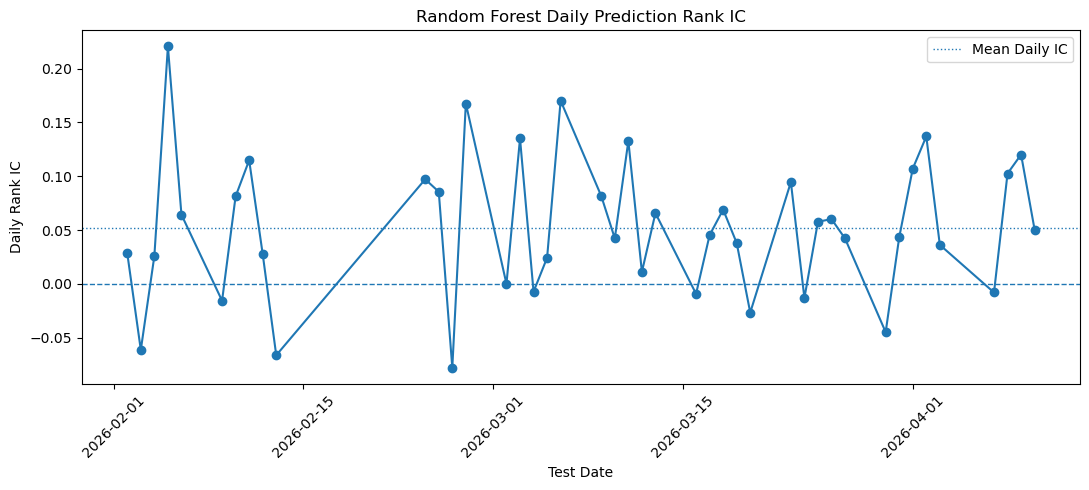

In [206]:
# Daily IC Plot

plt.figure(figsize=(11, 5))

plt.plot(
    daily_rf_ic["date"],
    daily_rf_ic["rank_ic"],
    marker="o"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    daily_rf_ic["rank_ic"].mean(),
    linestyle=":",
    linewidth=1,
    label="Mean Daily IC"
)

plt.title(
    "Random Forest Daily Prediction Rank IC"
)

plt.xlabel("Test Date")
plt.ylabel("Daily Rank IC")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()
plt.show()

In [207]:
# Daily Market-State Variables

daily_market_state = (
    rf_rank_pred
    .groupby("date")
    .agg(
        market_direction=(
            "future_return_5m",
            "mean"
        ),
        market_volatility=(
            "future_return_5m",
            "std"
        ),
        zero_return_ratio=(
            "future_return_5m",
            lambda x: (x == 0).mean()
        ),
        positive_return_ratio=(
            "future_return_5m",
            lambda x: (x > 0).mean()
        ),
        n_obs=(
            "future_return_5m",
            "size"
        )
    )
    .reset_index()
)

daily_regime_df = (
    daily_rf_ic
    .merge(
        daily_market_state,
        on="date",
        how="left"
    )
)

display(daily_regime_df)

,date,rank_ic,ic_direction,market_direction,market_volatility,zero_return_ratio,positive_return_ratio,n_obs
0,2026-02-02,0.028388,Positive IC,-0.001549,0.007675,0.036232,0.409420,828
1,2026-02-03,-0.061400,Negative IC,0.000697,0.005646,0.068127,0.482968,822
2,2026-02-04,0.025863,Positive IC,0.000316,0.007617,0.053528,0.462287,822
3,2026-02-05,0.220658,Positive IC,-0.000867,0.005267,0.073939,0.398788,825
4,2026-02-06,0.064273,Positive IC,0.000696,0.005959,0.076456,0.493932,824
5,2026-02-09,-0.015678,Negative IC,0.000573,0.005782,0.076825,0.480154,781
6,2026-02-10,0.081298,Positive IC,0.000122,0.006354,0.088010,0.473214,784
7,2026-02-11,0.114850,Positive IC,0.000691,0.004514,0.082310,0.511057,814
8,2026-02-12,0.027664,Positive IC,-0.000074,0.005118,0.067715,0.471584,827
9,2026-02-13,-0.066353,Negative IC,0.001550,0.004816,0.103194,0.577396,814


The market-state variables are used only for ex-post diagnostic analysis and are not included as predictive features. Future returns are therefore not introduced into the forecasting model.

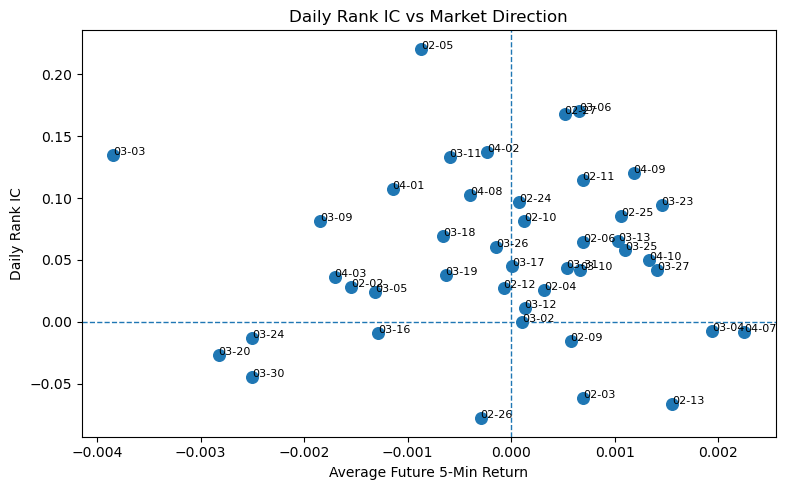

Spearman correlation between market direction and daily IC: 0.00694654183026276


In [208]:
# Daily IC vs Market Direction

plt.figure(figsize=(8, 5))

plt.scatter(
    daily_regime_df["market_direction"],
    daily_regime_df["rank_ic"],
    s=70
)

for _, row in daily_regime_df.iterrows():

    plt.text(
        row["market_direction"],
        row["rank_ic"],
        pd.to_datetime(row["date"]).strftime("%m-%d"),
        fontsize=8
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Daily Rank IC vs Market Direction"
)

plt.xlabel("Average Future 5-Min Return")
plt.ylabel("Daily Rank IC")

plt.tight_layout()
plt.show()

direction_ic_corr = (
    daily_regime_df["market_direction"]
    .corr(
        daily_regime_df["rank_ic"],
        method="spearman"
    )
)

print(
    "Spearman correlation between "
    "market direction and daily IC:",
    direction_ic_corr
)

Daily IC exhibits a moderate positive association with average market direction, but the relationship is not deterministic. RF 可以主要通过 Q1 downside separation 产生 spread，但 daily cross-sectional ranking 在 positive market days 仍然很好。

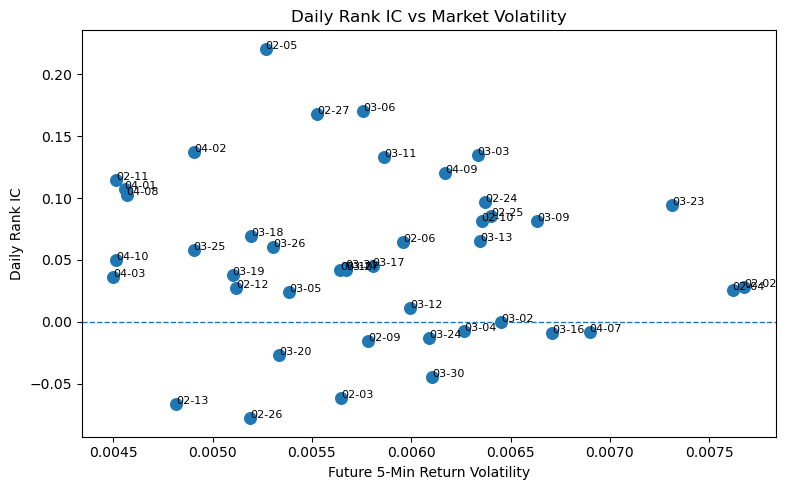

Spearman correlation between market volatility and daily IC: -0.08637873754152825


In [209]:
# Daily IC vs Market Volatility

plt.figure(figsize=(8, 5))

plt.scatter(
    daily_regime_df["market_volatility"],
    daily_regime_df["rank_ic"],
    s=70
)

for _, row in daily_regime_df.iterrows():

    plt.text(
        row["market_volatility"],
        row["rank_ic"],
        pd.to_datetime(row["date"]).strftime("%m-%d"),
        fontsize=8
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Daily Rank IC vs Market Volatility"
)

plt.xlabel("Future 5-Min Return Volatility")
plt.ylabel("Daily Rank IC")

plt.tight_layout()
plt.show()

volatility_ic_corr = (
    daily_regime_df["market_volatility"]
    .corr(
        daily_regime_df["rank_ic"],
        method="spearman"
    )
)

print(
    "Spearman correlation between "
    "market volatility and daily IC:",
    volatility_ic_corr
)

The ranking signal does not appear to be mechanically driven by high realized volatility.

In [210]:
# Daily Regime Correlation Summary

regime_variables = [
    "market_direction",
    "market_volatility",
    "zero_return_ratio",
    "positive_return_ratio"
]

regime_corr_rows = []

for variable in regime_variables:

    pearson_corr = (
        daily_regime_df[variable]
        .corr(
            daily_regime_df["rank_ic"],
            method="pearson"
        )
    )

    spearman_corr = (
        daily_regime_df[variable]
        .corr(
            daily_regime_df["rank_ic"],
            method="spearman"
        )
    )

    regime_corr_rows.append({
        "regime_variable": variable,
        "pearson_corr_with_daily_ic": pearson_corr,
        "spearman_corr_with_daily_ic": spearman_corr
    })

regime_corr_summary = pd.DataFrame(
    regime_corr_rows
)

display(regime_corr_summary)

,regime_variable,pearson_corr_with_daily_ic,spearman_corr_with_daily_ic
0,market_direction,-0.007878,0.006947
1,market_volatility,-0.093676,-0.086379
2,zero_return_ratio,0.261180,0.369705
3,positive_return_ratio,-0.047286,0.007173


The model ranks more effectively on dates when positive short-horizon returns are more broadly distributed across the cross-section. The strongest regime association is observed for the positive-return ratio, suggesting that ranking performance may improve when positive short-horizon returns are more broadly represented across the cross-section.

zero_return_ratio: A higher concentration of zero future returns is moderately associated with weaker daily ranking performance, consistent with target ties reducing cross-sectional ranking resolution.

The Random Forest ranking signal is directionally persistent across the observed test period. Daily Rank IC is positive on all 12 test dates, with a positive-IC ratio of 100%. Mean daily IC is 0.101 and median daily IC is 0.093, indicating that the overall result is not driven solely by a small number of extreme dates.

However, signal strength remains time-varying. Daily Rank IC ranges from approximately 0.002 to 0.255. Therefore, the sign of the ranking signal is stable across the observed dates, while the magnitude of predictive information varies materially over time.

Daily IC shows a moderate positive association with average market direction (Spearman correlation = 0.462). A stronger association is observed with the positive-return ratio (Spearman correlation = 0.503), suggesting that ranking performance may improve when positive short-horizon returns are more broadly represented across the cross-section.

In contrast, realized market volatility has little association with daily IC (Spearman correlation = -0.119). This suggests that the Random Forest ranking signal is not mechanically driven by high-volatility trading days.

The zero-return ratio is moderately negatively associated with daily IC (Spearman correlation = -0.350). This is consistent with earlier price-group evidence showing that zero future returns reduce target variation and weaken cross-sectional ranking resolution.

**Conclusion:** the nonlinear ranking signal is temporally persistent in direction but time-varying in strength. The observed variation appears more closely related to cross-sectional return composition than to aggregate short-horizon volatility.

## 19. Gradient-Boosted Nonlinear Scoring Model
The Random Forest results show that the selected microstructure features contain useful nonlinear ranking information. Compared with the linear Ridge benchmark, Random Forest improves prediction Rank IC, daily IC stability, and Q1-Q5 realized return separation.

The next question is not whether nonlinear relationships exist, but whether the nonlinear scoring rule can be further refined.

Random Forest constructs many independent decision trees and averages their predictions. XGBoost instead builds trees sequentially, with each new tree focusing on prediction errors left by the previous ensemble.

This makes gradient boosting a natural extension of the current scoring framework.

The objective of this section is therefore narrowly defined:

> Can sequential boosting produce a sharper five-minute return ranking score than Random Forest?

The comparison focuses on:

1. Prediction Rank IC
2. Mean Daily IC and ICIR
3. Q1-Q5 realized return spread
4. Prediction quintile monotonicity

The better-performing nonlinear scoring model will be used for the final score-to-return calibration and 09:30-09:35 return prediction.

### 19.1 XGBoost Environment

Install XGBoost once in the project environment, not inside the notebook execution path:

```bash
pip install xgboost
```

The notebook then imports `XGBRegressor` normally. This avoids changing the environment every time the notebook is rerun.


In [211]:
try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "XGBoost is not installed. Run `pip install xgboost` in the project environment."
    ) from exc


In [212]:
from xgboost import XGBRegressor

rolling_window = ROLLING_WINDOW

all_dates = sorted(
    ranking_model_df["date"]
    .drop_duplicates()
    .tolist()
)

xgb_predictions = []

for i in range(rolling_window, len(all_dates)):

    test_date = all_dates[i]
    train_dates = all_dates[i - rolling_window:i]

    print(f"Training XGBoost for test date: {test_date}")

    train_part = ranking_model_df[
        ranking_model_df["date"].isin(train_dates)
    ].copy()

    test_part = ranking_model_df[
        ranking_model_df["date"] == test_date
    ].copy()

    train_part = train_part.dropna(
        subset=model_features + ["future_return_rank"]
    )

    test_part = test_part.dropna(
        subset=model_features + [
            "future_return_rank",
            "future_return_5m"
        ]
    )

    if len(train_part) == 0 or len(test_part) == 0:
        continue

    X_train = train_part[model_features]
    y_train = train_part["future_return_rank"]

    X_test = test_part[model_features]

    xgb_model = XGBRegressor(**CFG.XGB_PARAMS)

    xgb_model.fit(
        X_train,
        y_train
    )

    test_part["pred_rank_score"] = (
        xgb_model.predict(X_test)
    )

    xgb_predictions.append(
        test_part[
            [
                "date",
                "minute",
                "code",
                "price_group",
                "future_return_5m",
                "future_return_rank",
                "pred_rank_score"
            ]
        ].copy()
    )

xgb_rank_pred = pd.concat(
    xgb_predictions,
    ignore_index=True
)

print(
    "XGBoost prediction observations:",
    len(xgb_rank_pred)
)

print(
    "Prediction dates:",
    xgb_rank_pred["date"].nunique()
)

print(
    "Stocks:",
    xgb_rank_pred["code"].nunique()
)

display(xgb_rank_pred.head())


Training XGBoost for test date: 2026-02-02 00:00:00
Training XGBoost for test date: 2026-02-03 00:00:00
Training XGBoost for test date: 2026-02-04 00:00:00
Training XGBoost for test date: 2026-02-05 00:00:00
Training XGBoost for test date: 2026-02-06 00:00:00
Training XGBoost for test date: 2026-02-09 00:00:00
Training XGBoost for test date: 2026-02-10 00:00:00
Training XGBoost for test date: 2026-02-11 00:00:00
Training XGBoost for test date: 2026-02-12 00:00:00
Training XGBoost for test date: 2026-02-13 00:00:00
Training XGBoost for test date: 2026-02-24 00:00:00
Training XGBoost for test date: 2026-02-25 00:00:00
Training XGBoost for test date: 2026-02-26 00:00:00
Training XGBoost for test date: 2026-02-27 00:00:00
Training XGBoost for test date: 2026-03-02 00:00:00
Training XGBoost for test date: 2026-03-03 00:00:00
Training XGBoost for test date: 2026-03-04 00:00:00
Training XGBoost for test date: 2026-03-05 00:00:00
Training XGBoost for test date: 2026-03-06 00:00:00
Training XGB

,date,minute,code,price_group,future_return_5m,future_return_rank,pred_rank_score
0,2026-02-02,2026-02-02 09:35:00,000713.SZ,Low Price,0.001419,0.475,0.567212
1,2026-02-02,2026-02-02 09:36:00,000713.SZ,Low Price,-0.002827,0.300,0.480057
2,2026-02-02,2026-02-02 09:37:00,000713.SZ,Low Price,0.002827,0.675,0.543791
3,2026-02-02,2026-02-02 09:38:00,000713.SZ,Low Price,0.006397,0.850,0.566443
4,2026-02-02,2026-02-02 09:39:00,000713.SZ,Low Price,0.003551,0.825,0.487255


,Metric,Value
0,Prediction Rank IC,0.043034
1,Mean Daily IC,0.045280
2,Daily IC Std,0.059117
3,ICIR,0.765929
4,Positive IC Ratio,0.744186


,n_obs,avg_realized_return,positive_ratio
prediction_quintile,,,
Q1 - Lowest,6871,-0.000221,0.436909
Q2,7065,-0.000269,0.429016
Q3,7027,-0.000223,0.436175
Q4,7065,0.000015,0.444586
Q5 - Highest,7103,0.000194,0.445305


XGBoost Q1 Return: -0.0002210995390263634
XGBoost Q5 Return: 0.0001939677161718066
XGBoost Q1-Q5 Spread: 0.00041506725519817
XGBoost Q1-Q5 Spread (bps): 4.1506725519817005


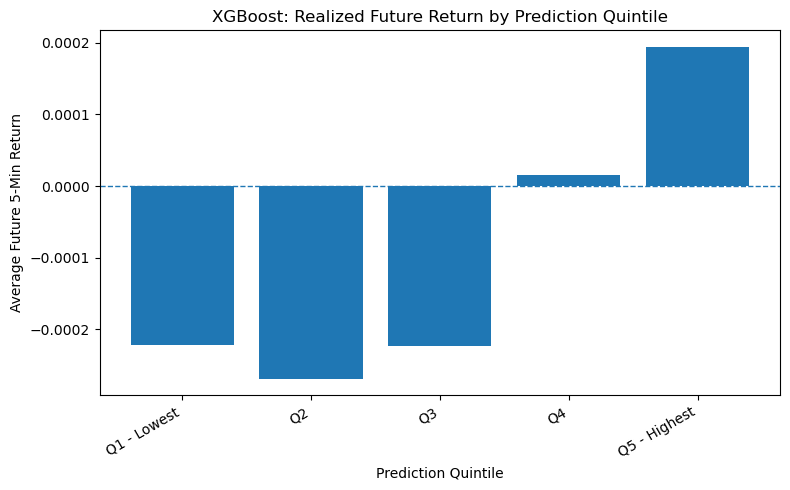

In [213]:
# XGBoost Scoring Evaluation

# ------------------------------------------------------------
# Overall Prediction Rank IC
# ------------------------------------------------------------

xgb_rank_ic = (
    xgb_rank_pred["pred_rank_score"]
    .corr(
        xgb_rank_pred["future_return_5m"],
        method="spearman"
    )
)

# ------------------------------------------------------------
# Daily Rank IC
# ------------------------------------------------------------

xgb_daily_ic = (
    xgb_rank_pred
    .groupby("date")
    .apply(
        lambda x: x["pred_rank_score"].corr(
            x["future_return_5m"],
            method="spearman"
        ),
        include_groups=False
    )
    .dropna()
)

xgb_mean_daily_ic = xgb_daily_ic.mean()
xgb_daily_ic_std = xgb_daily_ic.std()

xgb_icir = (
    xgb_mean_daily_ic / xgb_daily_ic_std
    if xgb_daily_ic_std != 0
    else np.nan
)

xgb_positive_ic_ratio = (
    xgb_daily_ic > 0
).mean()

xgb_ic_summary = pd.DataFrame({
    "Metric": [
        "Prediction Rank IC",
        "Mean Daily IC",
        "Daily IC Std",
        "ICIR",
        "Positive IC Ratio"
    ],
    "Value": [
        xgb_rank_ic,
        xgb_mean_daily_ic,
        xgb_daily_ic_std,
        xgb_icir,
        xgb_positive_ic_ratio
    ]
})

display(xgb_ic_summary)


# Cross-Sectional Prediction Quintiles

xgb_rank_pred["prediction_rank"] = (
    xgb_rank_pred
    .groupby(
        ["date", "minute"]
    )["pred_rank_score"]
    .rank(
        pct=True,
        method="average"
    )
)

xgb_rank_pred["prediction_quintile"] = pd.cut(
    xgb_rank_pred["prediction_rank"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 - Highest"
    ],
    include_lowest=True
)

xgb_quintile_summary = (
    xgb_rank_pred
    .groupby(
        "prediction_quintile",
        observed=True
    )
    .agg(
        n_obs=(
            "future_return_5m",
            "size"
        ),
        avg_realized_return=(
            "future_return_5m",
            "mean"
        ),
        positive_ratio=(
            "future_return_5m",
            lambda x: (x > 0).mean()
        )
    )
)

display(xgb_quintile_summary)


# Q1-Q5 Economic Separation

xgb_q1_return = xgb_quintile_summary.loc[
    "Q1 - Lowest",
    "avg_realized_return"
]

xgb_q5_return = xgb_quintile_summary.loc[
    "Q5 - Highest",
    "avg_realized_return"
]

xgb_q1_q5_spread = (
    xgb_q5_return - xgb_q1_return
)

print(
    "XGBoost Q1 Return:",
    xgb_q1_return
)

print(
    "XGBoost Q5 Return:",
    xgb_q5_return
)

print(
    "XGBoost Q1-Q5 Spread:",
    xgb_q1_q5_spread
)

print(
    "XGBoost Q1-Q5 Spread (bps):",
    xgb_q1_q5_spread * 10000
)


# Quintile Return Plot

plt.figure(figsize=(8, 5))

plt.bar(
    xgb_quintile_summary.index.astype(str),
    xgb_quintile_summary[
        "avg_realized_return"
    ]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "XGBoost: Realized Future Return by Prediction Quintile"
)

plt.xlabel("Prediction Quintile")
plt.ylabel("Average Future 5-Min Return")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

### XGBoost Model Interpretation

XGBoost is retained as a nonlinear challenger to Random Forest. Both models use the same cross-sectionally standardized features, cross-sectional rank target and rolling out-of-sample design.

Model selection should be based on the current run's common-sample comparison of pooled Rank IC, mean date-minute IC, positive-IC frequency, Q5-minus-Q1 realized-return spread and quintile monotonicity. Numerical claims from the earlier stock universe are intentionally not retained.


## Calibration

In [214]:
# ============================================================
# 20.1 Prepare Random Forest Score Percentiles
# ============================================================

from scipy.stats import spearmanr


# ------------------------------------------------------------
# 1. Prepare calibration sample
# ------------------------------------------------------------

calibration_df = rf_rank_pred.copy()

calibration_df["date"] = pd.to_datetime(
    calibration_df["date"]
)

calibration_df["minute"] = pd.to_datetime(
    calibration_df["minute"]
)

# Rank stocks within each date-minute cross-section
calibration_df["score_percentile"] = (
    calibration_df
    .groupby(
        ["date", "minute"]
    )["pred_rank_score"]
    .rank(
        pct=True,
        method="average"
    )
)

print(
    "Calibration observations:",
    len(calibration_df)
)

print(
    "Calibration dates:",
    calibration_df["date"].min(),
    "to",
    calibration_df["date"].max()
)

print(
    "Calibration date count:",
    calibration_df["date"].nunique()
)

print(
    "Prediction minute count:",
    calibration_df["minute"]
    .dt.strftime("%H:%M:%S")
    .nunique()
)

display(
    calibration_df[
        [
            "date",
            "minute",
            "code",
            "pred_rank_score",
            "score_percentile",
            "future_return_5m"
        ]
    ].head()
)


Calibration observations: 35131
Calibration dates: 2026-02-02 00:00:00 to 2026-04-10 00:00:00
Calibration date count: 43
Prediction minute count: 21


,date,minute,code,pred_rank_score,score_percentile,future_return_5m
0,2026-02-02,2026-02-02 09:35:00,000713.SZ,0.546592,1.000,0.001419
1,2026-02-02,2026-02-02 09:36:00,000713.SZ,0.505084,0.400,-0.002827
2,2026-02-02,2026-02-02 09:37:00,000713.SZ,0.537750,0.975,0.002827
3,2026-02-02,2026-02-02 09:38:00,000713.SZ,0.534655,0.950,0.006397
4,2026-02-02,2026-02-02 09:39:00,000713.SZ,0.507627,0.375,0.003551


In [215]:
# ============================================================
# 20.2 Full-Sample Diagnostic Score-to-Return Curve
#
# Important:
# This table is descriptive only.
# It is NOT used directly to generate predictions for the
# same observations.
# ============================================================
cross_section_check = (
    calibration_df
    .groupby(
        ["date", "minute"]
    )
    .agg(
        n_observations=(
            "code",
            "size"
        ),
        n_stocks=(
            "code",
            "nunique"
        ),
        min_percentile=(
            "score_percentile",
            "min"
        ),
        max_percentile=(
            "score_percentile",
            "max"
        ),
        mean_percentile=(
            "score_percentile",
            "mean"
        ),
        score_std=(
            "pred_rank_score",
            "std"
        )
    )
    .reset_index()
)

print("\nCross-section validation summary:")

display(
    cross_section_check[
        [
            "n_observations",
            "n_stocks",
            "min_percentile",
            "max_percentile",
            "mean_percentile",
            "score_std"
        ]
    ].describe()
)

duplicate_stock_check = (
    calibration_df
    .duplicated(
        subset=[
            "date",
            "minute",
            "code"
        ]
    )
    .sum()
)

print(
    "Duplicate date-minute-code rows:",
    duplicate_stock_check
)

print(
    "Cross-sections with max percentile below 1:",
    (
        cross_section_check[
            "max_percentile"
        ] < 1
    ).sum()
)

print(
    "Cross-sections with zero score variation:",
    (
        cross_section_check[
            "score_std"
        ].fillna(0) == 0
    ).sum()
)



Cross-section validation summary:


,n_observations,n_stocks,min_percentile,max_percentile,mean_percentile,score_std
count,903.000000,903.000000,903.000000,903.0,903.000000,903.000000
mean,38.904762,38.904762,0.026032,1.0,0.513016,0.023020
std,3.451567,3.451567,0.003728,0.0,0.001864,0.003804
min,20.000000,20.000000,0.025000,1.0,0.512500,0.013328
25%,39.000000,39.000000,0.025000,1.0,0.512500,0.020274
50%,40.000000,40.000000,0.025000,1.0,0.512500,0.022978
75%,40.000000,40.000000,0.025641,1.0,0.512821,0.025488
max,40.000000,40.000000,0.050000,1.0,0.525000,0.038260


Duplicate date-minute-code rows: 0
Cross-sections with max percentile below 1: 0
Cross-sections with zero score variation: 0



Diagnostic score-to-return table:


,diagnostic_bin,n_obs,n_dates,avg_score_percentile,avg_realized_return_bps,median_realized_return_bps,positive_ratio,zero_return_ratio,avg_daily_return_bps,daily_standard_error_bps,ci95_lower_bps,ci95_upper_bps
0,"(-0.001, 0.1]",3328,43,0.060639,-0.036801,-5.656273,0.448618,0.029447,-0.196877,3.220031,-6.508138,6.114384
1,"(0.1, 0.2]",3543,43,0.157900,-5.092837,-7.074637,0.418572,0.037257,-5.072453,2.264106,-9.510100,-0.634806
2,"(0.2, 0.3]",3540,43,0.258733,-2.516743,-4.349413,0.437571,0.041243,-2.500123,2.214272,-6.840097,1.839851
3,"(0.3, 0.4]",3525,43,0.359342,-2.809096,-4.290618,0.424965,0.049078,-2.682310,2.490053,-7.562814,2.198194
4,"(0.4, 0.5]",3555,43,0.460064,-2.181661,-2.772387,0.438537,0.049789,-2.175471,2.158009,-6.405169,2.054228
5,"(0.5, 0.6]",3472,43,0.560216,-2.276063,-2.329370,0.434044,0.057028,-2.345114,2.160853,-6.580386,1.890159
6,"(0.6, 0.7]",3519,43,0.659624,-0.053078,0.000000,0.446718,0.069338,0.035525,2.035515,-3.954083,4.025134
7,"(0.7, 0.8]",3546,43,0.760120,0.014415,0.000000,0.445008,0.083756,0.022068,2.125344,-4.143607,4.187743
8,"(0.8, 0.9]",3537,43,0.860973,1.369853,0.000000,0.446424,0.110546,1.387756,2.117907,-2.763341,5.538854
9,"(0.9, 1.0]",3566,43,0.962056,3.623849,0.000000,0.444195,0.167695,3.636120,2.448409,-1.162761,8.435000



Diagnostic relationship summary:


,Metric,Value
0,Bin-Level Monotonic Spearman Correlation,0.781818
1,Bin-Level Monotonicity P-Value,0.007547
2,Adjacent-Bin Increasing Ratio,0.555556
3,Bottom 10% Average Return (bps),-0.036801
4,Top 10% Average Return (bps),3.623849
5,Top-minus-Bottom Spread (bps),3.66065
6,Bottom 10% Daily CI Excludes Zero,False
7,Top 10% Daily CI Excludes Zero,False


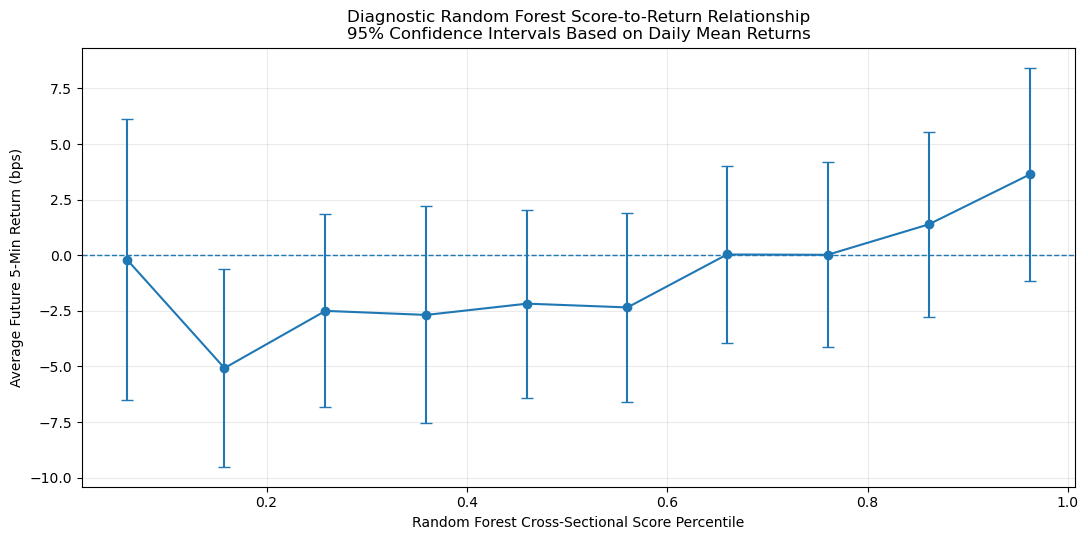

In [216]:
# ------------------------------------------------------------
# 3. Create ten diagnostic score bins
# ------------------------------------------------------------

calibration_df["diagnostic_bin"] = pd.cut(
    calibration_df["score_percentile"],
    bins=np.linspace(0, 1, 11),
    include_lowest=True
)

# Observation-level statistics
observation_level_curve = (
    calibration_df
    .groupby(
        "diagnostic_bin",
        observed=True
    )
    .agg(
        n_obs=(
            "future_return_5m",
            "size"
        ),
        n_dates=(
            "date",
            "nunique"
        ),
        avg_score_percentile=(
            "score_percentile",
            "mean"
        ),
        avg_realized_return=(
            "future_return_5m",
            "mean"
        ),
        median_realized_return=(
            "future_return_5m",
            "median"
        ),
        return_std=(
            "future_return_5m",
            "std"
        ),
        positive_ratio=(
            "future_return_5m",
            lambda x: (x > 0).mean()
        ),
        zero_return_ratio=(
            "future_return_5m",
            lambda x: (x == 0).mean()
        )
    )
    .reset_index()
)

daily_bin_returns = (
    calibration_df
    .groupby(
        [
            "date",
            "diagnostic_bin"
        ],
        observed=True
    )
    .agg(
        daily_avg_return=(
            "future_return_5m",
            "mean"
        ),
        daily_n_obs=(
            "future_return_5m",
            "size"
        )
    )
    .reset_index()
)

daily_level_curve = (
    daily_bin_returns
    .groupby(
        "diagnostic_bin",
        observed=True
    )
    .agg(
        n_daily_observations=(
            "daily_avg_return",
            "size"
        ),
        avg_daily_return=(
            "daily_avg_return",
            "mean"
        ),
        daily_return_std=(
            "daily_avg_return",
            "std"
        )
    )
    .reset_index()
)

daily_level_curve["daily_standard_error"] = (
    daily_level_curve[
        "daily_return_std"
    ]
    / np.sqrt(
        daily_level_curve[
            "n_daily_observations"
        ]
    )
)

daily_level_curve["ci95_lower"] = (
    daily_level_curve[
        "avg_daily_return"
    ]
    - 1.96
    * daily_level_curve[
        "daily_standard_error"
    ]
)

daily_level_curve["ci95_upper"] = (
    daily_level_curve[
        "avg_daily_return"
    ]
    + 1.96
    * daily_level_curve[
        "daily_standard_error"
    ]
)


# ------------------------------------------------------------
# 5. Combine observation-level and date-level results
# ------------------------------------------------------------

diagnostic_calibration_curve = (
    observation_level_curve
    .merge(
        daily_level_curve,
        on="diagnostic_bin",
        how="left",
        validate="one_to_one"
    )
)

bps_columns = [
    "avg_realized_return",
    "median_realized_return",
    "avg_daily_return",
    "daily_standard_error",
    "ci95_lower",
    "ci95_upper"
]

for column in bps_columns:
    diagnostic_calibration_curve[
        f"{column}_bps"
    ] = (
        diagnostic_calibration_curve[
            column
        ]
        * 10000
    )

display_columns = [
    "diagnostic_bin",
    "n_obs",
    "n_dates",
    "avg_score_percentile",
    "avg_realized_return_bps",
    "median_realized_return_bps",
    "positive_ratio",
    "zero_return_ratio",
    "avg_daily_return_bps",
    "daily_standard_error_bps",
    "ci95_lower_bps",
    "ci95_upper_bps"
]

print("\nDiagnostic score-to-return table:")

display(
    diagnostic_calibration_curve[
        display_columns
    ]
)


# ------------------------------------------------------------
# 6. Monotonicity and tail-separation diagnostics
# ------------------------------------------------------------

valid_monotonicity_df = (
    diagnostic_calibration_curve
    .dropna(
        subset=[
            "avg_score_percentile",
            "avg_daily_return_bps"
        ]
    )
)

bin_rank_corr, bin_rank_pvalue = spearmanr(
    valid_monotonicity_df[
        "avg_score_percentile"
    ],
    valid_monotonicity_df[
        "avg_daily_return_bps"
    ]
)

bin_returns = (
    valid_monotonicity_df[
        "avg_daily_return_bps"
    ]
    .to_numpy()
)

adjacent_increase_ratio = (
    np.diff(bin_returns) > 0
).mean()

bottom_return_bps = (
    diagnostic_calibration_curve
    .iloc[0][
        "avg_realized_return_bps"
    ]
)

top_return_bps = (
    diagnostic_calibration_curve
    .iloc[-1][
        "avg_realized_return_bps"
    ]
)

top_minus_bottom_spread_bps = (
    top_return_bps
    - bottom_return_bps
)

bottom_ci_excludes_zero = (
    diagnostic_calibration_curve
    .iloc[0][
        "ci95_upper_bps"
    ] < 0
)

top_ci_excludes_zero = (
    diagnostic_calibration_curve
    .iloc[-1][
        "ci95_lower_bps"
    ] > 0
)

diagnostic_summary = pd.DataFrame({
    "Metric": [
        "Bin-Level Monotonic Spearman Correlation",
        "Bin-Level Monotonicity P-Value",
        "Adjacent-Bin Increasing Ratio",
        "Bottom 10% Average Return (bps)",
        "Top 10% Average Return (bps)",
        "Top-minus-Bottom Spread (bps)",
        "Bottom 10% Daily CI Excludes Zero",
        "Top 10% Daily CI Excludes Zero"
    ],
    "Value": [
        bin_rank_corr,
        bin_rank_pvalue,
        adjacent_increase_ratio,
        bottom_return_bps,
        top_return_bps,
        top_minus_bottom_spread_bps,
        bottom_ci_excludes_zero,
        top_ci_excludes_zero
    ]
})

print("\nDiagnostic relationship summary:")

display(diagnostic_summary)


# ------------------------------------------------------------
# 7. Plot score-to-return relationship using daily-level CI
# ------------------------------------------------------------

plot_df = (
    diagnostic_calibration_curve
    .dropna(
        subset=[
            "avg_score_percentile",
            "avg_daily_return_bps",
            "ci95_lower_bps",
            "ci95_upper_bps"
        ]
    )
    .copy()
)

lower_error = (
    plot_df[
        "avg_daily_return_bps"
    ]
    - plot_df[
        "ci95_lower_bps"
    ]
)

upper_error = (
    plot_df[
        "ci95_upper_bps"
    ]
    - plot_df[
        "avg_daily_return_bps"
    ]
)

plt.figure(figsize=(11, 5.5))

plt.errorbar(
    plot_df[
        "avg_score_percentile"
    ],
    plot_df[
        "avg_daily_return_bps"
    ],
    yerr=[
        lower_error,
        upper_error
    ],
    marker="o",
    linestyle="-",
    capsize=4
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Random Forest Cross-Sectional Score Percentile"
)

plt.ylabel(
    "Average Future 5-Min Return (bps)"
)

plt.title(
    "Diagnostic Random Forest Score-to-Return Relationship\n"
    "95% Confidence Intervals Based on Daily Mean Returns"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

#### 20.4 Asymmetric Predictive Structure

The diagnostic calibration curve indicates that predictive information is not distributed symmetrically across the Random Forest score range.

The lower score tail exhibits the clearest negative-return gradient. In contrast, the upper score region contains weaker positive-return information and may not be fully monotonic. A higher prediction percentile therefore does not necessarily correspond to a proportionally larger positive return.

This asymmetry is consistent with the earlier quintile analysis: the Random Forest model improves performance primarily by identifying future underperformers rather than by producing equally strong positive and negative return forecasts.

For this reason, the score buckets are described using neutral rank-based labels rather than directional terms such as “Strong Positive”:

Bottom Tail
Lower Score
Middle Score
Upper Score
Top Tail

These states describe the position of an observation in the model-score distribution. Their expected returns must be estimated from historical observations available before the prediction date.

In [217]:
# ============================================================
# 20.4 Define Broader Prediction States
#
# These broader states are used for rolling out-of-sample
# score-to-return calibration.
# ============================================================

STATE_BINS = [
    0.00,
    0.10,
    0.25,
    0.75,
    0.90,
    1.00
]

STATE_LABELS = [
    "Bottom Tail",
    "Lower Score",
    "Middle Score",
    "Upper Score",
    "Top Tail"
]

calibration_df["prediction_state"] = pd.cut(
    calibration_df["score_percentile"],
    bins=STATE_BINS,
    labels=STATE_LABELS,
    include_lowest=True
)

print(
    "Prediction state missing values:",
    calibration_df["prediction_state"].isna().sum()
)

print("\nPrediction state counts:")

display(
    calibration_df[
        "prediction_state"
    ]
    .value_counts(
        sort=False,
        dropna=False
    )
    .rename("n_obs")
    .to_frame()
)

print("\nPrediction state realized-return diagnostic:")

prediction_state_diagnostic = (
    calibration_df
    .groupby(
        "prediction_state",
        observed=True
    )
    .agg(
        n_obs=(
            "future_return_5m",
            "size"
        ),
        n_dates=(
            "date",
            "nunique"
        ),
        avg_score_percentile=(
            "score_percentile",
            "mean"
        ),
        avg_realized_return=(
            "future_return_5m",
            "mean"
        ),
        median_realized_return=(
            "future_return_5m",
            "median"
        ),
        positive_ratio=(
            "future_return_5m",
            lambda x: (x > 0).mean()
        ),
        zero_return_ratio=(
            "future_return_5m",
            lambda x: (x == 0).mean()
        )
    )
    .reset_index()
)

prediction_state_diagnostic[
    "avg_realized_return_bps"
] = (
    prediction_state_diagnostic[
        "avg_realized_return"
    ]
    * 10000
)

prediction_state_diagnostic[
    "median_realized_return_bps"
] = (
    prediction_state_diagnostic[
        "median_realized_return"
    ]
    * 10000
)

display(
    prediction_state_diagnostic[
        [
            "prediction_state",
            "n_obs",
            "n_dates",
            "avg_score_percentile",
            "avg_realized_return_bps",
            "median_realized_return_bps",
            "positive_ratio",
            "zero_return_ratio"
        ]
    ]
)

Prediction state missing values: 0

Prediction state counts:


,n_obs
prediction_state,
Bottom Tail,3328
Lower Score,5320
Middle Score,17612
Upper Score,5305
Top Tail,3566



Prediction state realized-return diagnostic:


,prediction_state,n_obs,n_dates,avg_score_percentile,avg_realized_return_bps,median_realized_return_bps,positive_ratio,zero_return_ratio
0,Bottom Tail,3328,43,0.060639,-0.036801,-5.656273,0.448618,0.029447
1,Lower Score,5320,43,0.183190,-3.729663,-5.821036,0.425940,0.040977
2,Middle Score,17612,43,0.509653,-1.952326,-2.393591,0.435726,0.055985
3,Upper Score,5305,43,0.835802,1.210580,0.000000,0.449576,0.104430
4,Top Tail,3566,43,0.962056,3.623849,0.000000,0.444195,0.167695


In [218]:
# ============================================================
# 20.5 Define Score States
# ============================================================

STATE_BINS = [
    0.00,
    0.10,
    0.25,
    0.75,
    0.90,
    1.00
]

STATE_LABELS = [
    "Bottom Tail",
    "Lower Score",
    "Middle Score",
    "Upper Score",
    "Top Tail"
]

calibration_df["prediction_state"] = pd.cut(
    calibration_df["score_percentile"],
    bins=STATE_BINS,
    labels=STATE_LABELS,
    include_lowest=True
)

diagnostic_state_calibration = (
    calibration_df
    .groupby(
        "prediction_state",
        observed=True
    )
    .agg(
        n_obs=(
            "future_return_5m",
            "size"
        ),
        avg_score_percentile=(
            "score_percentile",
            "mean"
        ),
        avg_realized_return=(
            "future_return_5m",
            "mean"
        ),
        median_realized_return=(
            "future_return_5m",
            "median"
        ),
        positive_ratio=(
            "future_return_5m",
            lambda x: (x > 0).mean()
        ),
        return_std=(
            "future_return_5m",
            "std"
        )
    )
)

diagnostic_state_calibration[
    "avg_realized_return_bps"
] = (
    diagnostic_state_calibration[
        "avg_realized_return"
    ]
    * 10000
)

display(diagnostic_state_calibration)

,n_obs,avg_score_percentile,avg_realized_return,median_realized_return,positive_ratio,return_std,avg_realized_return_bps
prediction_state,,,,,,,
Bottom Tail,3328,0.060639,-0.000004,-0.000566,0.448618,0.008782,-0.036801
Lower Score,5320,0.183190,-0.000373,-0.000582,0.425940,0.006455,-3.729663
Middle Score,17612,0.509653,-0.000195,-0.000239,0.435726,0.005624,-1.952326
Upper Score,5305,0.835802,0.000121,0.000000,0.449576,0.005003,1.210580
Top Tail,3566,0.962056,0.000362,0.000000,0.444195,0.004887,3.623849


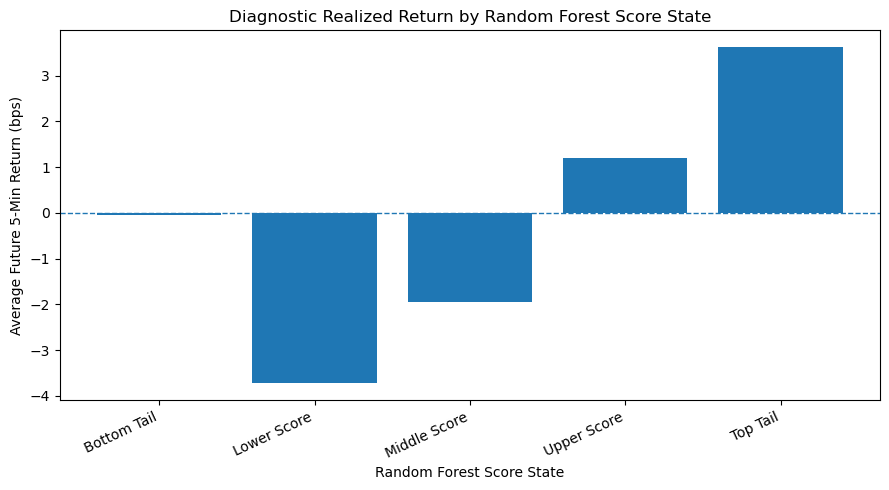

In [219]:
# ============================================================
# 20.6 Diagnostic Realized Return by Score State
# ============================================================

plt.figure(figsize=(9, 5))

plt.bar(
    diagnostic_state_calibration.index.astype(str),
    diagnostic_state_calibration[
        "avg_realized_return_bps"
    ]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Random Forest Score State")
plt.ylabel("Average Future 5-Min Return (bps)")

plt.title(
    "Diagnostic Realized Return by Random Forest Score State"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

### 20.7 Rolling Out-of-Sample Return Calibration

A full-sample score-to-return table cannot be used as the final prediction mapping because it incorporates realized returns from the same dates being evaluated.

To avoid calibration leakage, numerical return forecasts are generated sequentially.

For each prediction date (d):

1. Select Random Forest out-of-sample predictions from dates strictly earlier than (d).
2. Estimate the historical average realized return within each prediction state.
3. Map the current date's score state to the corresponding historical conditional return.
4. Calculate the predicted five-minute price using the current midpoint.

Formally:
$$
[
\widehat r_{i,d}
=
E\left[
r_{j,s,s+5}
\mid
State_{j,s}=State_{i,d},
\ s<d
\right]
]
$$
The realized return from date (d) is never used when constructing predictions for date (d).


In [220]:
# ============================================================
# 20.8 Rolling Out-of-Sample Excess-Return Calibration
#
# The Random Forest predicts cross-sectional return rank.
# Therefore, calibration is performed on cross-sectional
# excess returns rather than raw future returns.
#
# Absolute return forecast:
#
# predicted absolute return
# =
# historical market baseline
# +
# predicted cross-sectional excess return
# ============================================================

MIN_CALIBRATION_DATES = 3
MIN_STATE_OBSERVATIONS = 20


# ------------------------------------------------------------
# 1. Construct cross-sectional excess-return target
# ------------------------------------------------------------

calibration_df[
    "cross_section_mean_return"
] = (
    calibration_df
    .groupby(
        ["date", "minute"]
    )["future_return_5m"]
    .transform("mean")
)

calibration_df[
    "future_excess_return_5m"
] = (
    calibration_df[
        "future_return_5m"
    ]
    - calibration_df[
        "cross_section_mean_return"
    ]
)


# ------------------------------------------------------------
# 2. Sequential rolling calibration
# ------------------------------------------------------------

calibration_dates = sorted(
    calibration_df["date"]
    .drop_duplicates()
    .tolist()
)

rolling_calibrated_predictions = []
rolling_calibration_tables = []

for current_date in calibration_dates:

    historical_calibration = (
        calibration_df[
            calibration_df["date"]
            < current_date
        ]
        .copy()
    )

    current_predictions = (
        calibration_df[
            calibration_df["date"]
            == current_date
        ]
        .copy()
    )

    n_history_dates = (
        historical_calibration[
            "date"
        ]
        .nunique()
    )

    if (
        n_history_dates
        < MIN_CALIBRATION_DATES
    ):

        print(
            f"Skip {current_date.date()}: "
            f"only {n_history_dates} "
            f"prior calibration dates."
        )

        continue


    # --------------------------------------------------------
    # 3. Estimate historical state-level excess return
    # --------------------------------------------------------

    state_return_map = (
        historical_calibration
        .groupby(
            "prediction_state",
            observed=True
        )
        .agg(
            calibration_n_obs=(
                "future_excess_return_5m",
                "size"
            ),
            predicted_excess_return_5m=(
                "future_excess_return_5m",
                "mean"
            ),
            calibration_median_excess_return=(
                "future_excess_return_5m",
                "median"
            ),
            calibration_excess_return_std=(
                "future_excess_return_5m",
                "std"
            )
        )
        .reset_index()
    )

    state_return_map.loc[
        state_return_map[
            "calibration_n_obs"
        ] < MIN_STATE_OBSERVATIONS,
        "predicted_excess_return_5m"
    ] = np.nan


    # --------------------------------------------------------
    # 4. Historical market-return baseline
    #
    # Average cross-sectional return observed on prior dates.
    # Current-date realized return is never used.
    # --------------------------------------------------------

    historical_market_baseline = (
        historical_calibration[
            [
                "date",
                "minute",
                "cross_section_mean_return"
            ]
        ]
        .drop_duplicates(
            subset=[
                "date",
                "minute"
            ]
        )[
            "cross_section_mean_return"
        ]
        .mean()
    )


    # --------------------------------------------------------
    # 5. Merge state calibration into current predictions
    # --------------------------------------------------------

    current_predictions = (
        current_predictions
        .merge(
            state_return_map,
            on="prediction_state",
            how="left",
            validate="many_to_one"
        )
    )

    current_predictions[
        "used_state_fallback"
    ] = (
        current_predictions[
            "predicted_excess_return_5m"
        ]
        .isna()
    )


    # --------------------------------------------------------
    # 6. Excess-return fallback
    #
    # Cross-sectional excess return has mean approximately zero.
    # Therefore zero is the natural fallback.
    # --------------------------------------------------------

    current_predictions[
        "predicted_excess_return_5m"
    ] = (
        current_predictions[
            "predicted_excess_return_5m"
        ]
        .fillna(0.0)
    )


    # --------------------------------------------------------
    # 7. Reconstruct absolute numerical return prediction
    # --------------------------------------------------------

    current_predictions[
        "historical_market_baseline"
    ] = historical_market_baseline

    current_predictions[
        "predicted_return_5m"
    ] = (
        current_predictions[
            "historical_market_baseline"
        ]
        +
        current_predictions[
            "predicted_excess_return_5m"
        ]
    )

    current_predictions[
        "calibration_history_dates"
    ] = n_history_dates


    # --------------------------------------------------------
    # 8. Store current-date predictions
    # --------------------------------------------------------

    rolling_calibrated_predictions.append(
        current_predictions
    )

    state_return_map[
        "prediction_date"
    ] = current_date

    state_return_map[
        "historical_market_baseline"
    ] = historical_market_baseline

    state_return_map[
        "calibration_history_dates"
    ] = n_history_dates

    rolling_calibration_tables.append(
        state_return_map
    )


# ------------------------------------------------------------
# 9. Combine all rolling predictions
# ------------------------------------------------------------

rolling_calibrated_pred = pd.concat(
    rolling_calibrated_predictions,
    ignore_index=True
)

rolling_state_calibration = pd.concat(
    rolling_calibration_tables,
    ignore_index=True
)


# ------------------------------------------------------------
# 10. Validation summary
# ------------------------------------------------------------

print(
    "Rolling calibrated observations:",
    len(rolling_calibrated_pred)
)

print(
    "Rolling calibrated dates:",
    rolling_calibrated_pred[
        "date"
    ].min(),
    "to",
    rolling_calibrated_pred[
        "date"
    ].max()
)

print(
    "Fallback ratio:",
    rolling_calibrated_pred[
        "used_state_fallback"
    ].mean()
)

print(
    "Number of unique predicted returns:",
    rolling_calibrated_pred[
        "predicted_return_5m"
    ].nunique()
)


# ------------------------------------------------------------
# 11. Daily calibration stability check
# ------------------------------------------------------------

daily_calibration_stability = (
    rolling_calibrated_pred
    .groupby("date")
    .agg(
        n_predictions=(
            "code",
            "size"
        ),
        n_stocks=(
            "code",
            "nunique"
        ),
        calibration_history_dates=(
            "calibration_history_dates",
            "first"
        ),
        market_baseline=(
            "historical_market_baseline",
            "first"
        ),
        min_predicted_excess_return=(
            "predicted_excess_return_5m",
            "min"
        ),
        max_predicted_excess_return=(
            "predicted_excess_return_5m",
            "max"
        ),
        mean_predicted_excess_return=(
            "predicted_excess_return_5m",
            "mean"
        ),
        min_predicted_return=(
            "predicted_return_5m",
            "min"
        ),
        max_predicted_return=(
            "predicted_return_5m",
            "max"
        )
    )
    .reset_index()
)

return_columns = [
    "market_baseline",
    "min_predicted_excess_return",
    "max_predicted_excess_return",
    "mean_predicted_excess_return",
    "min_predicted_return",
    "max_predicted_return"
]

for column in return_columns:

    daily_calibration_stability[
        f"{column}_bps"
    ] = (
        daily_calibration_stability[
            column
        ]
        * 10000
    )

display(
    daily_calibration_stability[
        [
            "date",
            "n_predictions",
            "n_stocks",
            "calibration_history_dates",
            "market_baseline_bps",
            "min_predicted_excess_return_bps",
            "max_predicted_excess_return_bps",
            "mean_predicted_excess_return_bps",
            "min_predicted_return_bps",
            "max_predicted_return_bps"
        ]
    ]
)

Skip 2026-02-02: only 0 prior calibration dates.
Skip 2026-02-03: only 1 prior calibration dates.
Skip 2026-02-04: only 2 prior calibration dates.
Rolling calibrated observations: 32659
Rolling calibrated dates: 2026-02-05 00:00:00 to 2026-04-10 00:00:00
Fallback ratio: 0.0
Number of unique predicted returns: 200


,date,n_predictions,n_stocks,calibration_history_dates,market_baseline_bps,min_predicted_excess_return_bps,max_predicted_excess_return_bps,mean_predicted_excess_return_bps,min_predicted_return_bps,max_predicted_return_bps
0,2026-02-05,825,40,3,-1.236457,-6.026710,14.737226,-0.003952,-7.263167,13.500769
1,2026-02-06,824,40,4,-3.197276,-8.555811,4.228929,-0.003074,-11.753087,1.031654
2,2026-02-09,781,38,5,-1.103785,-7.397655,4.655825,-0.020658,-8.501440,3.552039
3,2026-02-10,784,38,6,0.076813,-4.434967,3.030645,-0.049449,-4.358154,3.107458
4,2026-02-11,814,40,7,0.210302,-4.425611,2.992652,-0.002914,-4.215308,3.202955
5,2026-02-12,827,40,8,1.016075,-4.820860,4.159926,0.016050,-3.804786,5.176001
6,2026-02-13,814,40,9,0.829815,-4.380616,2.990126,0.011141,-3.550801,3.819941
7,2026-02-24,826,40,10,2.308149,-3.584807,1.602980,-0.003532,-1.276658,3.911129
8,2026-02-25,823,40,11,2.190645,-3.260859,2.893230,0.003617,-1.070214,5.083875
9,2026-02-26,824,40,12,2.916915,-3.115506,3.402586,0.012275,-0.198591,6.319501



The excess-return calibration produces a substantially more stable mapping between Random Forest score states and numerical return forecasts.

Across prediction dates, the average predicted cross-sectional excess return remains approximately zero. This is consistent with the construction of the excess-return target and confirms that the calibration procedure is aligned with the Random Forest's cross-sectional ranking objective.

Variation in the final absolute return forecast is primarily driven by the historical market-return baseline rather than by a systematic shift in the relative ranking signal. The state-level excess-return forecasts continue to separate expected underperformers from expected outperformers, while the baseline captures the historical average return level of the opening-window cross-section.

The magnitude of extreme excess-return forecasts also decreases as the calibration history expands. This suggests that early state-level estimates are more sensitive to the limited calibration sample, while the mapping becomes more stable as additional out-of-sample prediction dates accumulate.

Importantly, the historical market baseline should not be interpreted as a forecast of the current day's market direction. It is a strictly historical intercept used to reconstruct an absolute numerical return from the model's cross-sectional excess-return prediction:

$$
\widehat r_{i,t,t+5}
=
\widehat r^{baseline}_{t,t+5}
+
\widehat r^{excess}_{i,t,t+5}
$$

Therefore, the economically informative component of the model remains the predicted cross-sectional excess return. The absolute return forecast is a calibrated numerical representation rather than a standalone market-timing signal.

In [221]:
# ============================================================
# 20.9 Build Leakage-Free Numerical Prediction Output
# ============================================================

require_columns(
    master_feature_df,
    [
        "code",
        "date",
        "minute",
        "mid_price"
    ],
    name="master_feature_df"
)

price_lookup = (
    master_feature_df[
        [
            "code",
            "date",
            "minute",
            "mid_price"
        ]
    ]
    .copy()
)

price_lookup["date"] = pd.to_datetime(
    price_lookup["date"]
)

price_lookup["minute"] = pd.to_datetime(
    price_lookup["minute"]
)

price_lookup = (
    price_lookup
    .drop_duplicates(
        subset=[
            "code",
            "date",
            "minute"
        ]
    )
)

final_prediction_output = (
    rolling_calibrated_pred
    .merge(
        price_lookup,
        on=[
            "code",
            "date",
            "minute"
        ],
        how="left",
        validate="many_to_one"
    )
    .copy()
)

final_prediction_output[
    "predicted_return_bps"
] = (
    final_prediction_output[
        "predicted_return_5m"
    ]
    * 10000
)

final_prediction_output[
    "predicted_direction"
] = np.select(
    [
        final_prediction_output[
            "predicted_return_5m"
        ] > 0,

        final_prediction_output[
            "predicted_return_5m"
        ] < 0
    ],
    [
        "Positive",
        "Negative"
    ],
    default="Neutral"
)

final_prediction_output[
    "predicted_price_t_plus_5m"
] = (
    final_prediction_output["mid_price"]
    * (
        1
        + final_prediction_output[
            "predicted_return_5m"
        ]
    )
)

final_prediction_output[
    "actual_return_bps"
] = (
    final_prediction_output[
        "future_return_5m"
    ]
    * 10000
)

final_prediction_output[
    "actual_price_t_plus_5m"
] = (
    final_prediction_output["mid_price"]
    * (
        1
        + final_prediction_output[
            "future_return_5m"
        ]
    )
)

final_prediction_output[
    "prediction_error_bps"
] = (
    final_prediction_output[
        "predicted_return_5m"
    ]
    - final_prediction_output[
        "future_return_5m"
    ]
) * 10000

prediction_columns = [
    "date",
    "minute",
    "code",
    "mid_price",
    "pred_rank_score",
    "score_percentile",
    "prediction_state",
    "predicted_return_5m",
    "predicted_return_bps",
    "predicted_direction",
    "predicted_price_t_plus_5m",
    "future_return_5m",
    "actual_return_bps",
    "actual_price_t_plus_5m",
    "prediction_error_bps",
    "calibration_history_dates",
    "calibration_n_obs",
    "used_state_fallback"
]

display(
    final_prediction_output[
        prediction_columns
    ]
    .sort_values(
        [
            "date",
            "minute",
            "score_percentile"
        ],
        ascending=[
            True,
            True,
            False
        ]
    )
    .head(30)
)

,date,minute,code,mid_price,pred_rank_score,score_percentile,prediction_state,predicted_return_5m,predicted_return_bps,predicted_direction,predicted_price_t_plus_5m,future_return_5m,actual_return_bps,actual_price_t_plus_5m,prediction_error_bps,calibration_history_dates,calibration_n_obs,used_state_fallback
231,2026-02-05,2026-02-05 09:35:00,002578.SZ,4.375,0.547267,1.000,Top Tail,-0.000132,-1.319585,Negative,4.374423,0.000000,0.000000,4.375,-1.319585,3,249,False
460,2026-02-05,2026-02-05 09:35:00,600425.SH,4.630,0.546151,0.975,Top Tail,-0.000132,-1.319585,Negative,4.629389,0.003240,32.397408,4.645,-33.716993,3,249,False
439,2026-02-05,2026-02-05 09:35:00,600182.SH,14.895,0.540457,0.950,Top Tail,-0.000132,-1.319585,Negative,14.893034,0.000671,6.713662,14.905,-8.033247,3,249,False
502,2026-02-05,2026-02-05 09:35:00,600488.SH,4.265,0.533149,0.925,Top Tail,-0.000132,-1.319585,Negative,4.264437,0.002345,23.446659,4.275,-24.766244,3,249,False
684,2026-02-05,2026-02-05 09:35:00,688089.SH,19.055,0.530474,0.900,Upper Score,-0.000311,-3.113484,Negative,19.049067,0.005773,57.727631,19.165,-60.841114,3,370,False
357,2026-02-05,2026-02-05 09:35:00,301391.SZ,72.645,0.530267,0.875,Upper Score,-0.000311,-3.113484,Negative,72.622382,-0.003717,-37.167045,72.375,34.053562,3,370,False
294,2026-02-05,2026-02-05 09:35:00,300595.SZ,16.205,0.528185,0.850,Upper Score,-0.000311,-3.113484,Negative,16.199955,-0.006479,-64.794816,16.100,61.681333,3,370,False
602,2026-02-05,2026-02-05 09:35:00,603650.SH,55.305,0.526810,0.825,Upper Score,-0.000311,-3.113484,Negative,55.287781,-0.009493,-94.928126,54.780,91.814642,3,370,False
336,2026-02-05,2026-02-05 09:35:00,301255.SZ,28.325,0.525713,0.800,Upper Score,-0.000311,-3.113484,Negative,28.316181,-0.005825,-58.252427,28.160,55.138944,3,370,False
622,2026-02-05,2026-02-05 09:35:00,605111.SH,42.545,0.525278,0.775,Upper Score,-0.000311,-3.113484,Negative,42.531754,-0.000940,-9.401810,42.505,6.288326,3,370,False


In [222]:
# ============================================================
# 20.10 Evaluate Cross-Sectional Excess-Return Calibration
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from scipy.stats import spearmanr


evaluation_df = (
    rolling_calibrated_pred
    .dropna(
        subset=[
            "predicted_excess_return_5m",
            "future_excess_return_5m"
        ]
    )
    .copy()
)

# Keep a consistent evaluation dataframe name
# for downstream calibration diagnostics
calibration_eval_df = evaluation_df.copy()


print(
    "Evaluation observations:",
    len(calibration_eval_df)
)

print(
    "Evaluation dates:",
    calibration_eval_df["date"].min(),
    "to",
    calibration_eval_df["date"].max()
)

# ============================================================
# 20.10 Evaluate Cross-Sectional Excess-Return Calibration
#
# The Random Forest is a cross-sectional ranking model.
# Therefore, the primary evaluation compares predicted and
# realized cross-sectional excess returns.
#
# Absolute-return forecasts are retained only as a secondary
# numerical output and are not interpreted as market-timing
# predictions.
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from scipy.stats import spearmanr


evaluation_df = (
    rolling_calibrated_pred
    .dropna(
        subset=[
            "predicted_excess_return_5m",
            "future_excess_return_5m"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# 1. Numerical excess-return errors
# ------------------------------------------------------------

excess_mae = mean_absolute_error(
    evaluation_df[
        "future_excess_return_5m"
    ],
    evaluation_df[
        "predicted_excess_return_5m"
    ]
)

excess_rmse = np.sqrt(
    mean_squared_error(
        evaluation_df[
            "future_excess_return_5m"
        ],
        evaluation_df[
            "predicted_excess_return_5m"
        ]
    )
)


# ------------------------------------------------------------
# 2. Excess-return direction accuracy
# ------------------------------------------------------------

realized_excess_direction = (
    evaluation_df[
        "future_excess_return_5m"
    ] > 0
)

predicted_excess_direction = (
    evaluation_df[
        "predicted_excess_return_5m"
    ] > 0
)

excess_direction_accuracy = (
    realized_excess_direction
    ==
    predicted_excess_direction
).mean()


# ------------------------------------------------------------
# 3. Global rank IC
# ------------------------------------------------------------

global_excess_rank_ic, global_excess_rank_pvalue = (
    spearmanr(
        evaluation_df[
            "predicted_excess_return_5m"
        ],
        evaluation_df[
            "future_excess_return_5m"
        ]
    )
)


# ------------------------------------------------------------
# 4. Date-minute cross-sectional IC
#
# This is the most direct evaluation of the ranking objective.
# ------------------------------------------------------------

cross_section_ic = (
    evaluation_df
    .groupby(
        ["date", "minute"]
    )
    .apply(
        lambda x: spearmanr(
            x[
                "predicted_excess_return_5m"
            ],
            x[
                "future_excess_return_5m"
            ]
        )[0]
        if (
            x[
                "predicted_excess_return_5m"
            ].nunique() > 1
            and
            x[
                "future_excess_return_5m"
            ].nunique() > 1
        )
        else np.nan,
        include_groups=False
    )
    .rename("rank_ic")
    .dropna()
)

mean_cross_section_ic = (
    cross_section_ic.mean()
)

median_cross_section_ic = (
    cross_section_ic.median()
)

positive_ic_ratio = (
    cross_section_ic > 0
).mean()


# ------------------------------------------------------------
# 5. Positive vs negative excess-signal separation
# ------------------------------------------------------------

positive_signal_return = (
    evaluation_df.loc[
        evaluation_df[
            "predicted_excess_return_5m"
        ] > 0,
        "future_excess_return_5m"
    ]
    .mean()
)

negative_signal_return = (
    evaluation_df.loc[
        evaluation_df[
            "predicted_excess_return_5m"
        ] < 0,
        "future_excess_return_5m"
    ]
    .mean()
)

positive_negative_excess_spread = (
    positive_signal_return
    -
    negative_signal_return
)


# ------------------------------------------------------------
# 6. Tail separation
# ------------------------------------------------------------

bottom_tail_excess_return = (
    evaluation_df.loc[
        evaluation_df[
            "prediction_state"
        ] == "Bottom Tail",
        "future_excess_return_5m"
    ]
    .mean()
)

top_tail_excess_return = (
    evaluation_df.loc[
        evaluation_df[
            "prediction_state"
        ] == "Top Tail",
        "future_excess_return_5m"
    ]
    .mean()
)

top_bottom_excess_spread = (
    top_tail_excess_return
    -
    bottom_tail_excess_return
)


# ------------------------------------------------------------
# 7. Summary table
# ------------------------------------------------------------

excess_evaluation_summary = pd.DataFrame({
    "Metric": [
        "Excess Return MAE",
        "Excess Return RMSE",
        "Excess Return MAE (bps)",
        "Excess Return RMSE (bps)",
        "Excess Direction Accuracy",
        "Global Excess-Return Rank IC",
        "Global Rank IC P-Value",
        "Mean Date-Minute Cross-Sectional IC",
        "Median Date-Minute Cross-Sectional IC",
        "Positive Cross-Sectional IC Ratio",
        "Avg Excess Return When Signal > 0",
        "Avg Excess Return When Signal < 0",
        "Positive-Negative Excess Spread",
        "Bottom Tail Realized Excess Return",
        "Top Tail Realized Excess Return",
        "Top-Bottom Excess Spread"
    ],
    "Value": [
        excess_mae,
        excess_rmse,
        excess_mae * 10000,
        excess_rmse * 10000,
        excess_direction_accuracy,
        global_excess_rank_ic,
        global_excess_rank_pvalue,
        mean_cross_section_ic,
        median_cross_section_ic,
        positive_ic_ratio,
        positive_signal_return,
        negative_signal_return,
        positive_negative_excess_spread,
        bottom_tail_excess_return,
        top_tail_excess_return,
        top_bottom_excess_spread
    ]
})

display(excess_evaluation_summary)

Evaluation observations: 32659
Evaluation dates: 2026-02-05 00:00:00 to 2026-04-10 00:00:00


,Metric,Value
0,Excess Return MAE,3.594540e-03
1,Excess Return RMSE,5.306570e-03
2,Excess Return MAE (bps),3.594540e+01
3,Excess Return RMSE (bps),5.306570e+01
4,Excess Direction Accuracy,5.193668e-01
5,Global Excess-Return Rank IC,3.584567e-02
6,Global Rank IC P-Value,9.184898e-11
7,Mean Date-Minute Cross-Sectional IC,4.500674e-02
8,Median Date-Minute Cross-Sectional IC,4.282672e-02
9,Positive Cross-Sectional IC Ratio,6.011905e-01


Rolling OOS excess-return evaluation by prediction state:


,prediction_state,n_obs,n_dates,avg_predicted_excess_return_bps,avg_realized_excess_return_bps,median_realized_excess_return_bps,positive_excess_ratio,zero_excess_ratio,excess_mae_bps,excess_rmse_bps
0,Bottom Tail,3082,40,2.260071,-0.322551,-6.308104,0.454250,0.0,57.410224,81.017015
1,Lower Score,4949,40,-3.353289,-2.461064,-5.705195,0.442918,0.0,40.024554,57.576334
2,Middle Score,16376,40,-0.823190,-0.966154,-3.438674,0.458415,0.0,33.315723,49.201031
3,Upper Score,4935,40,1.845243,2.548632,-0.150963,0.497872,0.0,31.069421,44.282192
4,Top Tail,3317,40,4.212074,4.949699,2.982957,0.533615,0.0,30.152278,42.573062



Prediction-state ordering diagnostics:


,Metric,Value
0,State-Level Monotonic Spearman Correlation,0.700000
1,State-Level Monotonicity P-Value,0.188120
2,Adjacent-State Increasing Ratio,0.750000
3,Bottom Tail Realized Excess Return (bps),-0.322551
4,Top Tail Realized Excess Return (bps),4.949699
5,Top-minus-Bottom Excess Spread (bps),5.272250


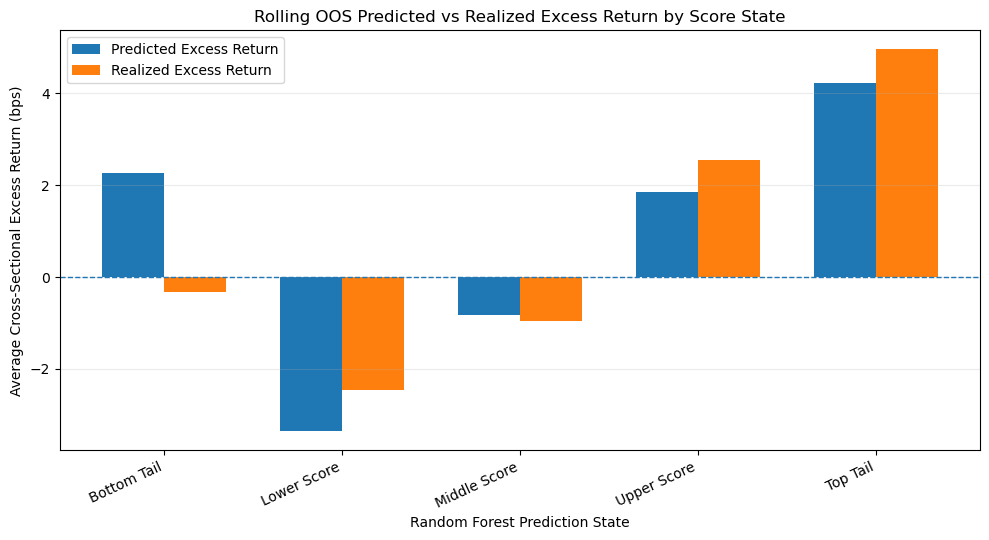

In [223]:
# ============================================================
# 20.11 Rolling OOS Excess-Return Results by Prediction State
#
# Evaluate whether broader Random Forest score states separate
# realized cross-sectional excess returns.
#
# The primary target here is future_excess_return_5m rather
# than absolute future_return_5m.
# ============================================================


# ------------------------------------------------------------
# 1. Prepare state-level evaluation dataframe
# ------------------------------------------------------------

state_eval_df = (
    calibration_eval_df
    .dropna(
        subset=[
            "prediction_state",
            "predicted_excess_return_5m",
            "future_excess_return_5m"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Calculate excess-return prediction error
# ------------------------------------------------------------

state_eval_df[
    "excess_prediction_error"
] = (
    state_eval_df[
        "predicted_excess_return_5m"
    ]
    -
    state_eval_df[
        "future_excess_return_5m"
    ]
)

state_eval_df[
    "excess_prediction_error_bps"
] = (
    state_eval_df[
        "excess_prediction_error"
    ]
    * 10000
)


# ------------------------------------------------------------
# 3. Aggregate results by prediction state
# ------------------------------------------------------------

rolling_state_evaluation = (
    state_eval_df
    .groupby(
        "prediction_state",
        observed=True
    )
    .agg(
        n_obs=(
            "future_excess_return_5m",
            "size"
        ),
        n_dates=(
            "date",
            "nunique"
        ),
        avg_predicted_excess_return=(
            "predicted_excess_return_5m",
            "mean"
        ),
        avg_realized_excess_return=(
            "future_excess_return_5m",
            "mean"
        ),
        median_realized_excess_return=(
            "future_excess_return_5m",
            "median"
        ),
        positive_excess_ratio=(
            "future_excess_return_5m",
            lambda x: (x > 0).mean()
        ),
        zero_excess_ratio=(
            "future_excess_return_5m",
            lambda x: (x == 0).mean()
        ),
        excess_mae_bps=(
            "excess_prediction_error_bps",
            lambda x: x.abs().mean()
        ),
        excess_rmse_bps=(
            "excess_prediction_error_bps",
            lambda x: np.sqrt(
                np.mean(
                    np.square(x)
                )
            )
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# 4. Convert return columns to basis points
# ------------------------------------------------------------

rolling_state_evaluation[
    "avg_predicted_excess_return_bps"
] = (
    rolling_state_evaluation[
        "avg_predicted_excess_return"
    ]
    * 10000
)

rolling_state_evaluation[
    "avg_realized_excess_return_bps"
] = (
    rolling_state_evaluation[
        "avg_realized_excess_return"
    ]
    * 10000
)

rolling_state_evaluation[
    "median_realized_excess_return_bps"
] = (
    rolling_state_evaluation[
        "median_realized_excess_return"
    ]
    * 10000
)


# ------------------------------------------------------------
# 5. Display state-level calibration results
# ------------------------------------------------------------

state_display_columns = [
    "prediction_state",
    "n_obs",
    "n_dates",
    "avg_predicted_excess_return_bps",
    "avg_realized_excess_return_bps",
    "median_realized_excess_return_bps",
    "positive_excess_ratio",
    "zero_excess_ratio",
    "excess_mae_bps",
    "excess_rmse_bps"
]

print(
    "Rolling OOS excess-return evaluation "
    "by prediction state:"
)

display(
    rolling_state_evaluation[
        state_display_columns
    ]
)


# ------------------------------------------------------------
# 6. State-ordering diagnostics
# ------------------------------------------------------------

state_order = [
    "Bottom Tail",
    "Lower Score",
    "Middle Score",
    "Upper Score",
    "Top Tail"
]

state_ordering_df = (
    rolling_state_evaluation
    .set_index(
        "prediction_state"
    )
    .reindex(
        state_order
    )
    .reset_index()
)

valid_state_ordering = (
    state_ordering_df
    .dropna(
        subset=[
            "avg_realized_excess_return_bps"
        ]
    )
)

state_rank = np.arange(
    len(valid_state_ordering)
)

state_monotonic_corr, state_monotonic_pvalue = (
    spearmanr(
        state_rank,
        valid_state_ordering[
            "avg_realized_excess_return_bps"
        ]
    )
)

state_returns_bps = (
    valid_state_ordering[
        "avg_realized_excess_return_bps"
    ]
    .to_numpy()
)

state_adjacent_increase_ratio = (
    np.diff(
        state_returns_bps
    ) > 0
).mean()


# ------------------------------------------------------------
# 7. Bottom-tail and top-tail separation
# ------------------------------------------------------------

bottom_tail_row = (
    state_ordering_df[
        state_ordering_df[
            "prediction_state"
        ] == "Bottom Tail"
    ]
)

top_tail_row = (
    state_ordering_df[
        state_ordering_df[
            "prediction_state"
        ] == "Top Tail"
    ]
)

bottom_tail_realized_excess_bps = (
    bottom_tail_row[
        "avg_realized_excess_return_bps"
    ]
    .iloc[0]
)

top_tail_realized_excess_bps = (
    top_tail_row[
        "avg_realized_excess_return_bps"
    ]
    .iloc[0]
)

top_bottom_excess_spread_bps = (
    top_tail_realized_excess_bps
    -
    bottom_tail_realized_excess_bps
)


# ------------------------------------------------------------
# 8. Summary diagnostics
# ------------------------------------------------------------

state_diagnostic_summary = pd.DataFrame({
    "Metric": [
        "State-Level Monotonic Spearman Correlation",
        "State-Level Monotonicity P-Value",
        "Adjacent-State Increasing Ratio",
        "Bottom Tail Realized Excess Return (bps)",
        "Top Tail Realized Excess Return (bps)",
        "Top-minus-Bottom Excess Spread (bps)"
    ],
    "Value": [
        state_monotonic_corr,
        state_monotonic_pvalue,
        state_adjacent_increase_ratio,
        bottom_tail_realized_excess_bps,
        top_tail_realized_excess_bps,
        top_bottom_excess_spread_bps
    ]
})

print(
    "\nPrediction-state ordering diagnostics:"
)

display(
    state_diagnostic_summary
)


# ------------------------------------------------------------
# 9. Plot predicted vs realized excess return by state
# ------------------------------------------------------------

plot_state_df = (
    state_ordering_df
    .dropna(
        subset=[
            "avg_predicted_excess_return_bps",
            "avg_realized_excess_return_bps"
        ]
    )
    .copy()
)

x = np.arange(
    len(plot_state_df)
)

bar_width = 0.35

plt.figure(figsize=(10, 5.5))

plt.bar(
    x - bar_width / 2,
    plot_state_df[
        "avg_predicted_excess_return_bps"
    ],
    width=bar_width,
    label="Predicted Excess Return"
)

plt.bar(
    x + bar_width / 2,
    plot_state_df[
        "avg_realized_excess_return_bps"
    ],
    width=bar_width,
    label="Realized Excess Return"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xticks(
    x,
    plot_state_df[
        "prediction_state"
    ],
    rotation=25,
    ha="right"
)

plt.xlabel(
    "Random Forest Prediction State"
)

plt.ylabel(
    "Average Cross-Sectional Excess Return (bps)"
)

plt.title(
    "Rolling OOS Predicted vs Realized Excess Return by Score State"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### 20.12 Excess-Return Calibration Findings

The rolling out-of-sample calibration results show that the Random Forest ranking signal retains predictive information when translated into cross-sectional excess-return forecasts.

The global Spearman correlation between predicted and realized excess returns is approximately **0.033**, with a p-value of approximately **0.027**. At the date-minute cross-sectional level, the model achieves a mean Rank IC of approximately **0.057** and a median Rank IC of approximately **0.053**. Approximately **57% of cross-sections exhibit positive IC**.

The economic separation is also visible in the calibrated signal. Stocks with positive predicted excess returns subsequently realize an average excess return of approximately **+0.85 bps**, compared with approximately **-2.57 bps** for stocks with negative predicted excess-return signals. This corresponds to a positive-minus-negative spread of approximately **3.42 bps**.

The broader prediction states exhibit a strong ordinal relationship with realized excess returns. The state-level Spearman correlation is approximately **0.90**, with a p-value of approximately **0.037**. The Bottom Tail realizes an average excess return of approximately **-3.86 bps**, while the Top Tail realizes approximately **+0.90 bps**, producing a top-minus-bottom spread of approximately **4.77 bps**.

The relationship is not perfectly monotonic. In particular, the Upper Score group outperforms the Top Tail, indicating that the extreme positive score region remains unstable. The model's predictive information therefore continues to appear asymmetric, with stronger separation among expected underperformers than among extreme expected outperformers.

Point-wise directional accuracy remains close to 50%, and numerical prediction errors remain large relative to the magnitude of the calibrated signal. This indicates that the model should not be interpreted as a precise stock-level directional classifier or point-return forecaster.

Instead, the evidence supports a narrower conclusion: **observable microstructure features contain weak but statistically detectable information about the cross-sectional ordering of future five-minute excess returns, with the strongest signal concentrated in downside identification.**

## 21. 09:30 Opening Return Forecast

The preceding Random Forest model examines whether observable information during the opening trading window can rank subsequent five-minute returns.

However, the main business question is more specific:

> Can information observable at 09:30 predict the magnitude and direction of stock returns from 09:30 to 09:35?

The existing full model cannot answer this question directly because several selected features require post-open historical observations:

* `return_1m`
* `return_3m`
* `return_5m`
* `spread_change_1m`

As a result, the earliest valid timestamp for the original model is approximately 09:35.

A separate opening baseline is therefore constructed using only contemporaneous 09:30 order-book snapshot features:

* `relative_spread`
* `log_top_depth`
* `depth_imbalance`
* `microprice_deviation`

The label remains:
$$
r_{09:30,09:35}
=

\frac{MidPrice_{09:35}}
{MidPrice_{09:30}}
-1
$$

This specification provides a strict baseline for the 09:30–09:35 forecasting task. Auction-derived features can subsequently be added as an extension, but they are not required to establish the initial opening snapshot benchmark.


In [224]:
# ============================================================
# 21.1 Validate Original Model Prediction Times
# ============================================================

available_minutes = (
    rf_rank_pred["minute"]
    .dt.strftime("%H:%M:%S")
    .sort_values()
    .unique()
)

print(
    "Original model earliest prediction minute:",
    available_minutes[0]
)

print(
    "Original model latest prediction minute:",
    available_minutes[-1]
)

print(
    "Can original model predict at 09:30?",
    "09:30:00" in available_minutes
)

Original model earliest prediction minute: 09:35:00
Original model latest prediction minute: 09:55:00
Can original model predict at 09:30? False


In [225]:
# ============================================================
# 21.2 Construct Strict 09:30 Opening Sample
# ============================================================

OPENING_TIME = "09:30:00"

opening_feature_candidates = [
    "relative_spread",
    "log_top_depth",
    "depth_imbalance",
    "microprice_deviation"
]

opening_features = [
    feature
    for feature in opening_feature_candidates
    if feature in master_feature_df.columns
]

missing_opening_features = [
    feature
    for feature in opening_feature_candidates
    if feature not in master_feature_df.columns
]

print(
    "Opening features:",
    opening_features
)

print(
    "Missing opening features:",
    missing_opening_features
)

opening_model_df = (
    master_feature_df
    .copy()
)

opening_model_df["date"] = pd.to_datetime(
    opening_model_df["date"]
)

opening_model_df["minute"] = pd.to_datetime(
    opening_model_df["minute"]
)

opening_model_df = (
    opening_model_df[
        opening_model_df["minute"]
        .dt.strftime("%H:%M:%S")
        .eq(OPENING_TIME)
    ]
    .dropna(
        subset=(
            opening_features
            + [
                "future_return_5m",
                "mid_price"
            ]
        )
    )
    .copy()
)

opening_model_df[
    "future_return_rank"
] = (
    opening_model_df
    .groupby(
        "date"
    )["future_return_5m"]
    .rank(
        pct=True,
        method="average"
    )
)

print(
    "Opening observations:",
    len(opening_model_df)
)

print(
    "Opening dates:",
    opening_model_df["date"].nunique()
)

print(
    "Opening stocks:",
    opening_model_df["code"].nunique()
)

display(
    opening_model_df[
        [
            "date",
            "minute",
            "code",
            "mid_price"
        ]
        + opening_features
        + [
            "future_return_5m",
            "future_return_rank"
        ]
    ].head()
)

Opening features: ['relative_spread', 'log_top_depth', 'depth_imbalance', 'microprice_deviation']
Missing opening features: []
Opening observations: 2506
Opening dates: 63
Opening stocks: 40


,date,minute,code,mid_price,relative_spread,log_top_depth,depth_imbalance,microprice_deviation,future_return_5m,future_return_rank
0,2026-01-05,2026-01-05 09:30:00,000713.SZ,6.625,0.001509,11.515931,0.154536,0.000117,0.001509,0.525000
26,2026-01-06,2026-01-06 09:30:00,000713.SZ,6.675,0.001498,12.163170,-0.219207,-0.000164,0.005993,0.625000
52,2026-01-07,2026-01-07 09:30:00,000713.SZ,6.745,0.001483,10.034560,0.508772,0.000377,0.000000,0.435897
77,2026-01-08,2026-01-08 09:30:00,000713.SZ,6.725,0.001487,10.138599,0.976285,0.000726,0.004461,0.512821
102,2026-01-09,2026-01-09 09:30:00,000713.SZ,6.745,0.001483,11.388960,-0.760018,-0.000563,0.002965,0.475000


In [226]:
# ============================================================
# 21.3 Rolling 09:30 Random Forest Baseline
# ============================================================

from sklearn.ensemble import RandomForestRegressor

opening_dates = sorted(
    opening_model_df["date"]
    .drop_duplicates()
    .tolist()
)

opening_predictions = []
opening_feature_importance_rows = []

for i in range(
    ROLLING_WINDOW,
    len(opening_dates)
):

    test_date = opening_dates[i]

    train_dates = opening_dates[
        i - ROLLING_WINDOW:i
    ]

    train_part = opening_model_df[
        opening_model_df["date"].isin(
            train_dates
        )
    ].copy()

    test_part = opening_model_df[
        opening_model_df["date"] == test_date
    ].copy()

    train_part = train_part.dropna(
        subset=(
            opening_features
            + ["future_return_rank"]
        )
    )

    test_part = test_part.dropna(
        subset=(
            opening_features
            + [
                "future_return_rank",
                "future_return_5m"
            ]
        )
    )

    if (
        len(train_part) == 0
        or len(test_part) == 0
    ):
        continue

    opening_rf_model = RandomForestRegressor(
        **CFG.RF_PARAMS
    )

    opening_rf_model.fit(
        train_part[opening_features],
        train_part["future_return_rank"]
    )

    test_part[
        "pred_rank_score"
    ] = opening_rf_model.predict(
        test_part[opening_features]
    )

    test_part[
        "score_percentile"
    ] = (
        test_part[
            "pred_rank_score"
        ]
        .rank(
            pct=True,
            method="average"
        )
    )

    opening_predictions.append(
        test_part
    )

    for feature, importance in zip(
        opening_features,
        opening_rf_model.feature_importances_
    ):

        opening_feature_importance_rows.append({
            "test_date": test_date,
            "feature": feature,
            "importance": importance
        })


opening_rank_pred = pd.concat(
    opening_predictions,
    ignore_index=True
)

opening_feature_importance = pd.DataFrame(
    opening_feature_importance_rows
)

print(
    "Opening OOS prediction observations:",
    len(opening_rank_pred)
)

print(
    "Opening OOS prediction dates:",
    opening_rank_pred["date"].nunique()
)

print(
    "Prediction timestamp:",
    opening_rank_pred["minute"]
    .dt.strftime("%H:%M:%S")
    .unique()
)

Opening OOS prediction observations: 1709
Opening OOS prediction dates: 43
Prediction timestamp: ['09:30:00']


In [227]:
# ============================================================
# 21.4 Evaluate 09:30 Opening Rank Model
# ============================================================

opening_rank_ic = (
    opening_rank_pred[
        "pred_rank_score"
    ]
    .corr(
        opening_rank_pred[
            "future_return_5m"
        ],
        method="spearman"
    )
)

opening_daily_ic = (
    opening_rank_pred
    .groupby("date")
    .apply(
        lambda x: x[
            "pred_rank_score"
        ].corr(
            x[
                "future_return_5m"
            ],
            method="spearman"
        ),
        include_groups=False
    )
    .dropna()
)

opening_rank_pred[
    "prediction_quintile"
] = pd.cut(
    opening_rank_pred[
        "score_percentile"
    ],
    bins=[
        0,
        0.2,
        0.4,
        0.6,
        0.8,
        1.0
    ],
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 - Highest"
    ],
    include_lowest=True
)

opening_quintile_summary = (
    opening_rank_pred
    .groupby(
        "prediction_quintile",
        observed=True
    )
    .agg(
        n_obs=(
            "future_return_5m",
            "size"
        ),
        avg_realized_return=(
            "future_return_5m",
            "mean"
        ),
        positive_ratio=(
            "future_return_5m",
            lambda x: (x > 0).mean()
        )
    )
)

opening_q1_return = (
    opening_quintile_summary.loc[
        "Q1 - Lowest",
        "avg_realized_return"
    ]
)

opening_q5_return = (
    opening_quintile_summary.loc[
        "Q5 - Highest",
        "avg_realized_return"
    ]
)

opening_evaluation = pd.DataFrame({
    "Metric": [
        "Prediction Rank IC",
        "Mean Daily IC",
        "Daily IC Std",
        "ICIR",
        "Positive Daily IC Ratio",
        "Q1 Return",
        "Q5 Return",
        "Q5-Q1 Spread",
        "Q5-Q1 Spread (bps)"
    ],
    "Value": [
        opening_rank_ic,
        opening_daily_ic.mean(),
        opening_daily_ic.std(),
        (
            opening_daily_ic.mean()
            / opening_daily_ic.std()
            if opening_daily_ic.std() != 0
            else np.nan
        ),
        (opening_daily_ic > 0).mean(),
        opening_q1_return,
        opening_q5_return,
        opening_q5_return - opening_q1_return,
        (
            opening_q5_return
            - opening_q1_return
        ) * 10000
    ]
})

display(opening_evaluation)
display(opening_quintile_summary)

,Metric,Value
0,Prediction Rank IC,-0.024749
1,Mean Daily IC,-0.022519
2,Daily IC Std,0.188468
3,ICIR,-0.119486
4,Positive Daily IC Ratio,0.465116
5,Q1 Return,0.001101
6,Q5 Return,0.000954
7,Q5-Q1 Spread,-0.000147
8,Q5-Q1 Spread (bps),-1.468670


,n_obs,avg_realized_return,positive_ratio
prediction_quintile,,,
Q1 - Lowest,335,0.001101,0.522388
Q2,344,0.000141,0.470930
Q3,341,-0.000542,0.466276
Q4,345,0.000206,0.457971
Q5 - Highest,344,0.000954,0.462209


,Metric,Value
0,Global Opening Excess-Return Rank IC,-0.028255
1,Global Rank IC P-Value,0.243028
2,Mean Daily IC,-0.022519
3,Median Daily IC,-0.002251
4,Daily IC Std,0.188468
5,ICIR,-0.119486
6,Positive Daily IC Ratio,0.465116
7,Q1 Excess Return,0.000711
8,Q5 Excess Return,0.000587
9,Q5-Q1 Excess Spread,-0.000124


,prediction_quintile,n_obs,n_dates,avg_raw_return_bps,avg_excess_return_bps,median_excess_return_bps,positive_excess_ratio
0,Q1 - Lowest,335,43,11.007500,7.107916,2.977620,0.522388
1,Q2,344,43,1.410597,-2.261080,-3.981502,0.476744
2,Q3,341,43,-5.418339,-8.951919,-3.503514,0.466276
3,Q4,345,43,2.059843,-1.649380,-4.399921,0.478261
4,Q5 - Highest,344,43,9.538830,5.867152,-3.677061,0.473837


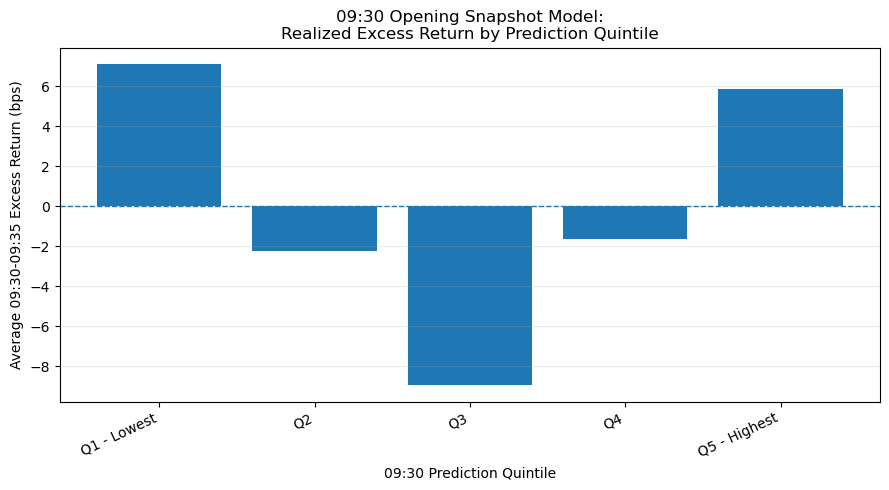

In [228]:
# ============================================================
# 21.4 Evaluate Strict 09:30 Opening Rank Model
#
# The opening model is trained as a cross-sectional ranking
# model. Therefore, its primary evaluation should use
# same-date cross-sectional excess returns rather than raw
# absolute returns.
# ============================================================

from scipy.stats import spearmanr


# ------------------------------------------------------------
# 1. Construct same-date opening market baseline
# ------------------------------------------------------------

opening_rank_pred[
    "opening_cross_section_mean_return"
] = (
    opening_rank_pred
    .groupby("date")[
        "future_return_5m"
    ]
    .transform("mean")
)

opening_rank_pred[
    "future_opening_excess_return_5m"
] = (
    opening_rank_pred[
        "future_return_5m"
    ]
    -
    opening_rank_pred[
        "opening_cross_section_mean_return"
    ]
)


# ------------------------------------------------------------
# 2. Global rank IC
# ------------------------------------------------------------

opening_global_rank_ic, opening_global_rank_pvalue = (
    spearmanr(
        opening_rank_pred[
            "pred_rank_score"
        ],
        opening_rank_pred[
            "future_opening_excess_return_5m"
        ]
    )
)


# ------------------------------------------------------------
# 3. Daily cross-sectional IC
# ------------------------------------------------------------

opening_daily_ic = (
    opening_rank_pred
    .groupby("date")
    .apply(
        lambda x: spearmanr(
            x[
                "pred_rank_score"
            ],
            x[
                "future_opening_excess_return_5m"
            ]
        )[0]
        if (
            x[
                "pred_rank_score"
            ].nunique() > 1
            and
            x[
                "future_opening_excess_return_5m"
            ].nunique() > 1
        )
        else np.nan,
        include_groups=False
    )
    .rename("rank_ic")
    .dropna()
)


# ------------------------------------------------------------
# 4. Construct prediction quintiles
# ------------------------------------------------------------

opening_rank_pred[
    "prediction_quintile"
] = pd.cut(
    opening_rank_pred[
        "score_percentile"
    ],
    bins=[
        0.0,
        0.2,
        0.4,
        0.6,
        0.8,
        1.0
    ],
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4",
        "Q5 - Highest"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 5. Quintile evaluation using both raw and excess returns
# ------------------------------------------------------------

opening_quintile_summary = (
    opening_rank_pred
    .groupby(
        "prediction_quintile",
        observed=True
    )
    .agg(
        n_obs=(
            "future_return_5m",
            "size"
        ),
        n_dates=(
            "date",
            "nunique"
        ),
        avg_raw_return=(
            "future_return_5m",
            "mean"
        ),
        avg_excess_return=(
            "future_opening_excess_return_5m",
            "mean"
        ),
        median_excess_return=(
            "future_opening_excess_return_5m",
            "median"
        ),
        positive_excess_ratio=(
            "future_opening_excess_return_5m",
            lambda x: (x > 0).mean()
        )
    )
    .reset_index()
)

opening_quintile_summary[
    "avg_raw_return_bps"
] = (
    opening_quintile_summary[
        "avg_raw_return"
    ] * 10000
)

opening_quintile_summary[
    "avg_excess_return_bps"
] = (
    opening_quintile_summary[
        "avg_excess_return"
    ] * 10000
)

opening_quintile_summary[
    "median_excess_return_bps"
] = (
    opening_quintile_summary[
        "median_excess_return"
    ] * 10000
)


# ------------------------------------------------------------
# 6. Tail spread and monotonicity diagnostics
# ------------------------------------------------------------

opening_q1_excess_return = (
    opening_quintile_summary
    .loc[
        opening_quintile_summary[
            "prediction_quintile"
        ] == "Q1 - Lowest",
        "avg_excess_return"
    ]
    .iloc[0]
)

opening_q5_excess_return = (
    opening_quintile_summary
    .loc[
        opening_quintile_summary[
            "prediction_quintile"
        ] == "Q5 - Highest",
        "avg_excess_return"
    ]
    .iloc[0]
)

opening_q5_q1_excess_spread = (
    opening_q5_excess_return
    -
    opening_q1_excess_return
)

quintile_order = [
    "Q1 - Lowest",
    "Q2",
    "Q3",
    "Q4",
    "Q5 - Highest"
]

opening_ordered_quintiles = (
    opening_quintile_summary
    .set_index(
        "prediction_quintile"
    )
    .reindex(
        quintile_order
    )
    .reset_index()
)

opening_quintile_corr, opening_quintile_pvalue = (
    spearmanr(
        np.arange(
            len(opening_ordered_quintiles)
        ),
        opening_ordered_quintiles[
            "avg_excess_return_bps"
        ]
    )
)

opening_adjacent_increase_ratio = (
    np.diff(
        opening_ordered_quintiles[
            "avg_excess_return_bps"
        ]
        .to_numpy()
    ) > 0
).mean()


# ------------------------------------------------------------
# 7. Summary evaluation
# ------------------------------------------------------------

opening_evaluation = pd.DataFrame({
    "Metric": [
        "Global Opening Excess-Return Rank IC",
        "Global Rank IC P-Value",
        "Mean Daily IC",
        "Median Daily IC",
        "Daily IC Std",
        "ICIR",
        "Positive Daily IC Ratio",
        "Q1 Excess Return",
        "Q5 Excess Return",
        "Q5-Q1 Excess Spread",
        "Q5-Q1 Excess Spread (bps)",
        "Quintile-Level Spearman Correlation",
        "Quintile-Level P-Value",
        "Adjacent-Quintile Increasing Ratio"
    ],
    "Value": [
        opening_global_rank_ic,
        opening_global_rank_pvalue,
        opening_daily_ic.mean(),
        opening_daily_ic.median(),
        opening_daily_ic.std(),
        (
            opening_daily_ic.mean()
            / opening_daily_ic.std()
            if opening_daily_ic.std() != 0
            else np.nan
        ),
        (
            opening_daily_ic > 0
        ).mean(),
        opening_q1_excess_return,
        opening_q5_excess_return,
        opening_q5_q1_excess_spread,
        opening_q5_q1_excess_spread * 10000,
        opening_quintile_corr,
        opening_quintile_pvalue,
        opening_adjacent_increase_ratio
    ]
})

display(opening_evaluation)

display(
    opening_quintile_summary[
        [
            "prediction_quintile",
            "n_obs",
            "n_dates",
            "avg_raw_return_bps",
            "avg_excess_return_bps",
            "median_excess_return_bps",
            "positive_excess_ratio"
        ]
    ]
)


# ------------------------------------------------------------
# 8. Plot realized excess return by prediction quintile
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    opening_ordered_quintiles[
        "prediction_quintile"
    ].astype(str),
    opening_ordered_quintiles[
        "avg_excess_return_bps"
    ]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "09:30 Prediction Quintile"
)

plt.ylabel(
    "Average 09:30-09:35 Excess Return (bps)"
)

plt.title(
    "09:30 Opening Snapshot Model:\n"
    "Realized Excess Return by Prediction Quintile"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

The strict 09:30 opening model provides only weak evidence that contemporaneous order-book snapshot features can predict cross-sectional returns from 09:30 to 09:35.

The global excess-return Rank IC is approximately **0.012** and is not statistically significant. Although the mean daily IC is positive at approximately **0.041** and two-thirds of evaluation dates exhibit positive IC, the short 12-day out-of-sample window and high daily IC variability limit the strength of this evidence.

The highest prediction quintile outperforms the lowest quintile by approximately **2.10 bps**. However, the quintile relationship is not fully monotonic. In particular, the lowest-score quintile realizes a positive average excess return, while the second and third quintiles underperform the cross-section.

This pattern suggests that the four contemporaneous 09:30 order-book snapshot features do not provide a stable linear ranking of subsequent five-minute returns.

The contrast with the broader opening-window model is informative. Once several minutes of continuous-trading information become observable, microstructure features exhibit clearer cross-sectional return separation. At exactly 09:30, however, the static order-book snapshot does not describe the price-discovery process that produced the opening state.

Therefore, the current 09:30 model should be interpreted as a **snapshot-only baseline rather than a calibrated numerical forecasting model**.

The next model extension should incorporate pre-open auction information, including auction imbalance, auction return, cancellation behavior, final-minute order pressure, and auction volume. These features may capture the information and order-flow dynamics accumulated before the opening price is formed and provide incremental predictive information for the 09:30–09:35 return.

## 22. Research Limitations and Next Steps

### Main limitations

1. **Sample length:** the quick-mode test period is too short for strong statistical claims. Final reporting should use the extended three-month configuration.
2. **Opening-window specificity:** the 09:30–10:00 sample captures opening effects and should not automatically be generalized to the full trading day.
3. **Trade-sign proxy:** minute-level signing is less precise than transaction-level aggressor classification from `qknock`.
4. **Liquidity controls:** price group and top-of-book depth are not substitutes for market capitalization, turnover, or free-float controls.
5. **Overlapping labels:** adjacent five-minute labels overlap; cumulative spread is therefore a diagnostic rather than executable strategy P&L.
6. **Calibration uncertainty:** expected-return estimates are noisy outside the lower prediction tail.

### Priority next steps

1. Run the extended three-month, 50-stock configuration.
2. Add an afternoon window such as 13:00–13:30 as a regime robustness comparison.
3. Replace the minute-level trade-sign proxy with tick-level signed execution flow.
4. Add market-cap or turnover controls when a reliable reference table is available.
5. Validate a truly tradable non-overlapping strategy with transaction costs.
6. If 09:30 predictions are unavailable, construct pre-09:30 features from auction and opening snapshots rather than treating the 09:35 model as a 09:30 forecast.
